In [40]:
get_fitted_model_names(session_name='ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36')

['QLearning_L1F0_CKfull_softmax',
 'WSLS',
 'QLearning_L2F1_softmax',
 'QLearning_L1F0_epsi',
 'ForagingCompareThreshold',
 'QLearning_L1F1_CK1_softmax',
 'QLearning_L2F1_CKfull_softmax',
 'QLearning_L1F1_CKfull_softmax']

Found behavior NWB: /root/capsule/data/optogenetics_nwb/795393_2025-09-15_13-05-25.nwb
Successfully read behavior NWB from: /root/capsule/data/optogenetics_nwb/795393_2025-09-15_13-05-25.nwb
No entries for alias 'QLearning_L2F1_CK1_softmax' in fit results


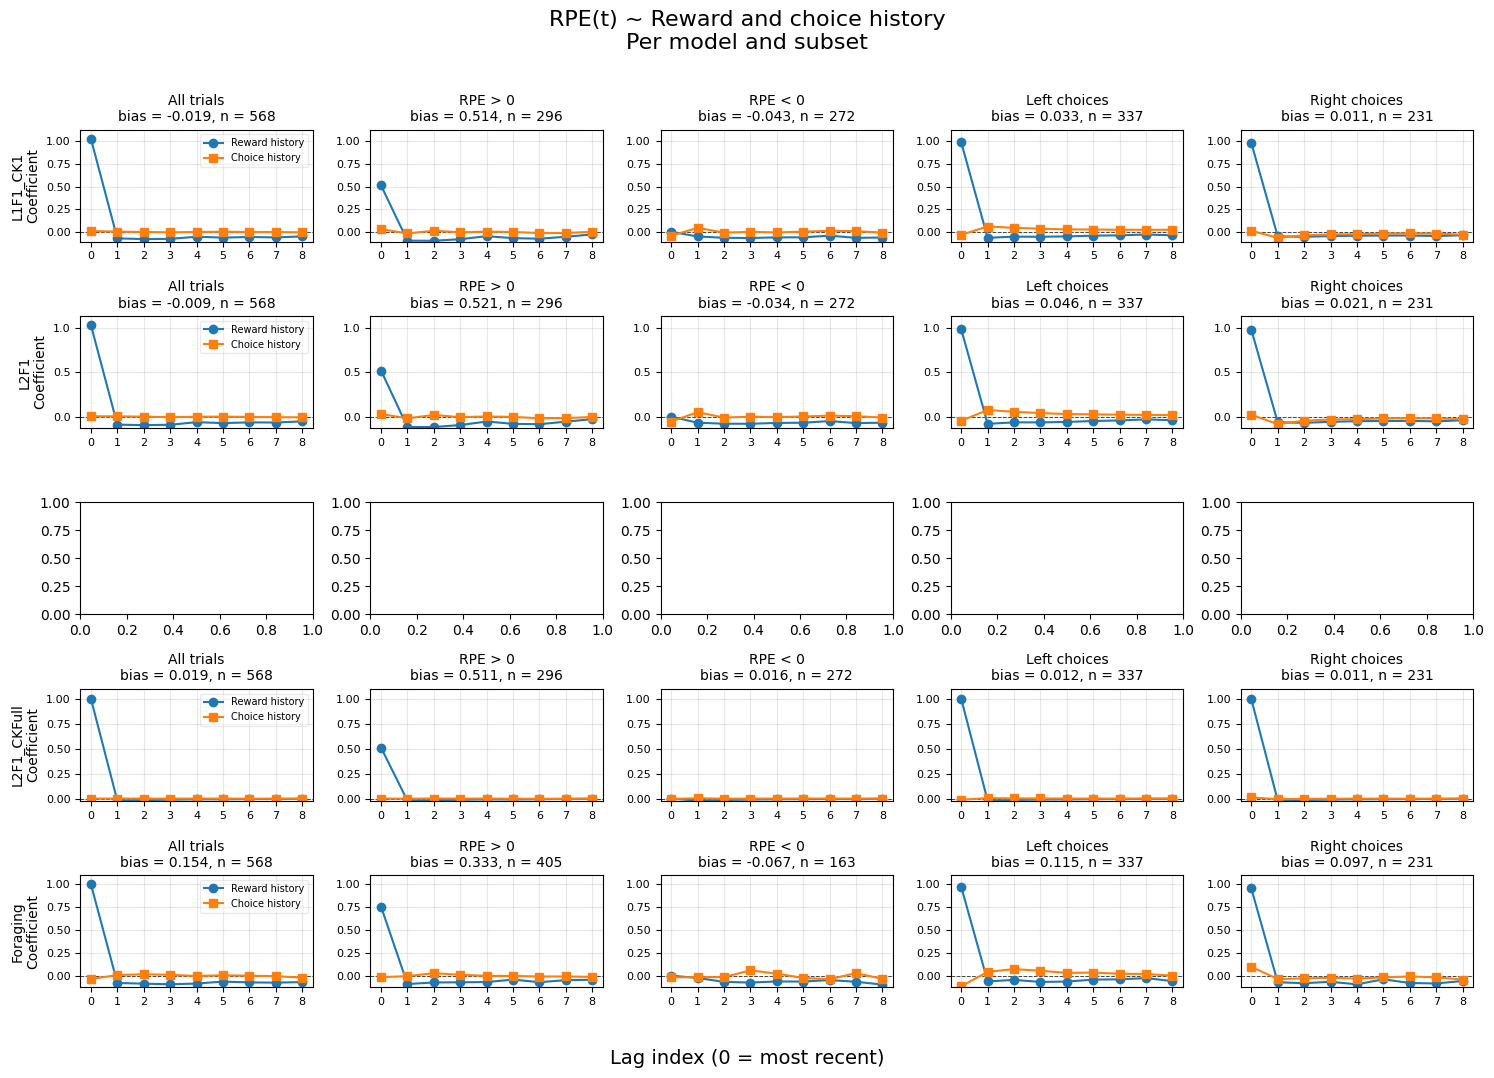

No entries for alias 'QLearning_L2F1_CK1_softmax' in fit results


In [2]:
from general_utils import find_ephys_sessions
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names, get_fitted_latent
_, _, sessions = find_ephys_sessions()
from behavior_qc_visualization import collect_behavior_model_summary
summary=collect_behavior_model_summary(sessions=['ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36'])

In [ ]:
from general_utils import find_ephys_sessions
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names, get_fitted_latent
_, _, sessions = find_ephys_sessions()
from behavior_qc_visualization import collect_behavior_model_summary
summary=collect_behavior_model_summary(sessions=sessions)

Found behavior NWB: /root/capsule/data/behavior_nwb/753124_2024-12-10_17-24-56.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753125_2024-10-10_14-41-23.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753125_2024-10-14_15-37-15.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753125_2024-10-09_10-50-19.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753125_2024-10-15_16-16-22.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753126_2024-10-10_17-51-24.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753126_2024-10-15_12-20-35.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753126_2024-10-11_13-14-24.nwb


/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/753126_2024-10-10_17-51-24.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/753125_2024-10-10_14-41-23.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/753125_2024-10-14_15-37-15.nwb
Found 9 MLE fitting records!
Found 9 successful MLE fitting!












Get latent variables from s3: 100%|██████████| 9/9 [00:01<00:00,  6.36it/s]


Found 9 successful MLE fitting!


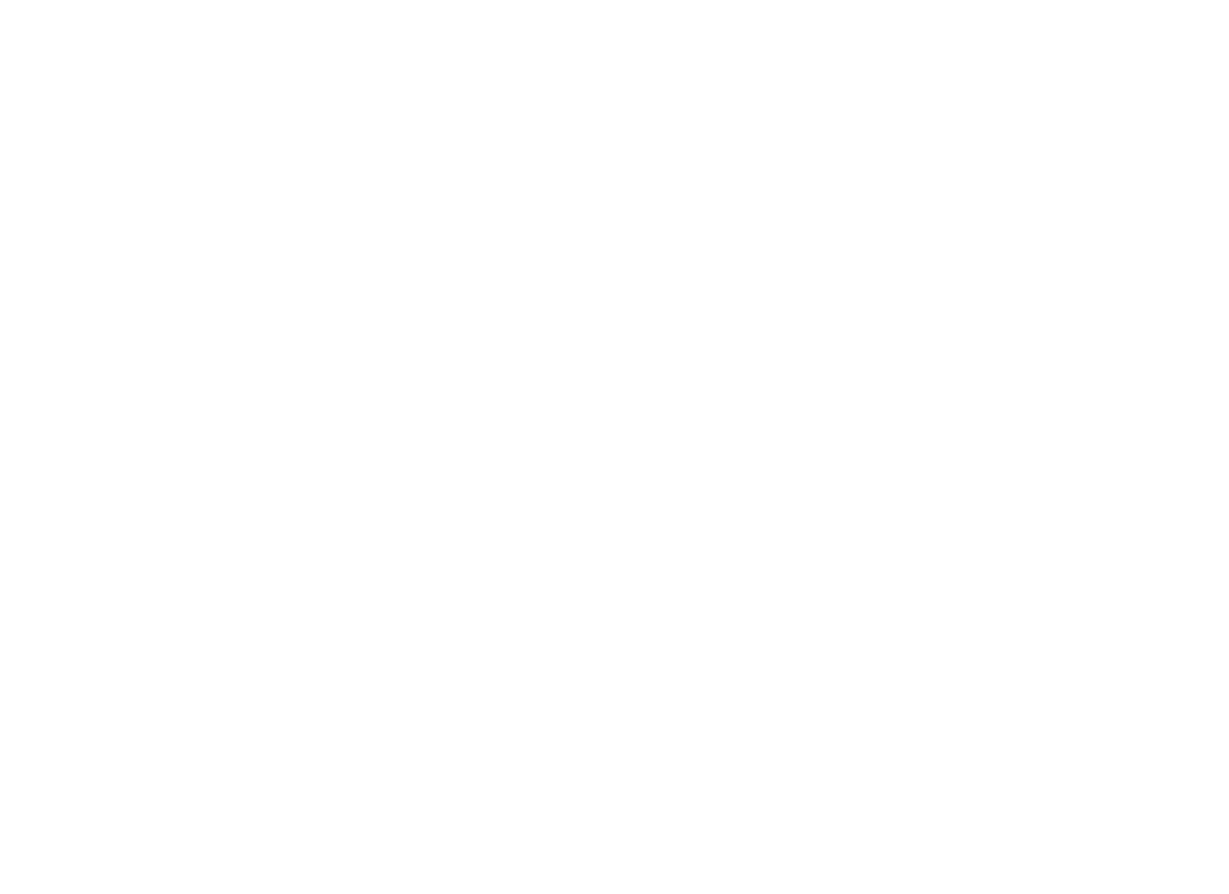

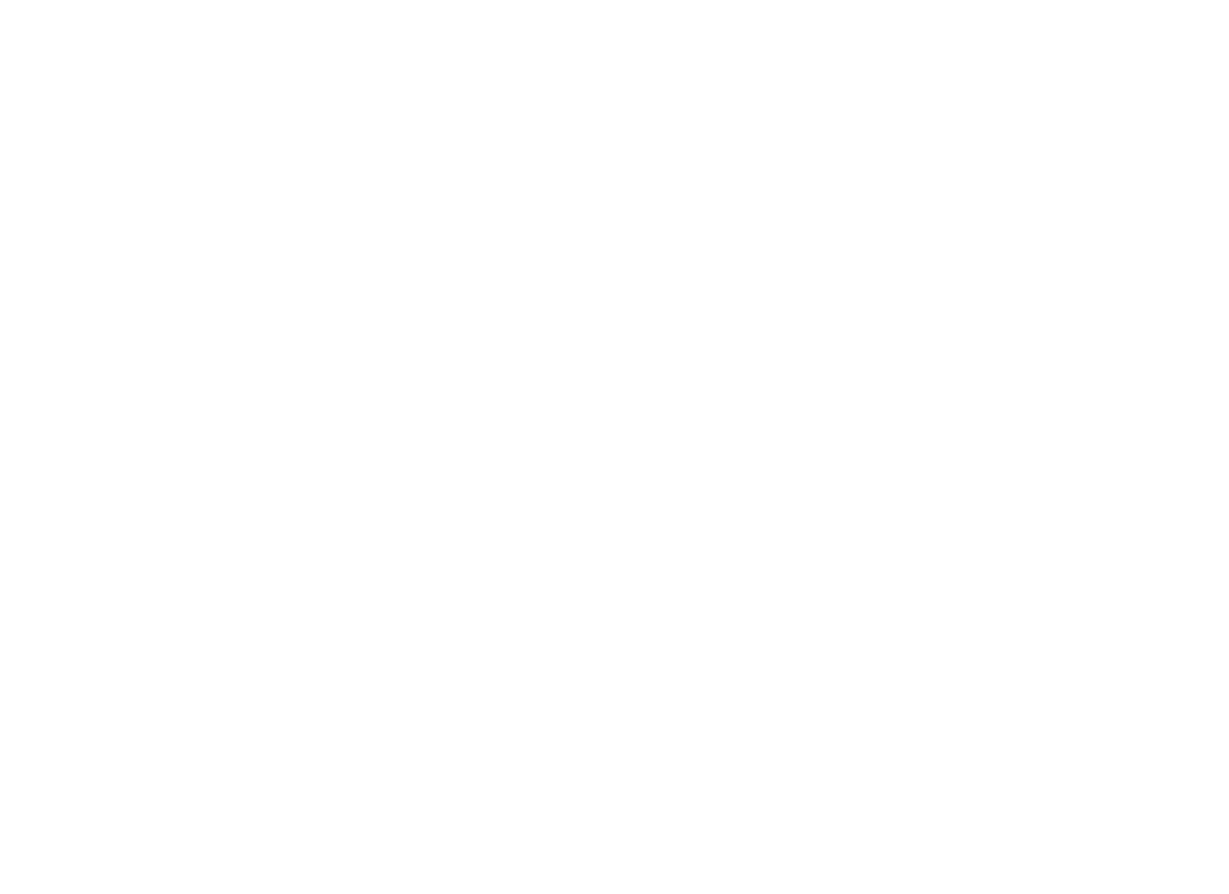

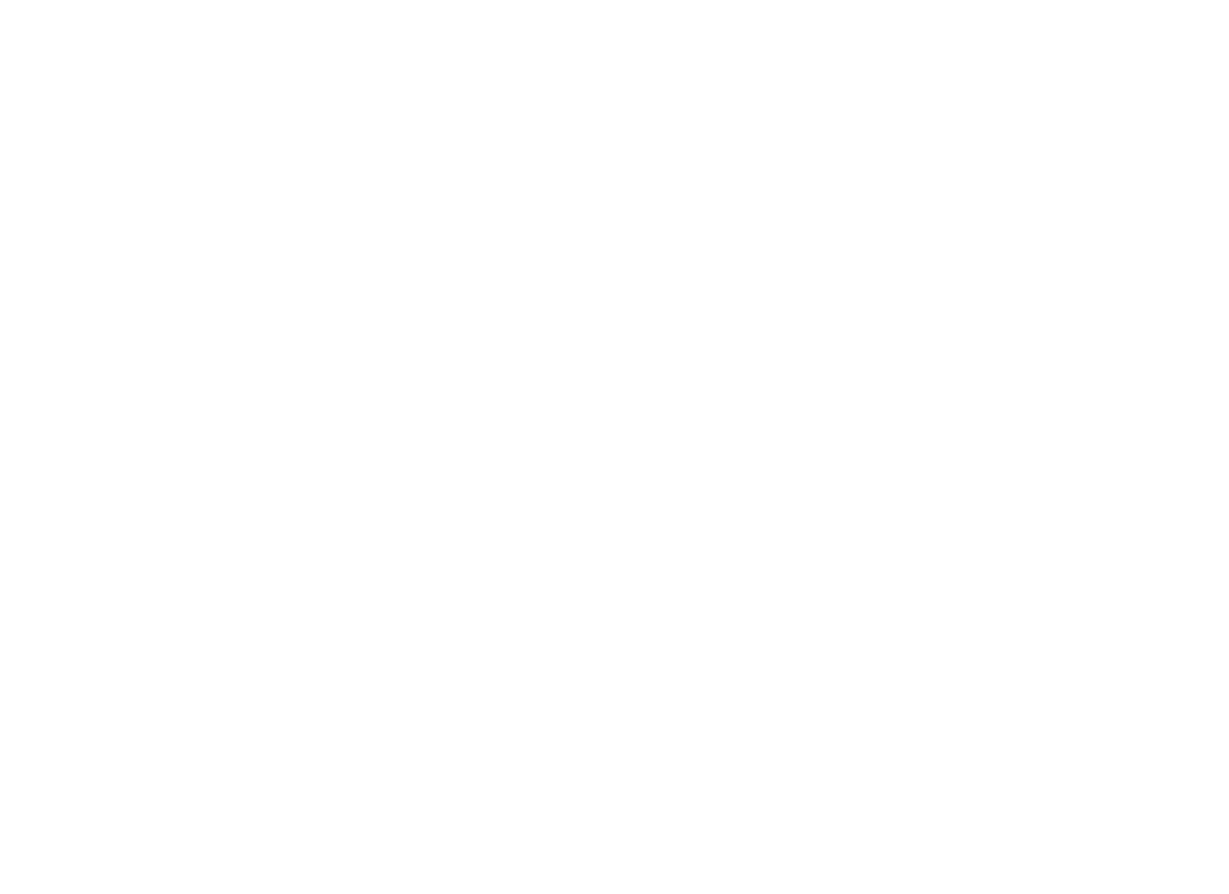

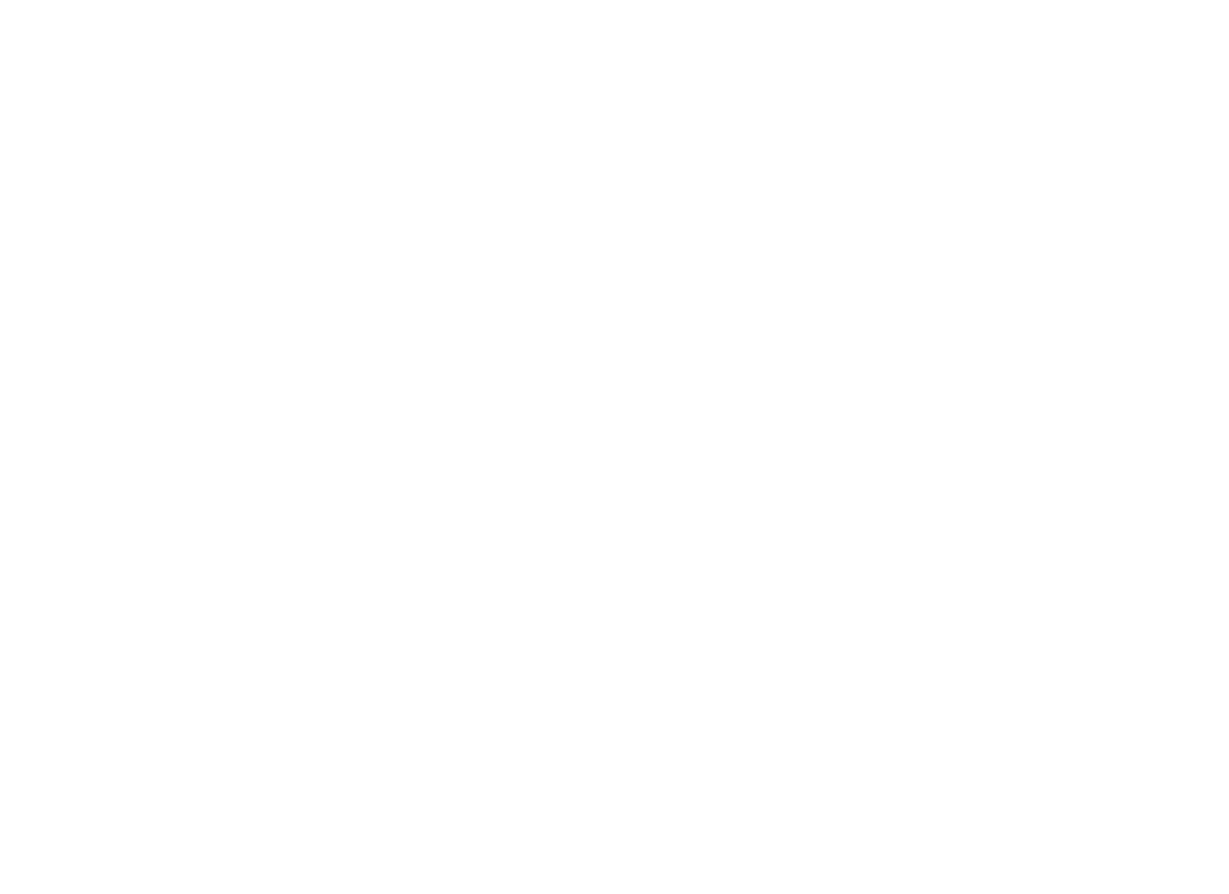

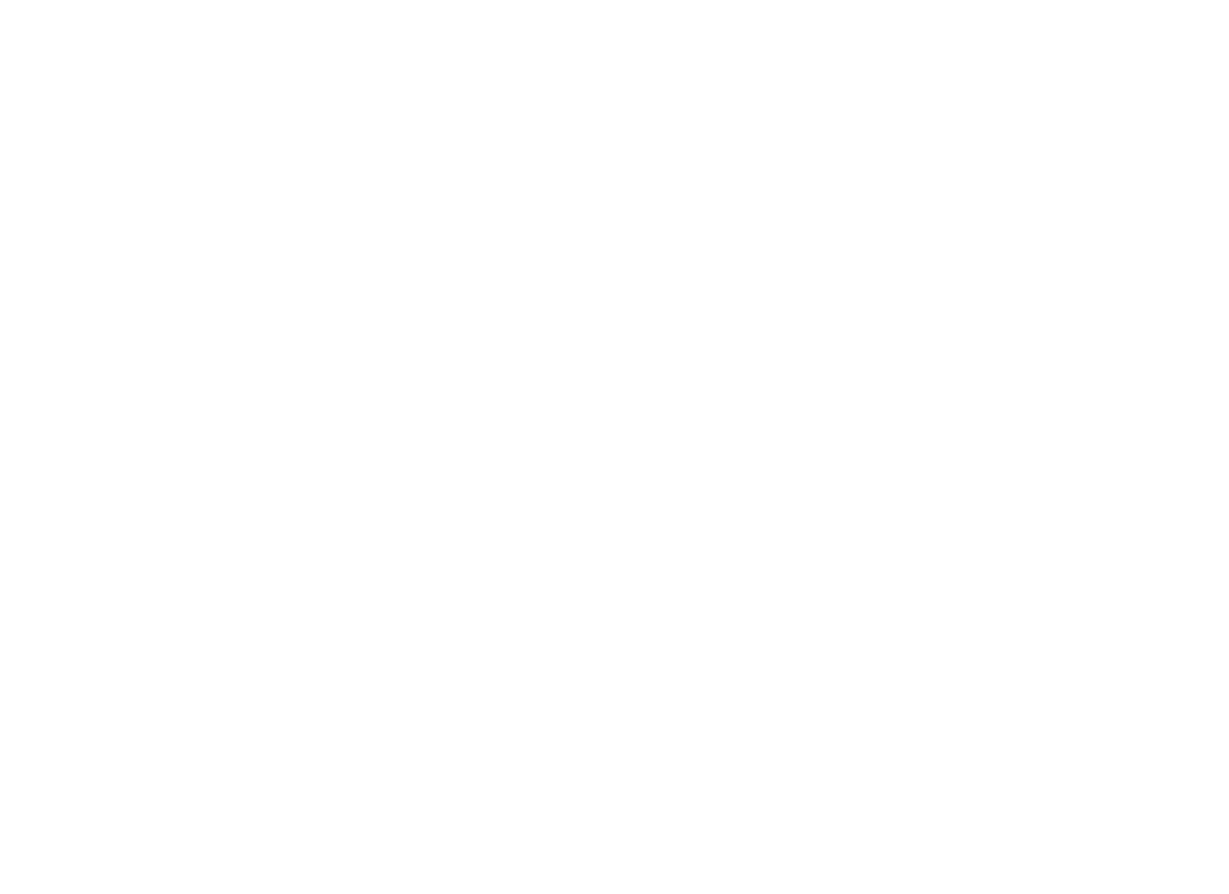

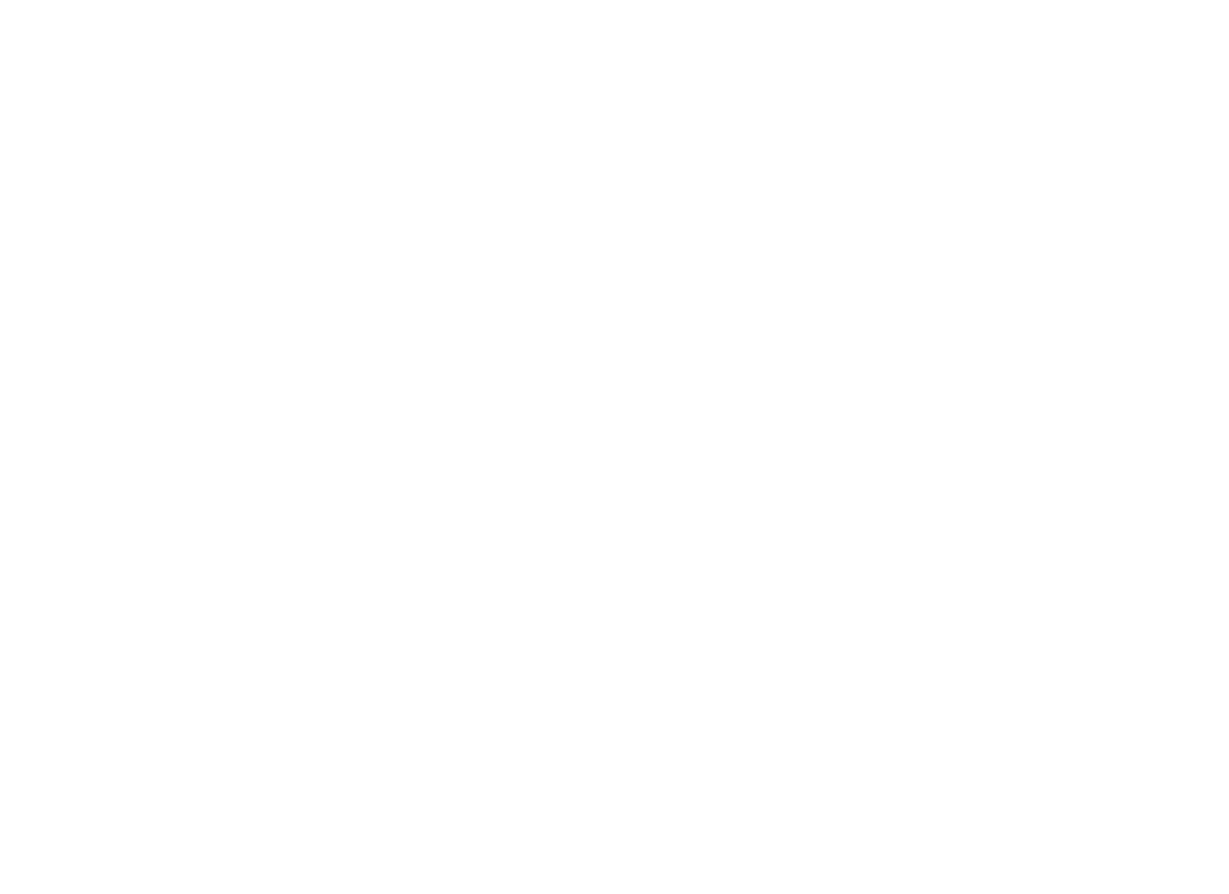

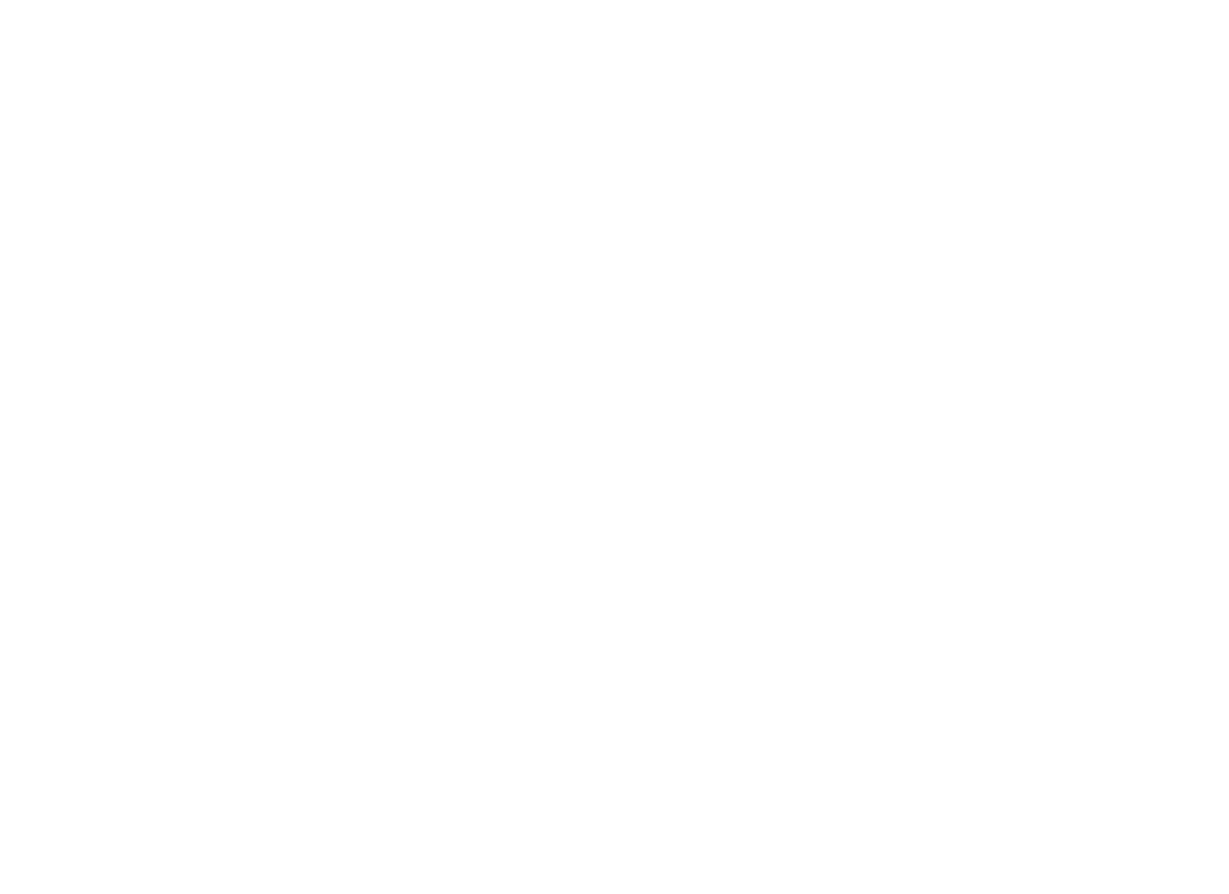

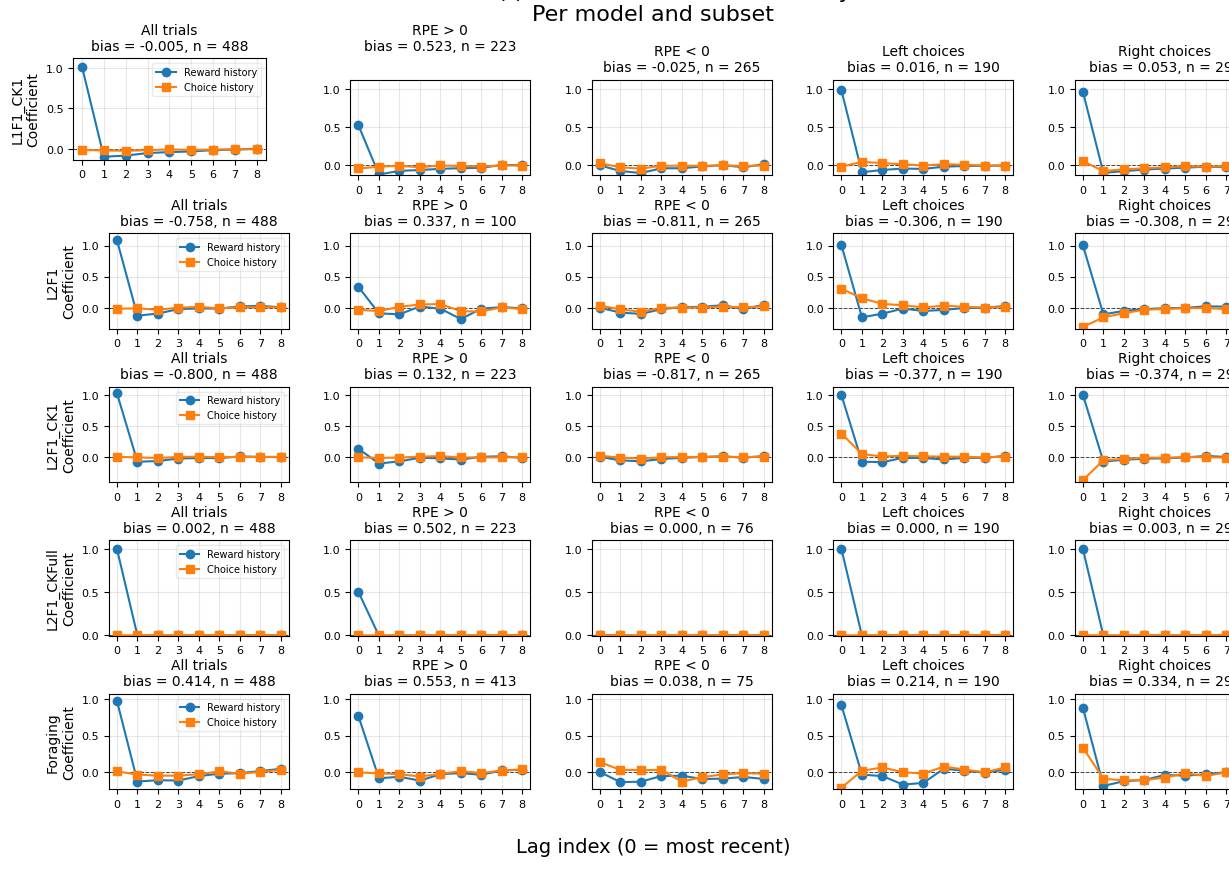

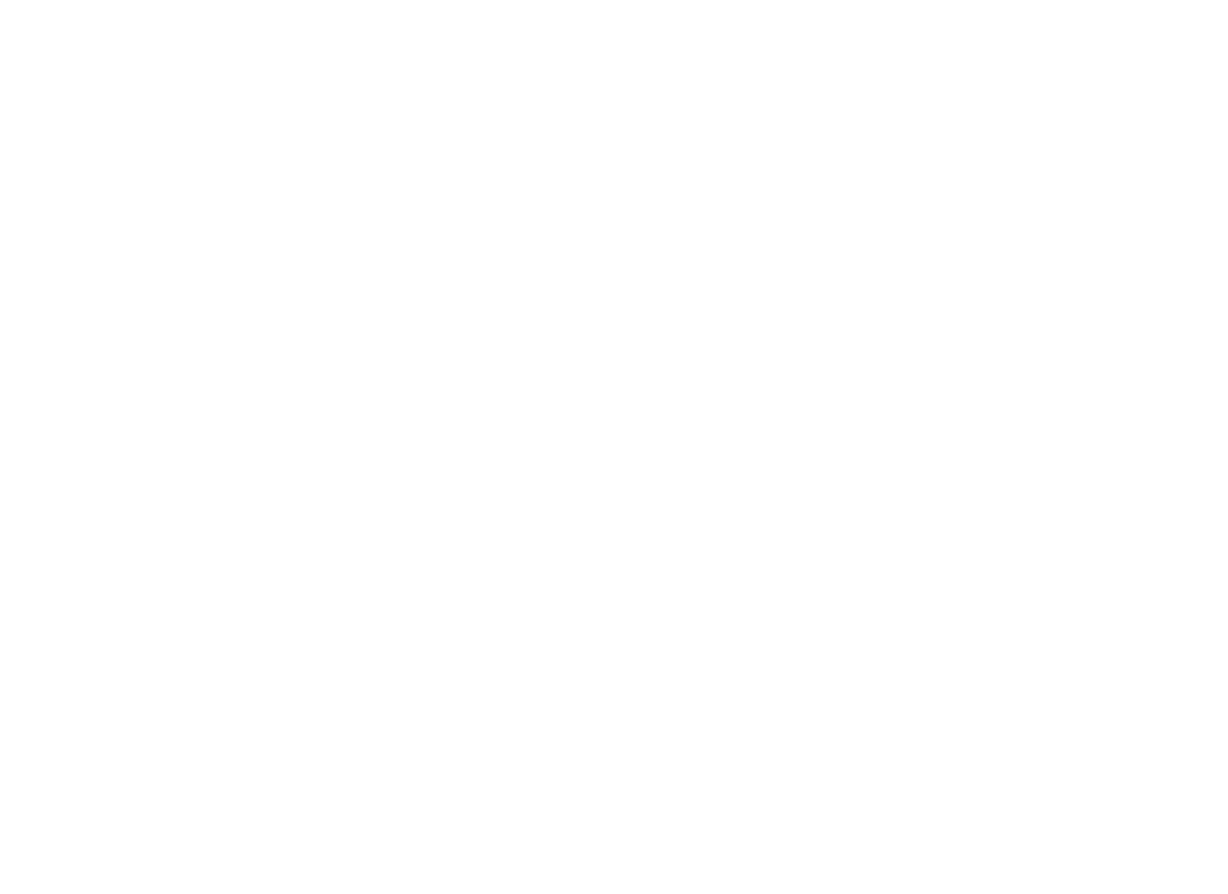

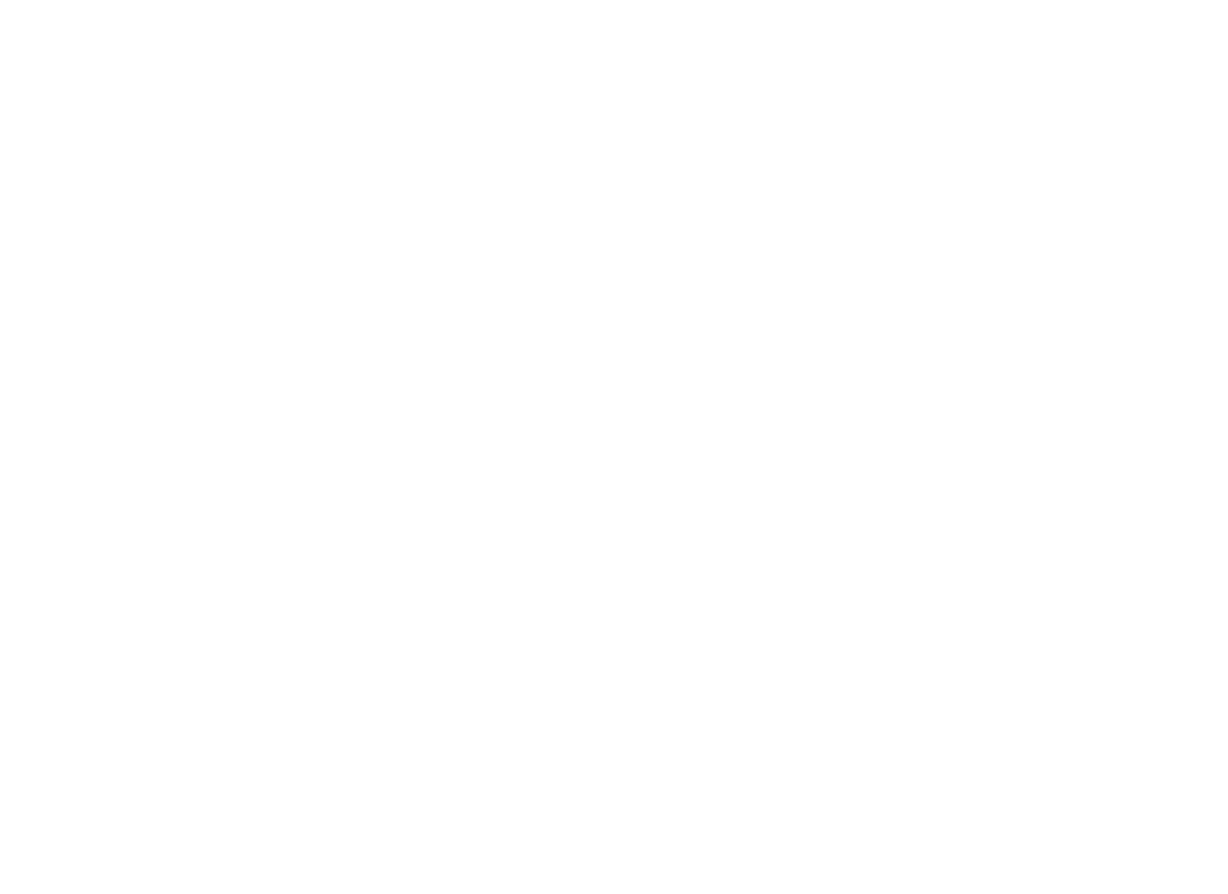

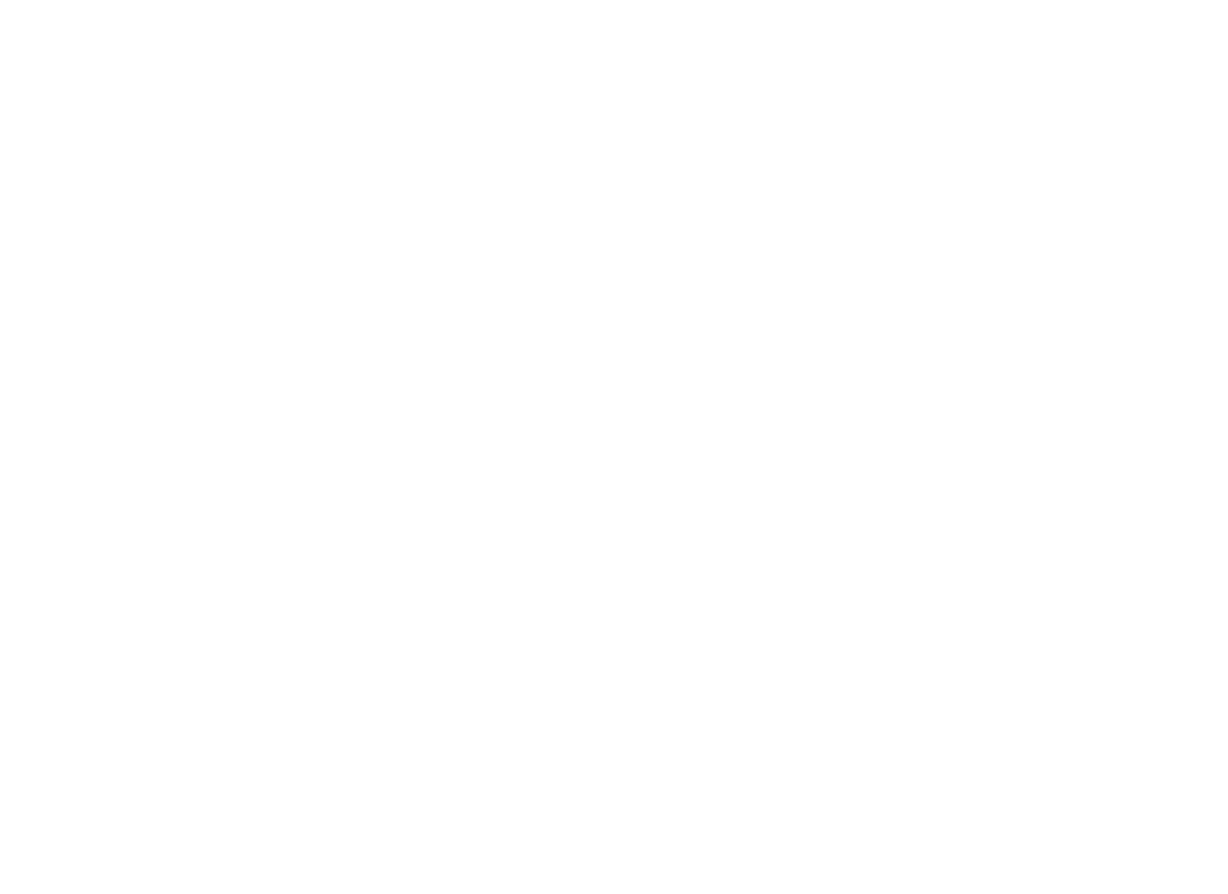

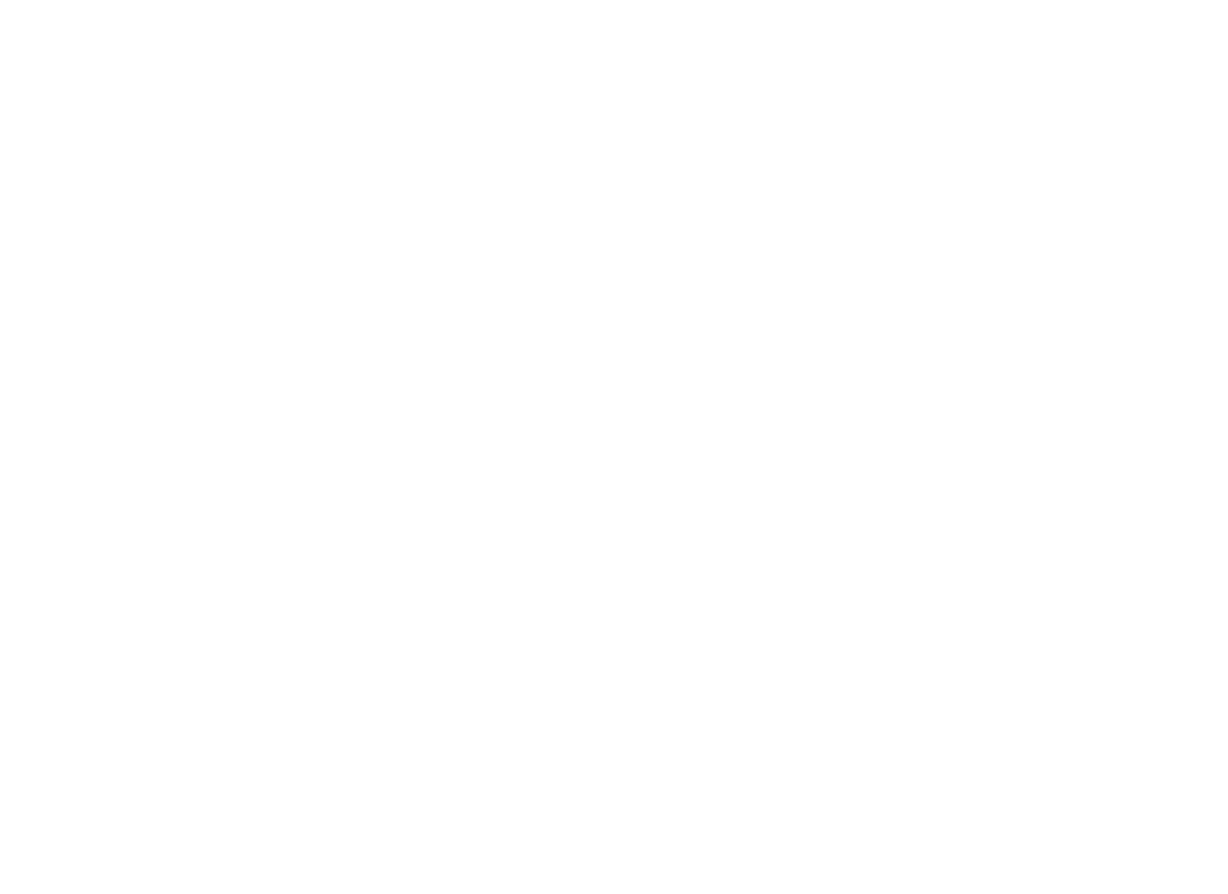

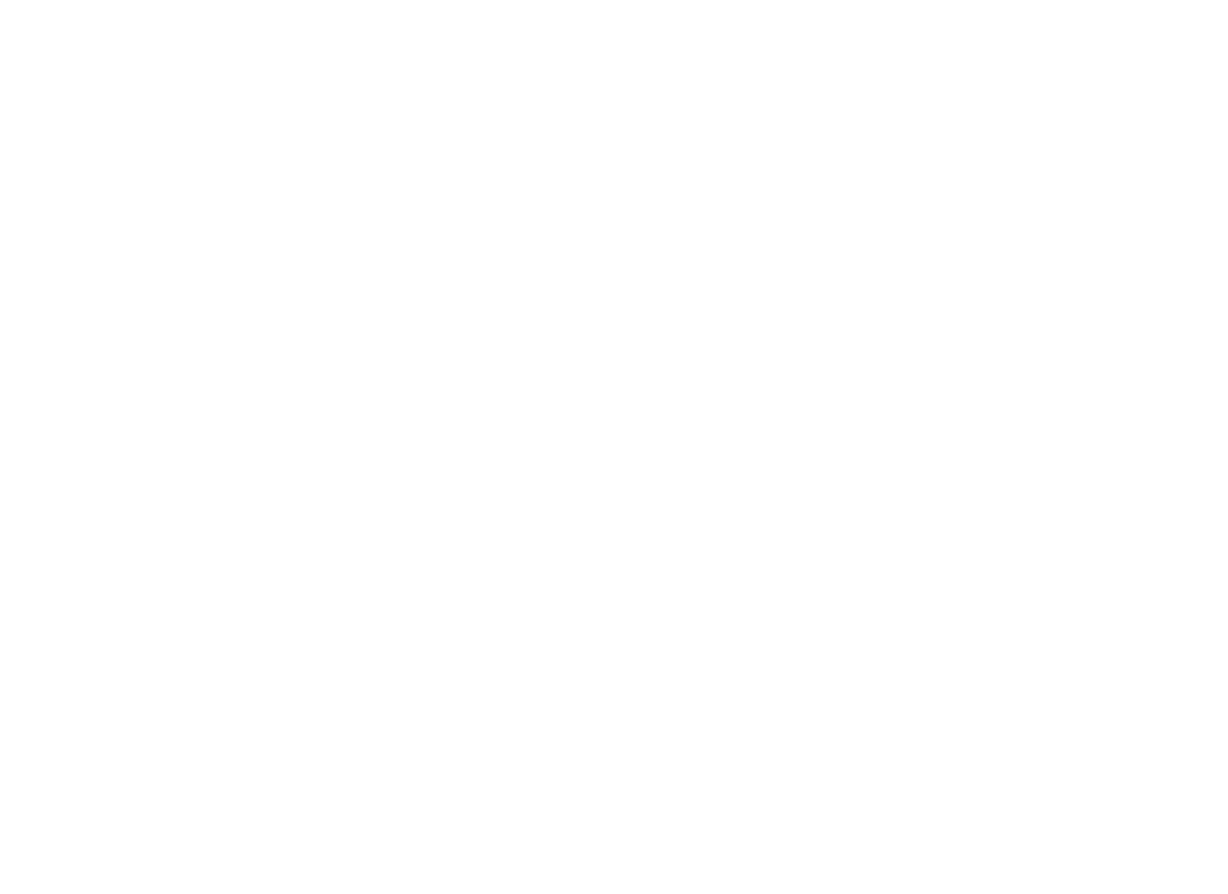

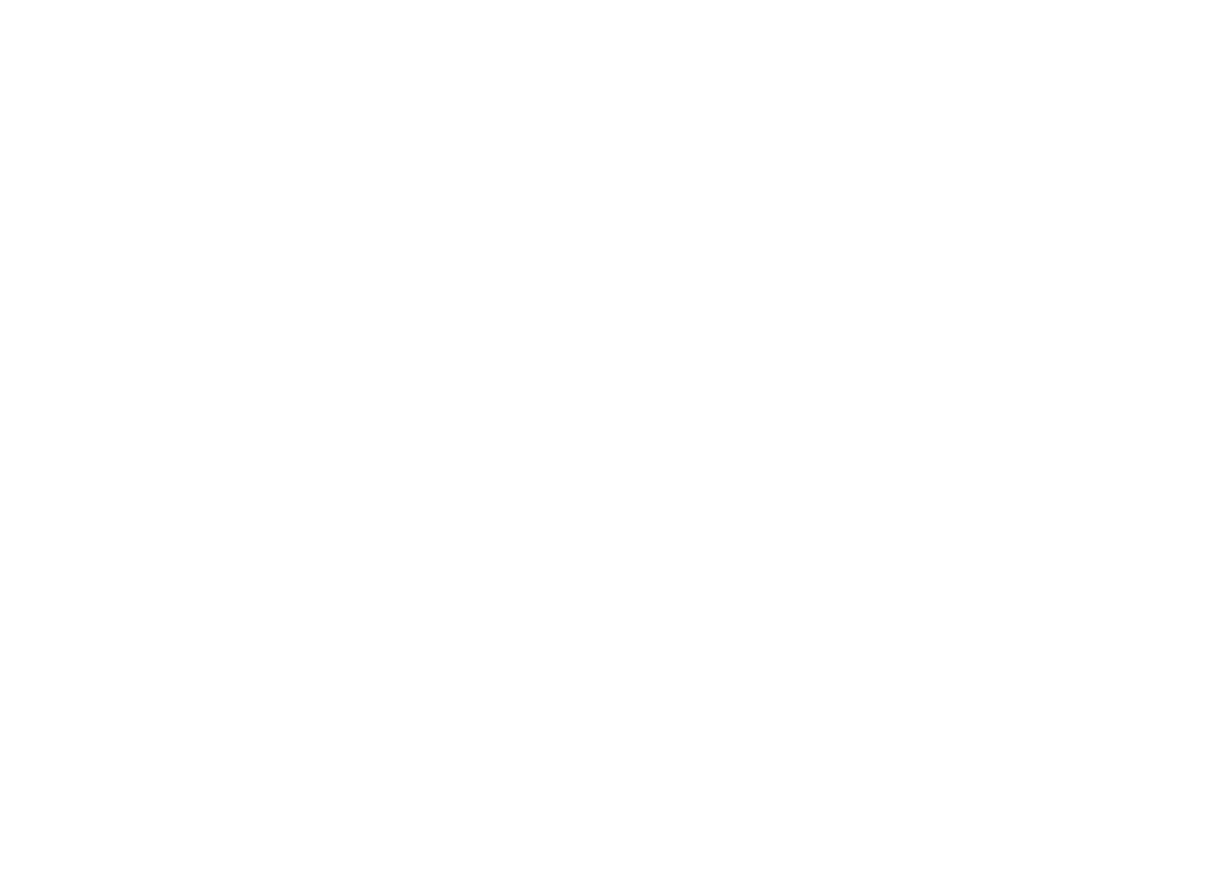

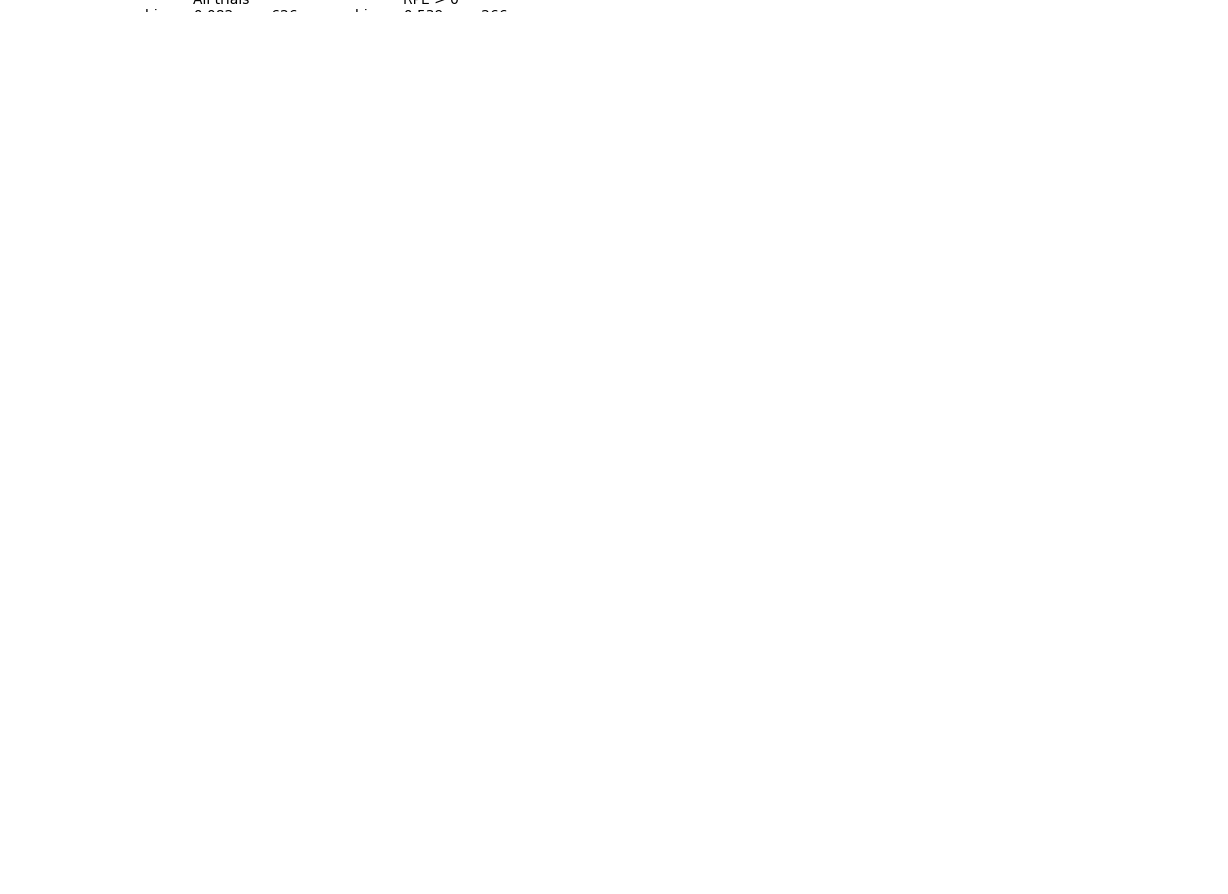

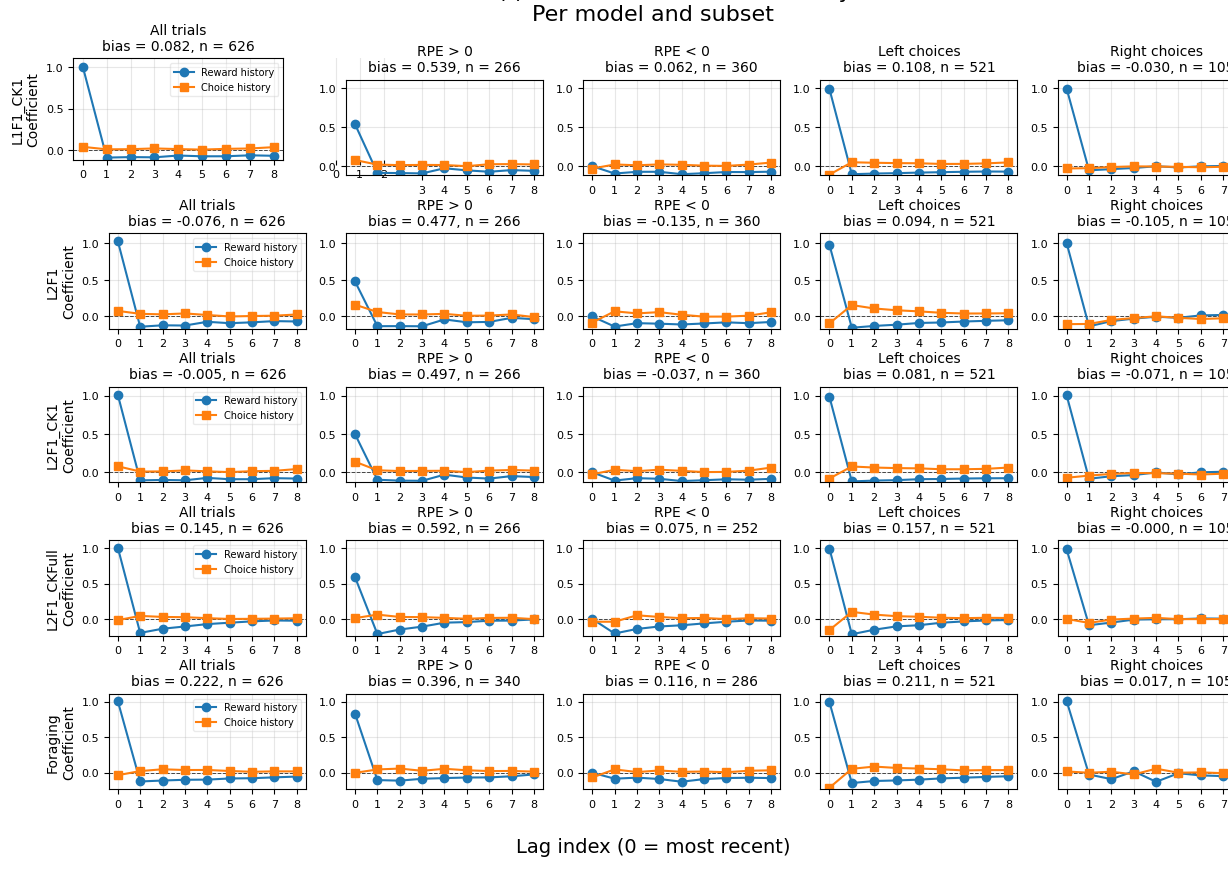

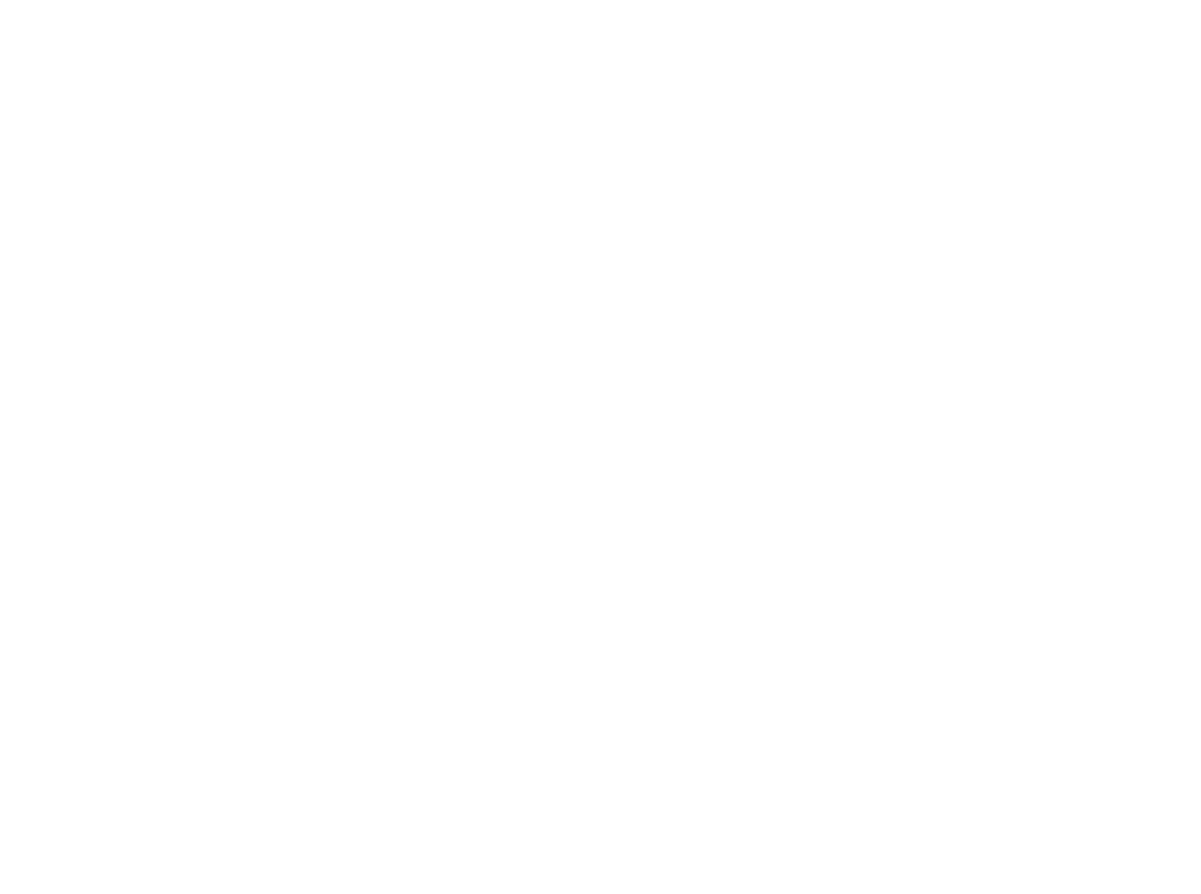

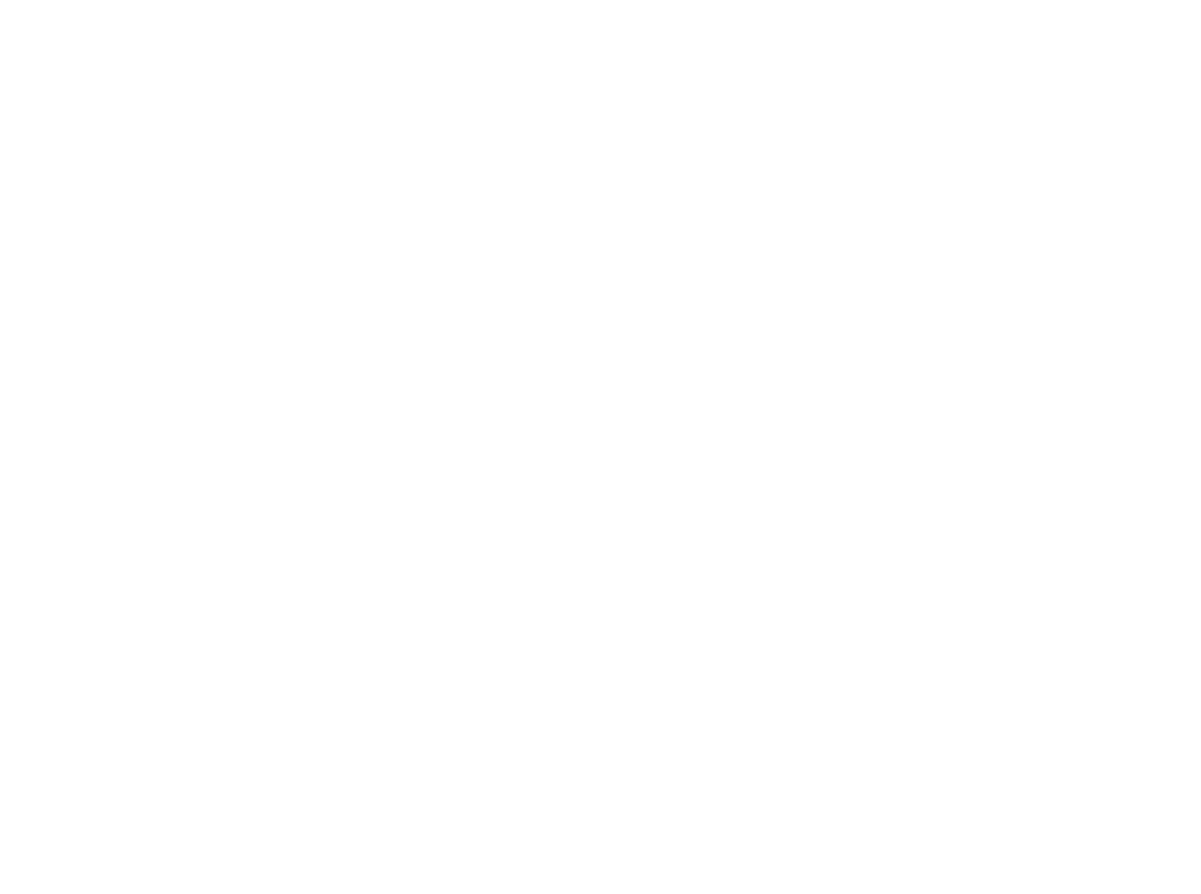

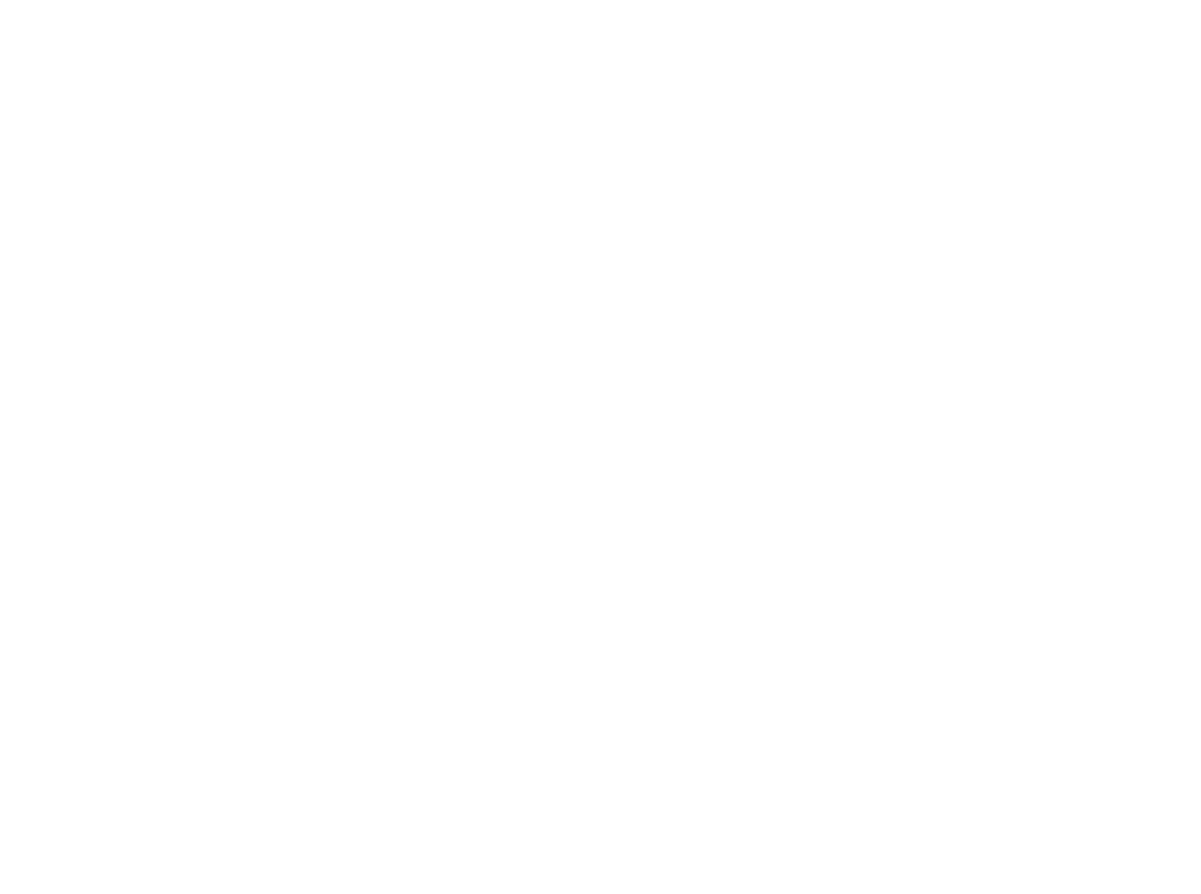

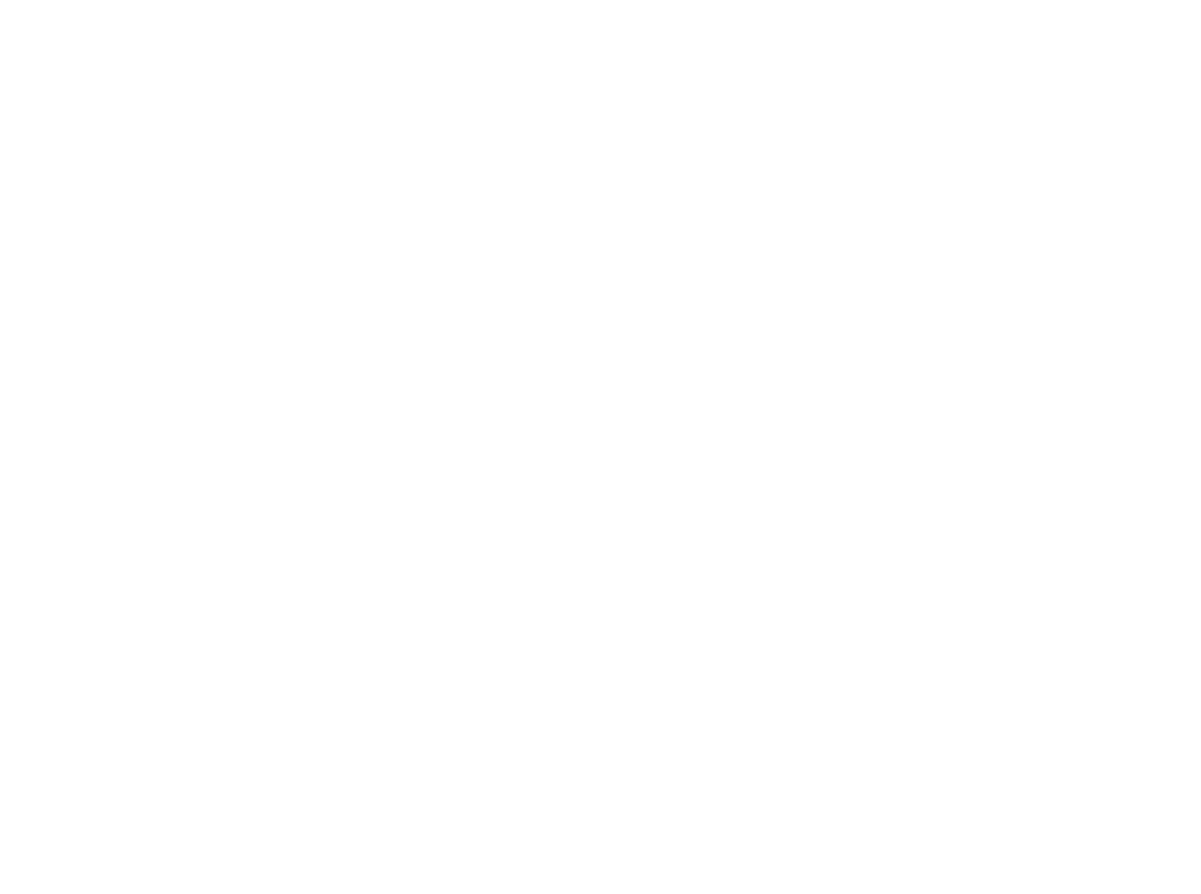

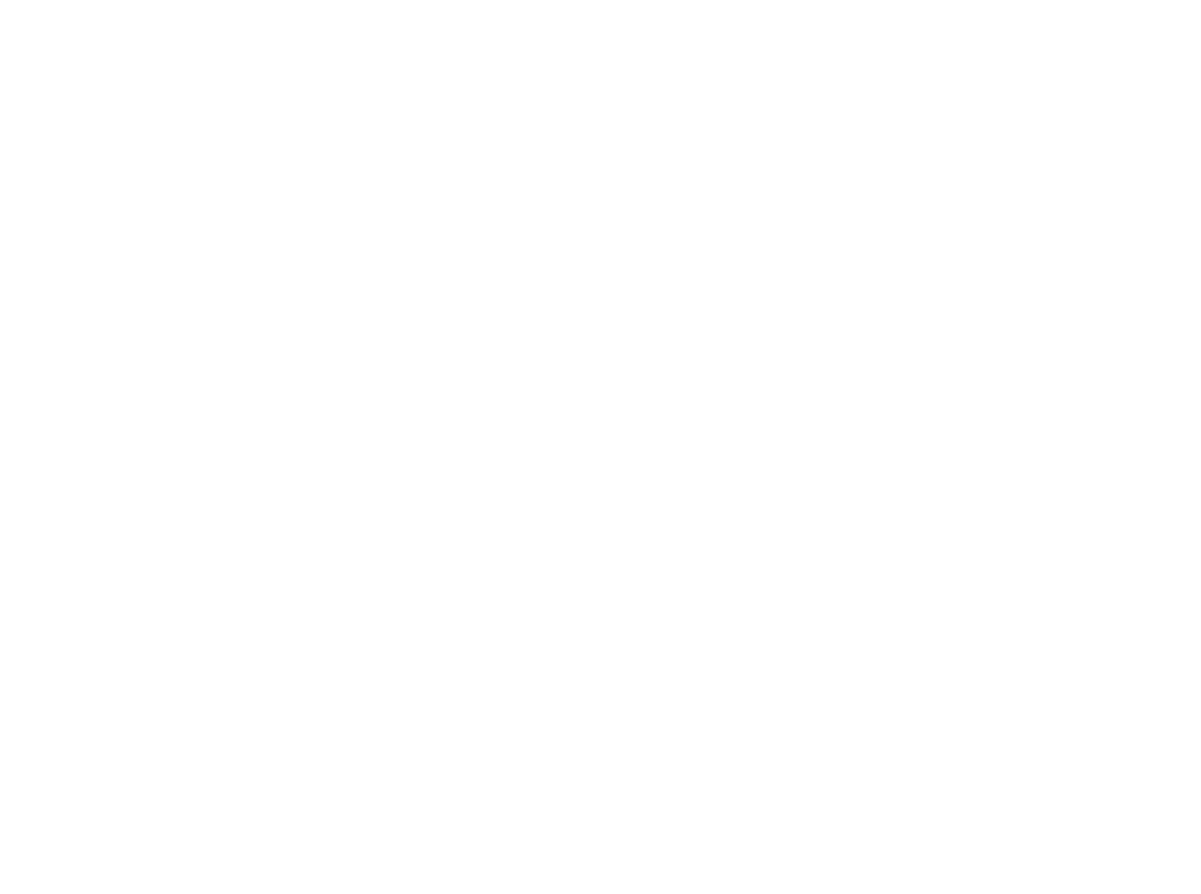

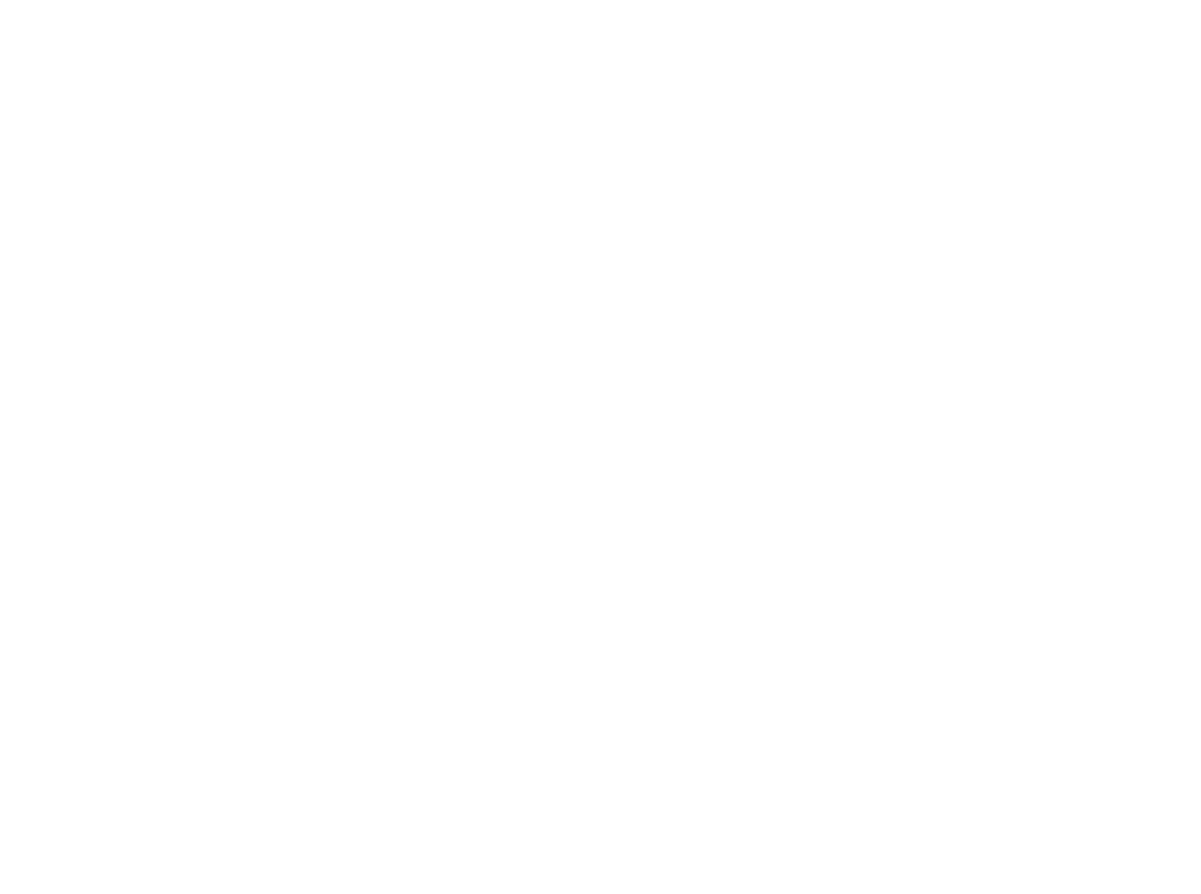

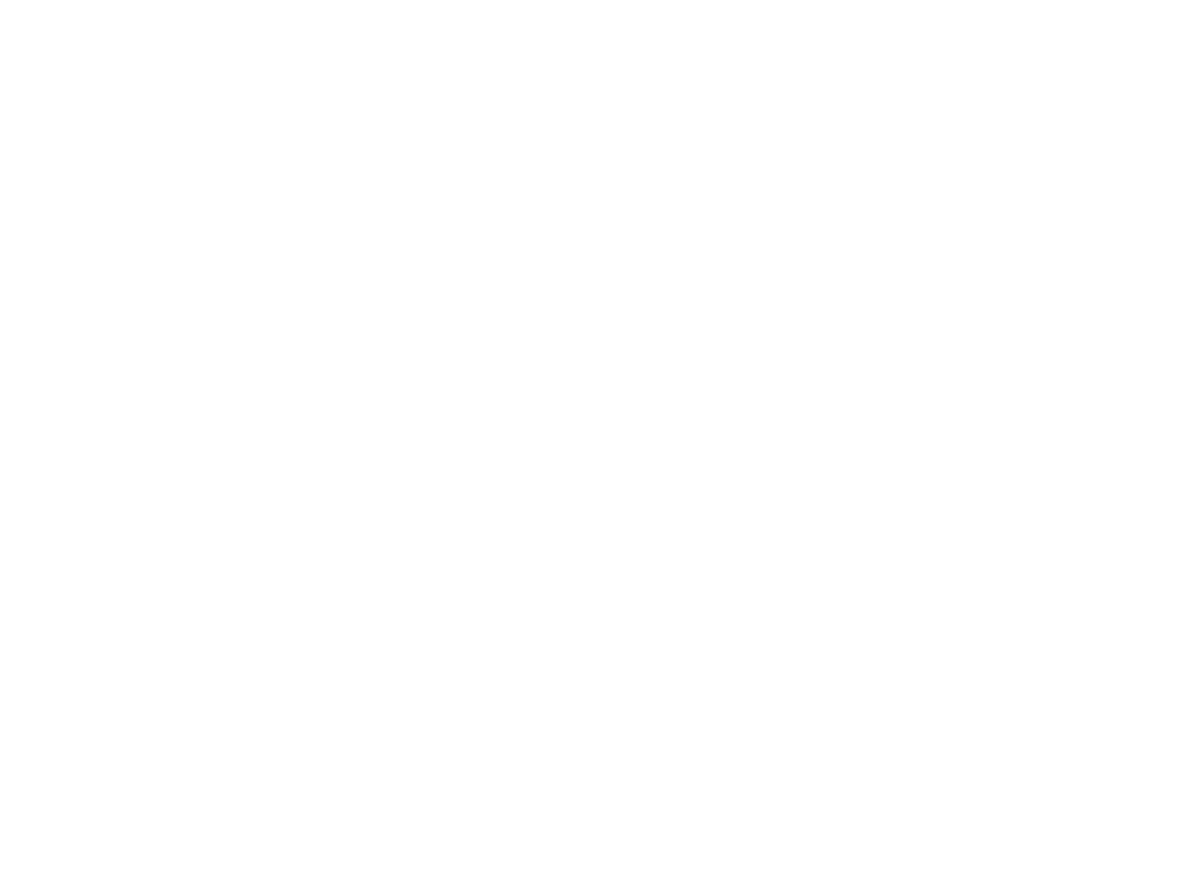

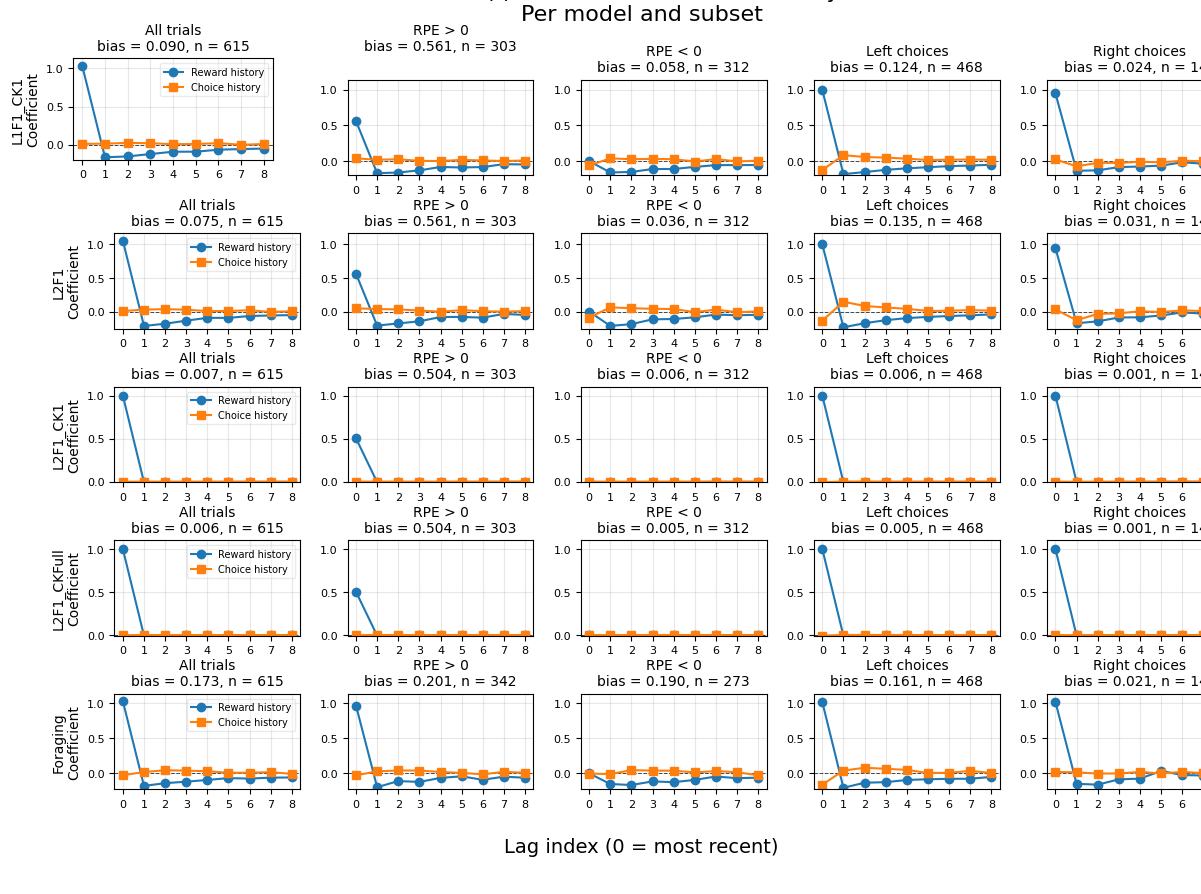

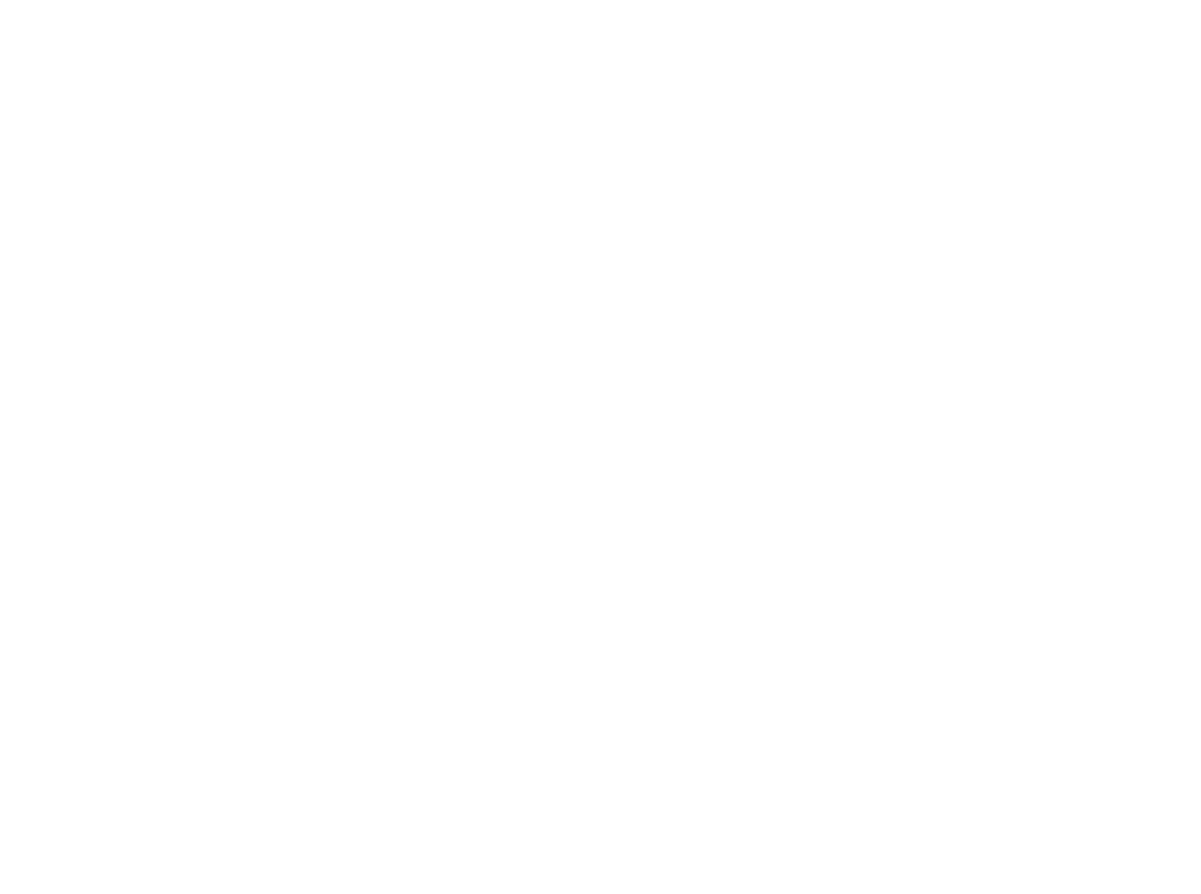

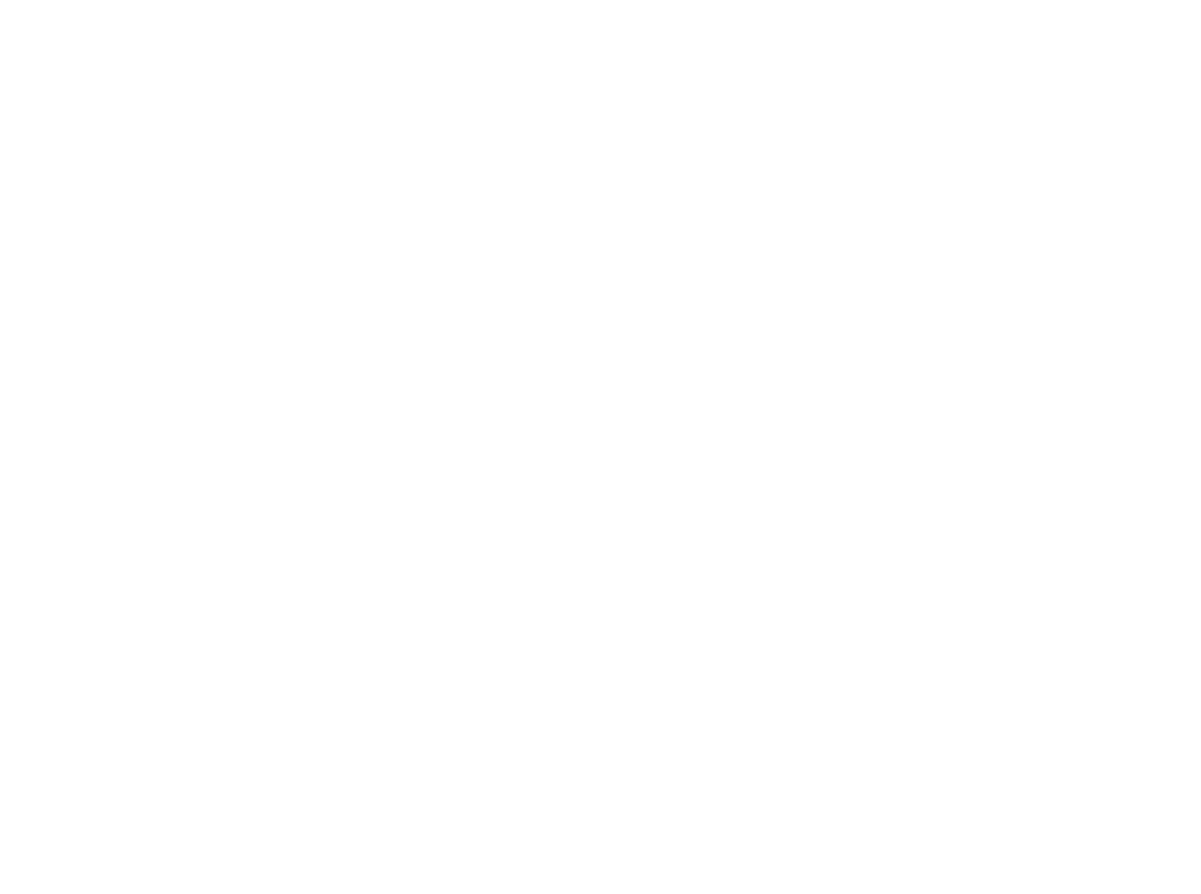

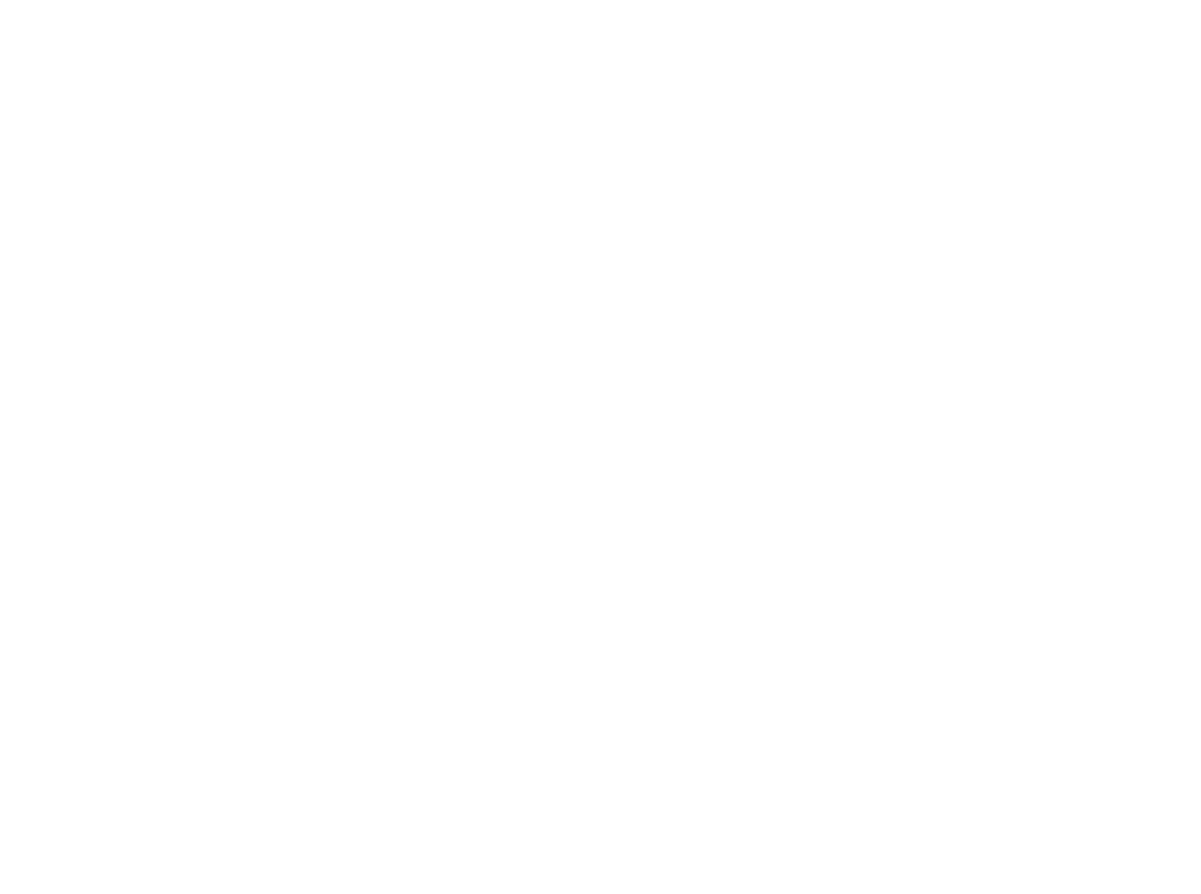

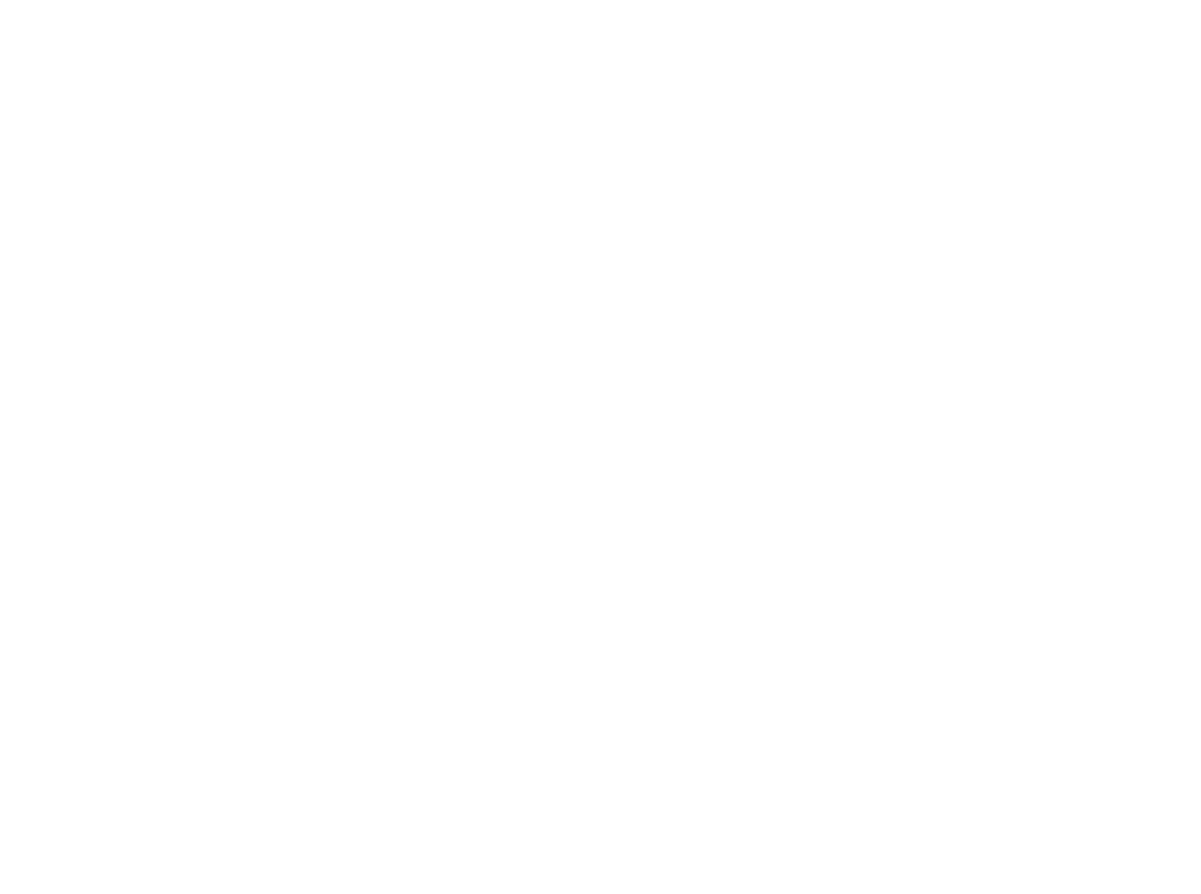

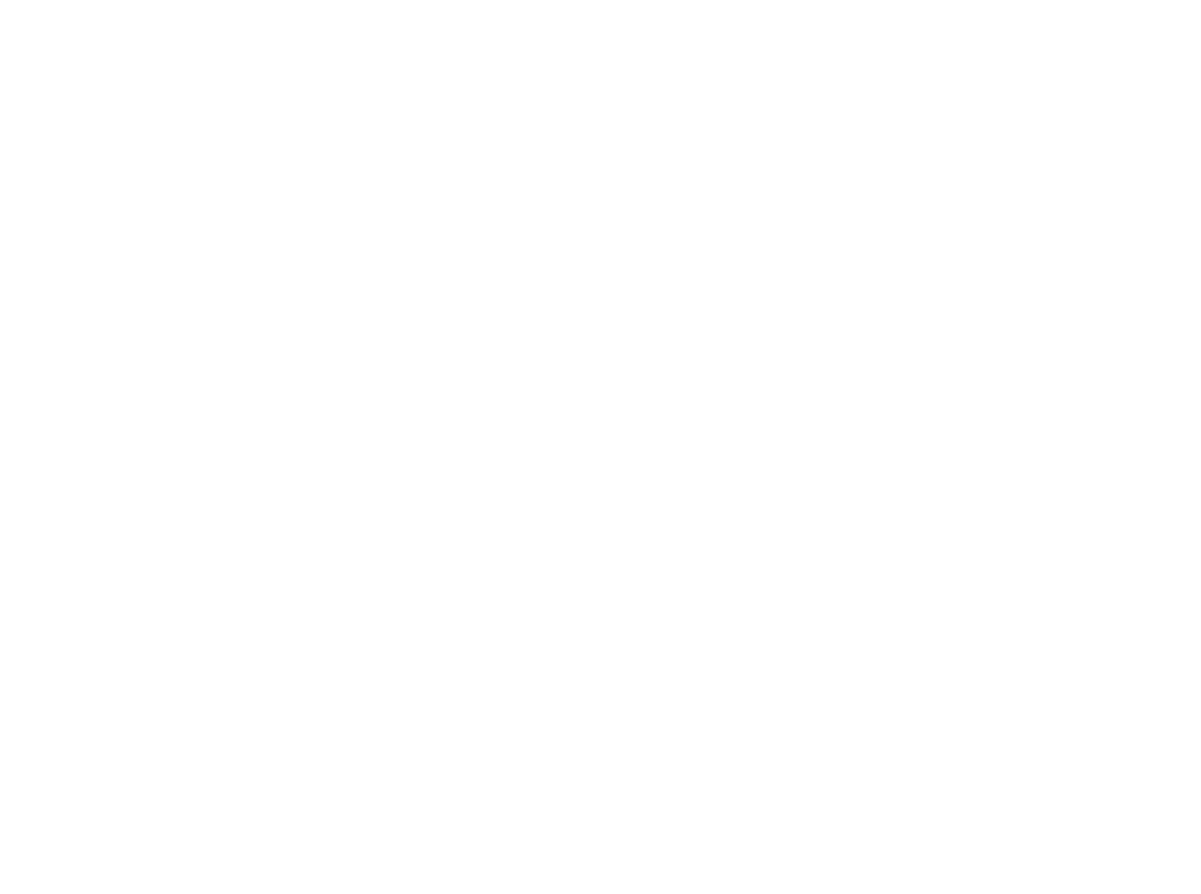

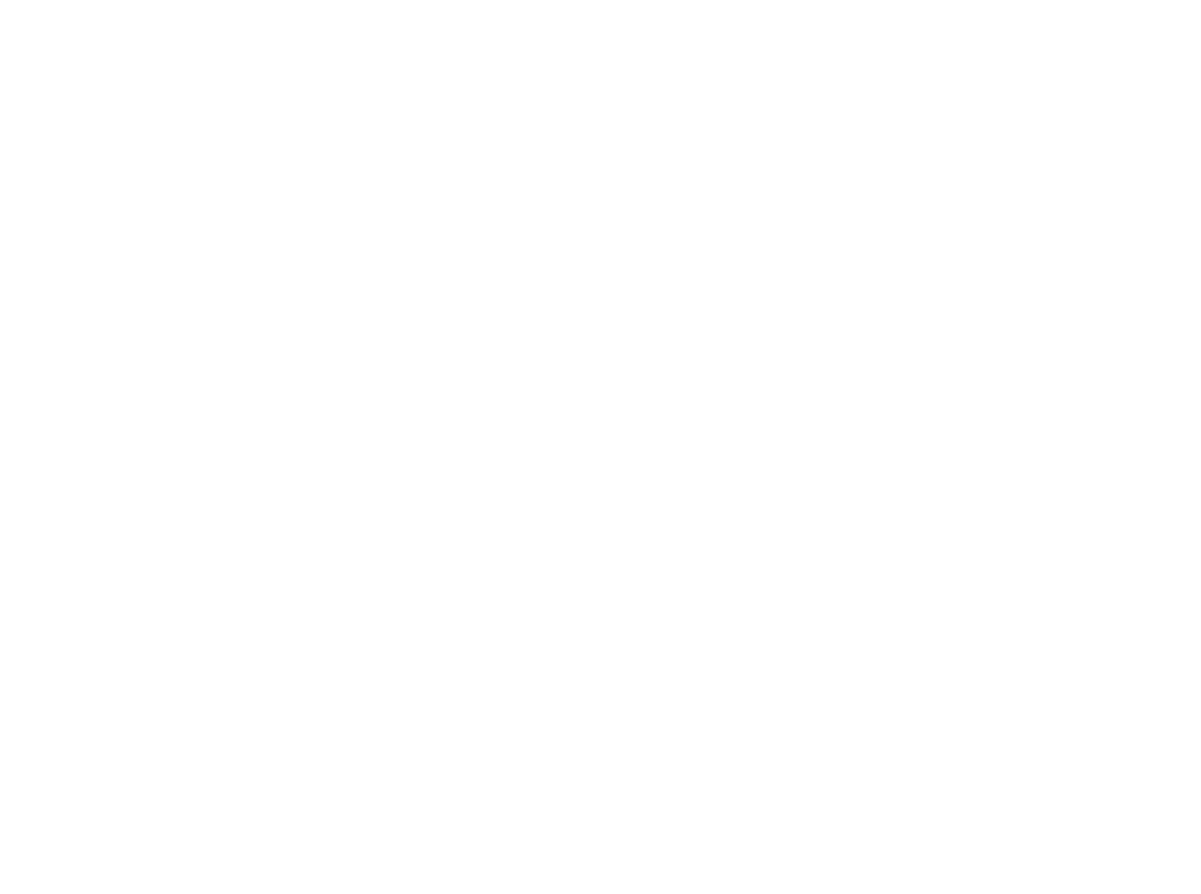

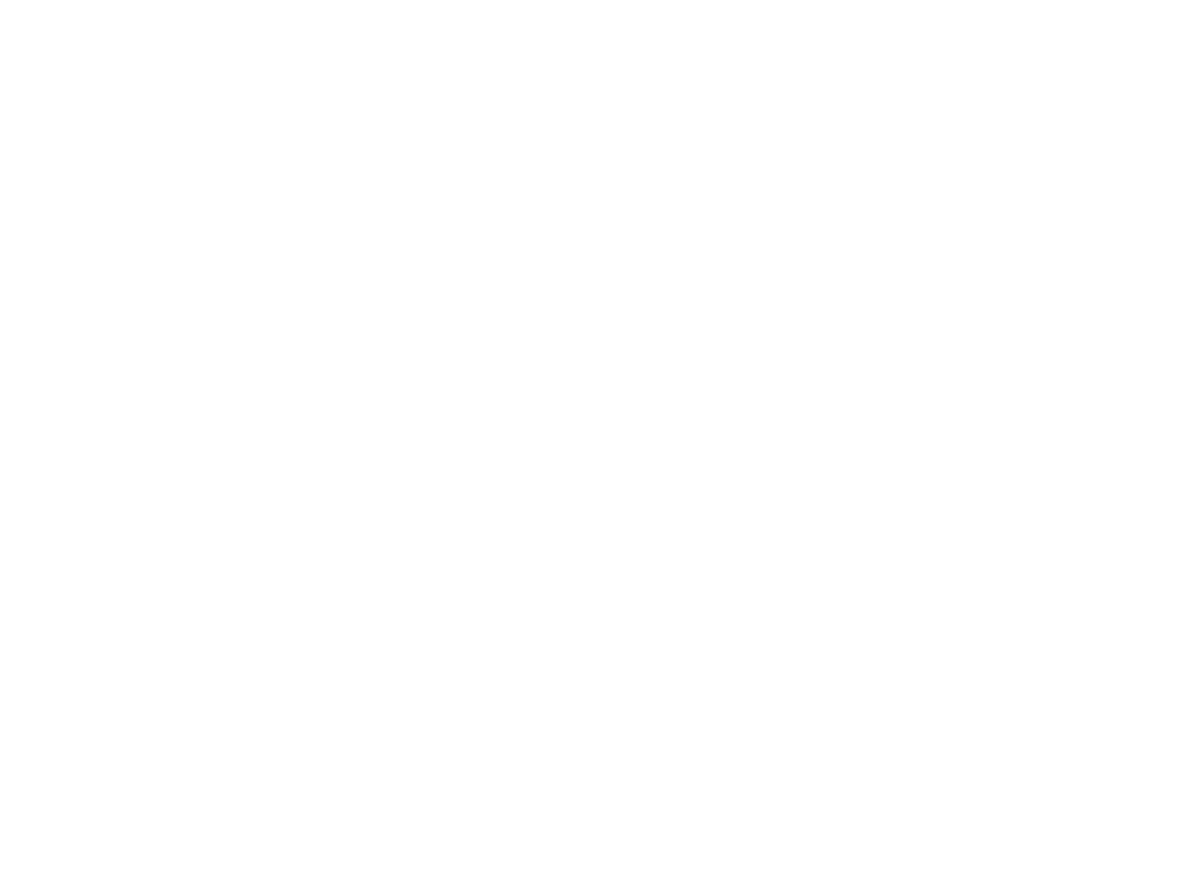

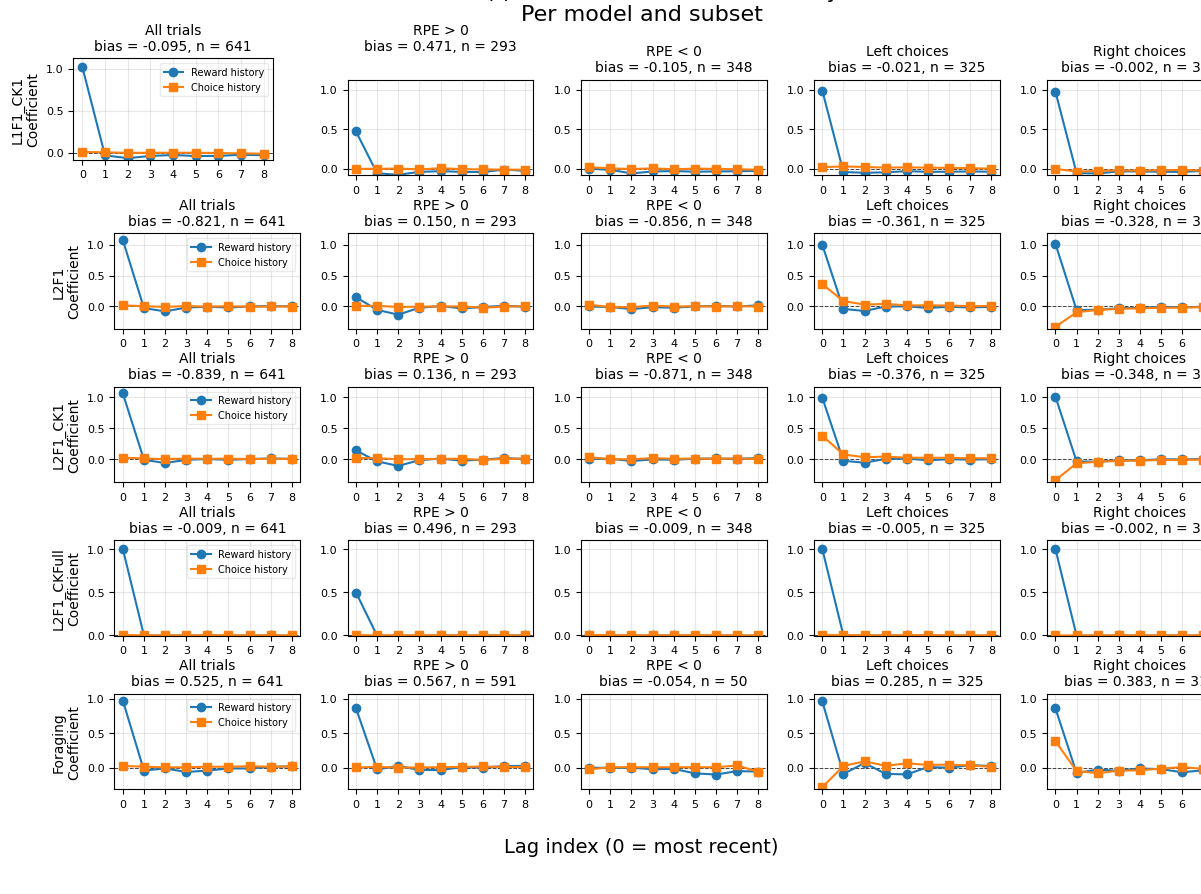

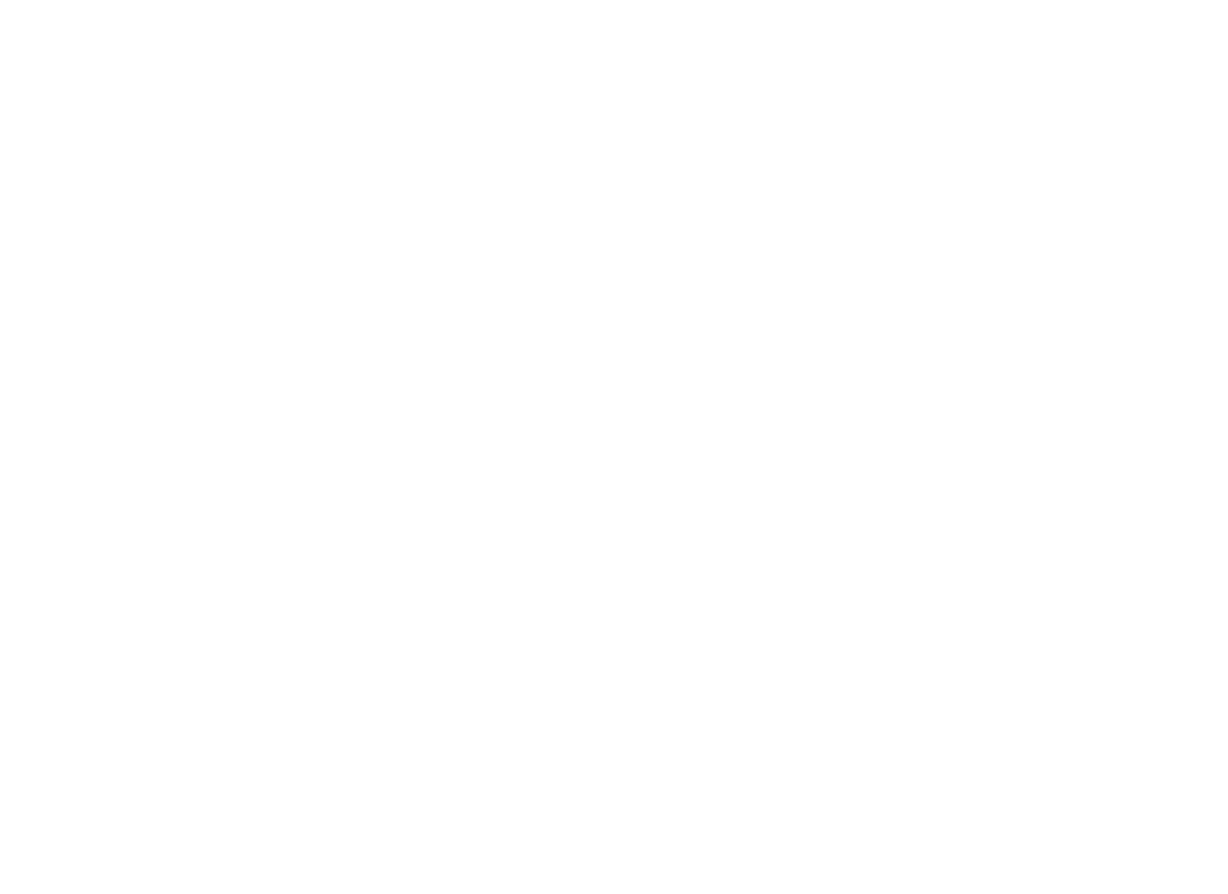

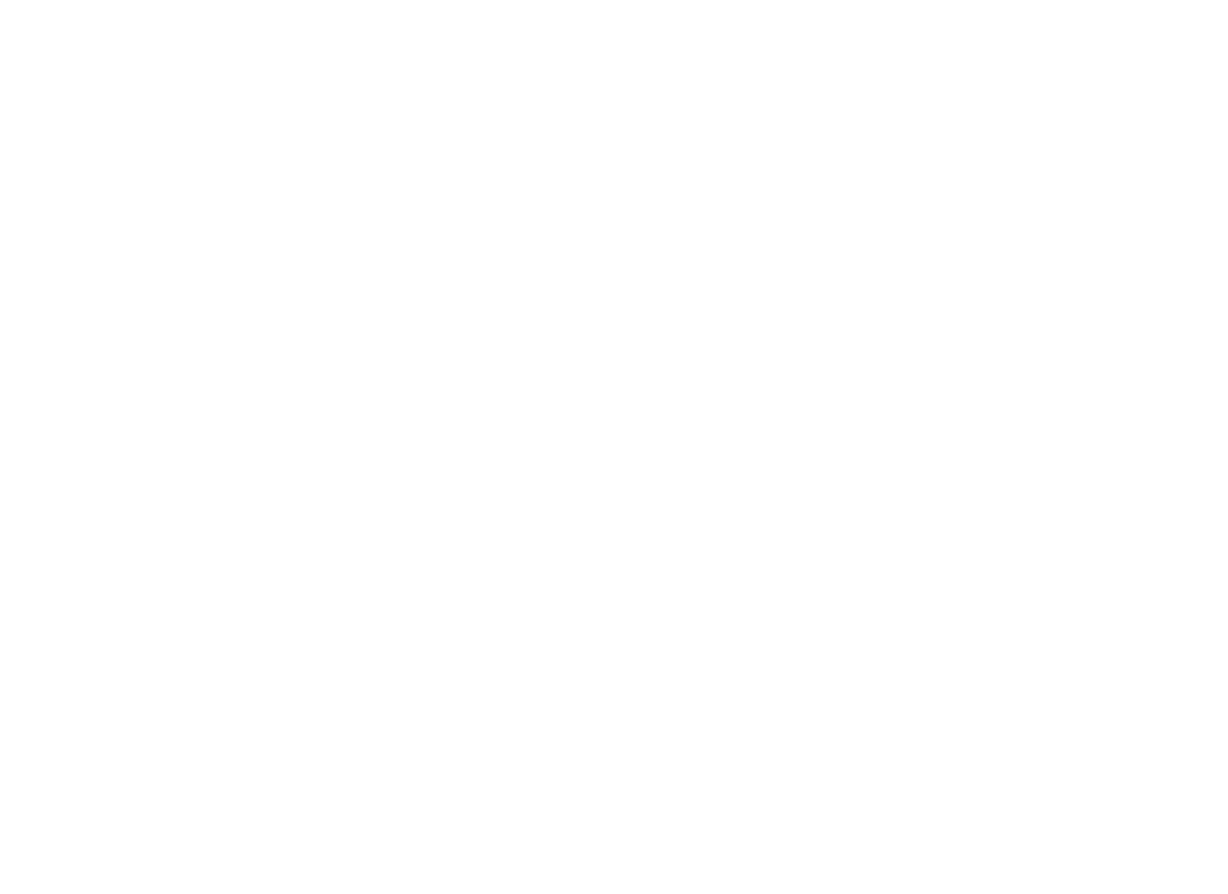

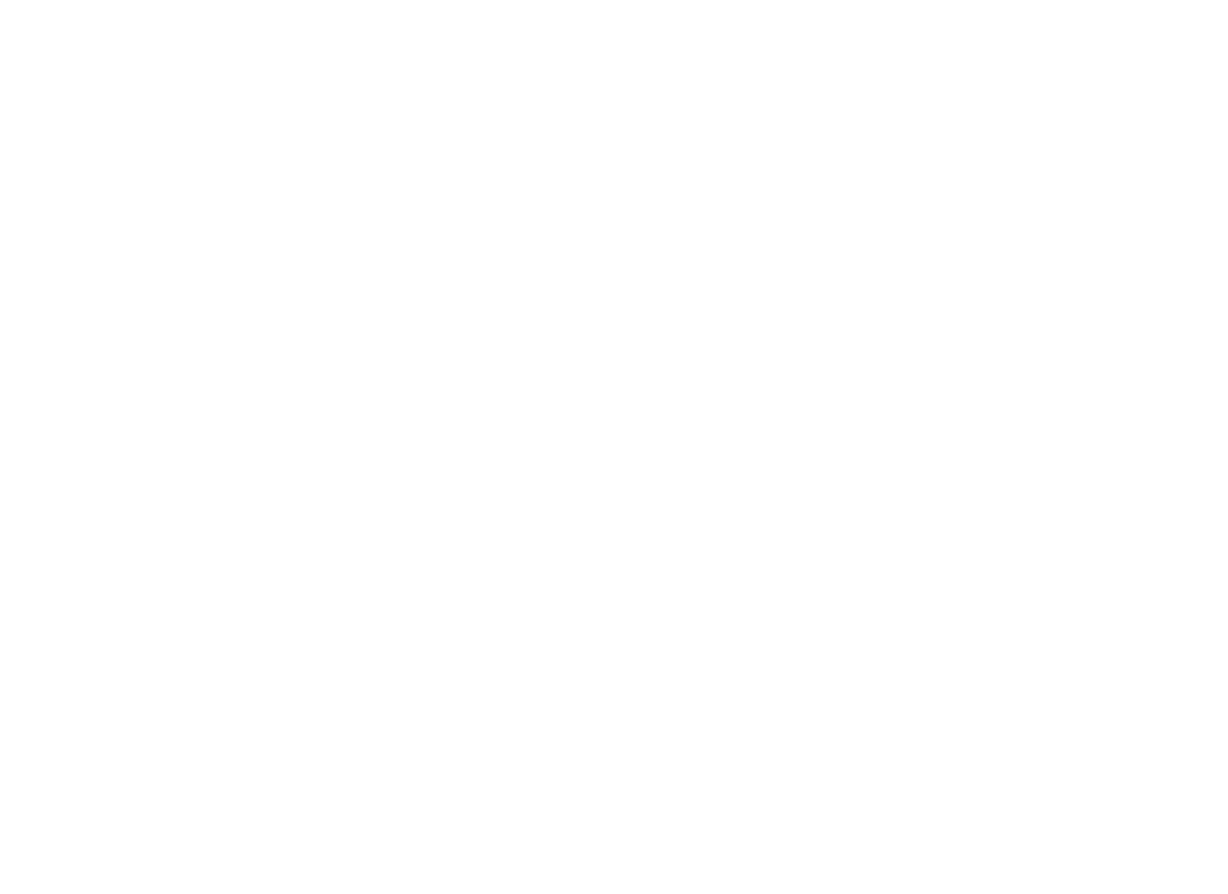

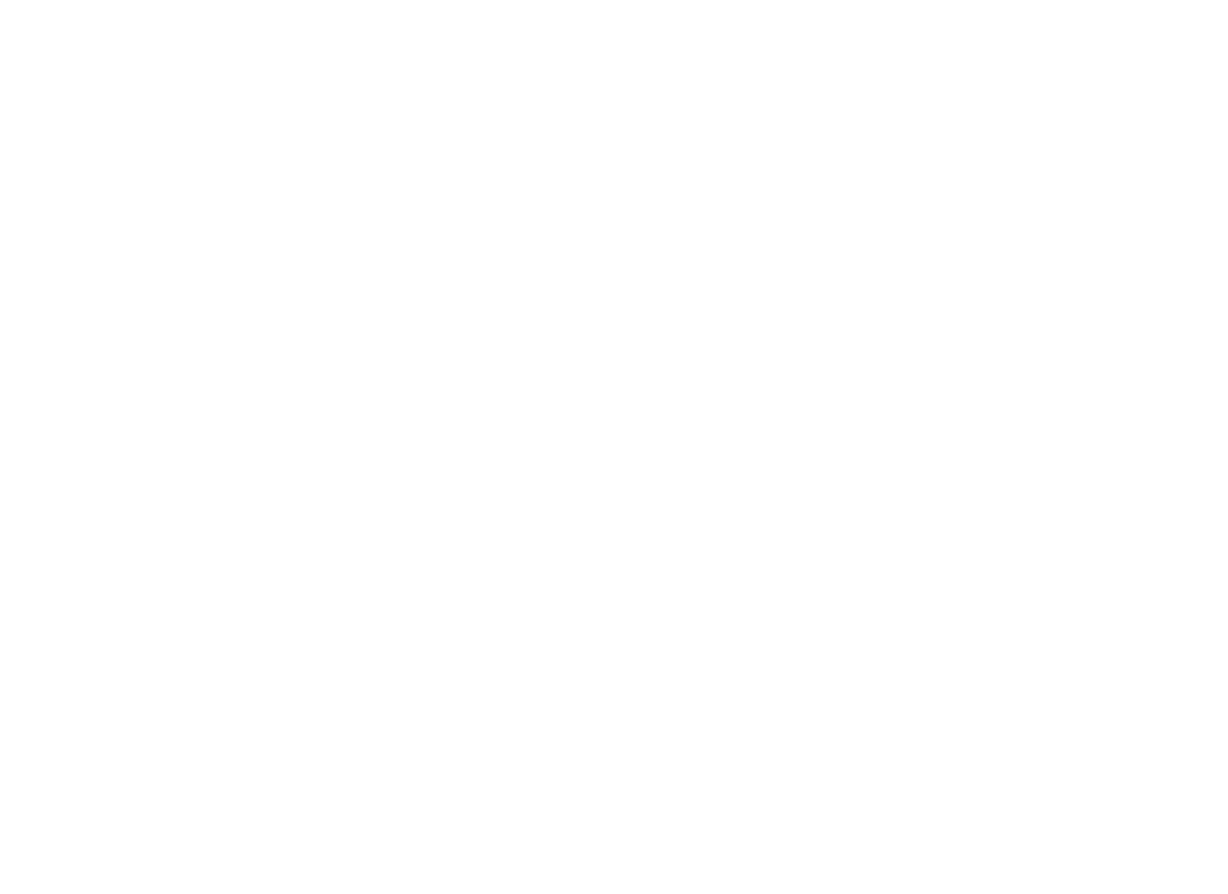

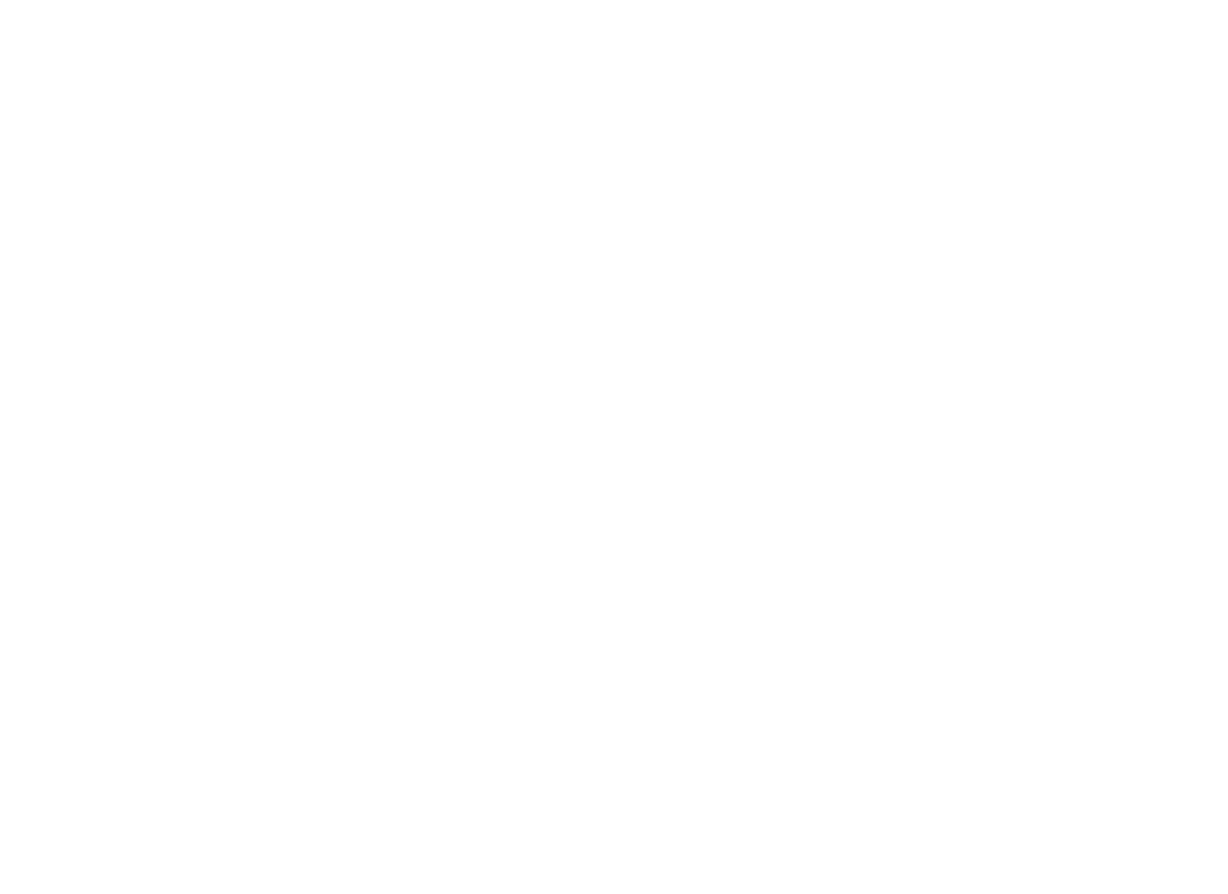

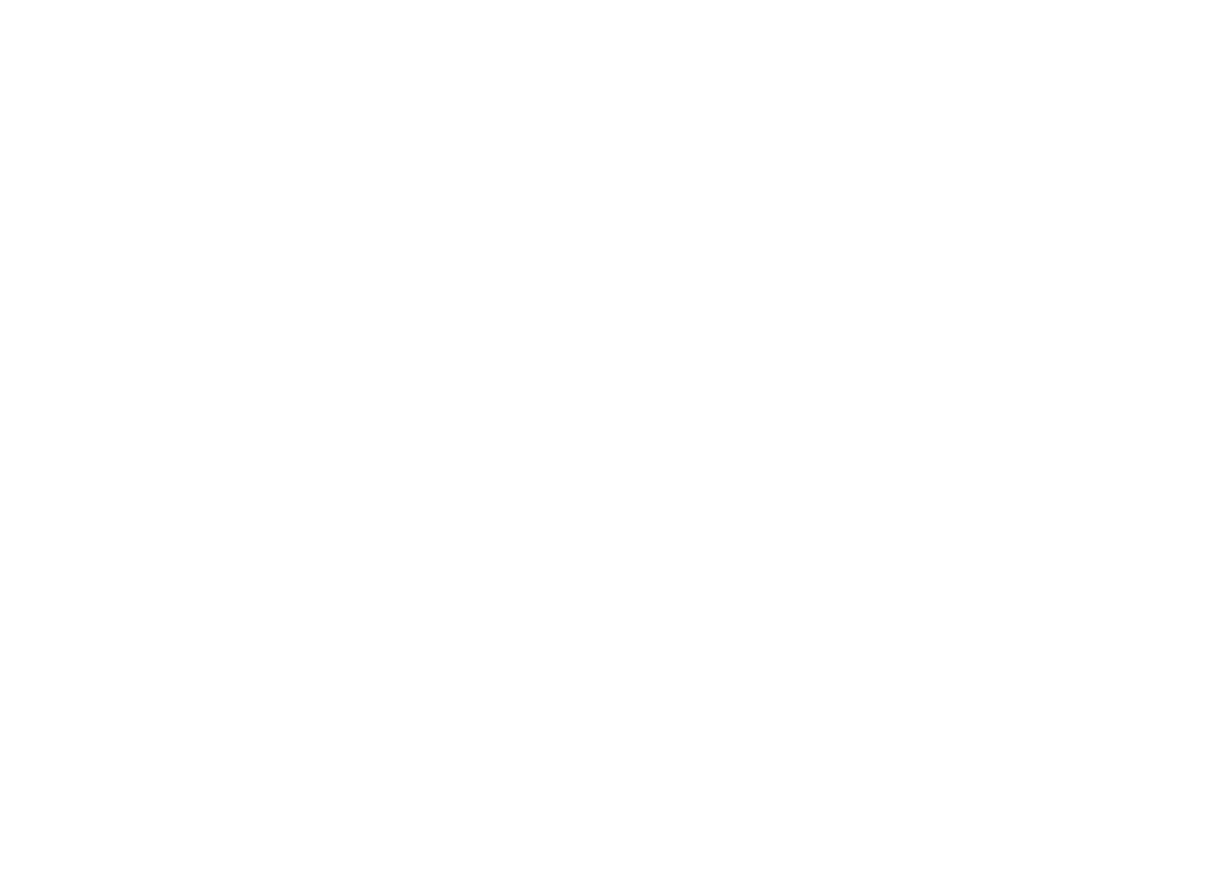

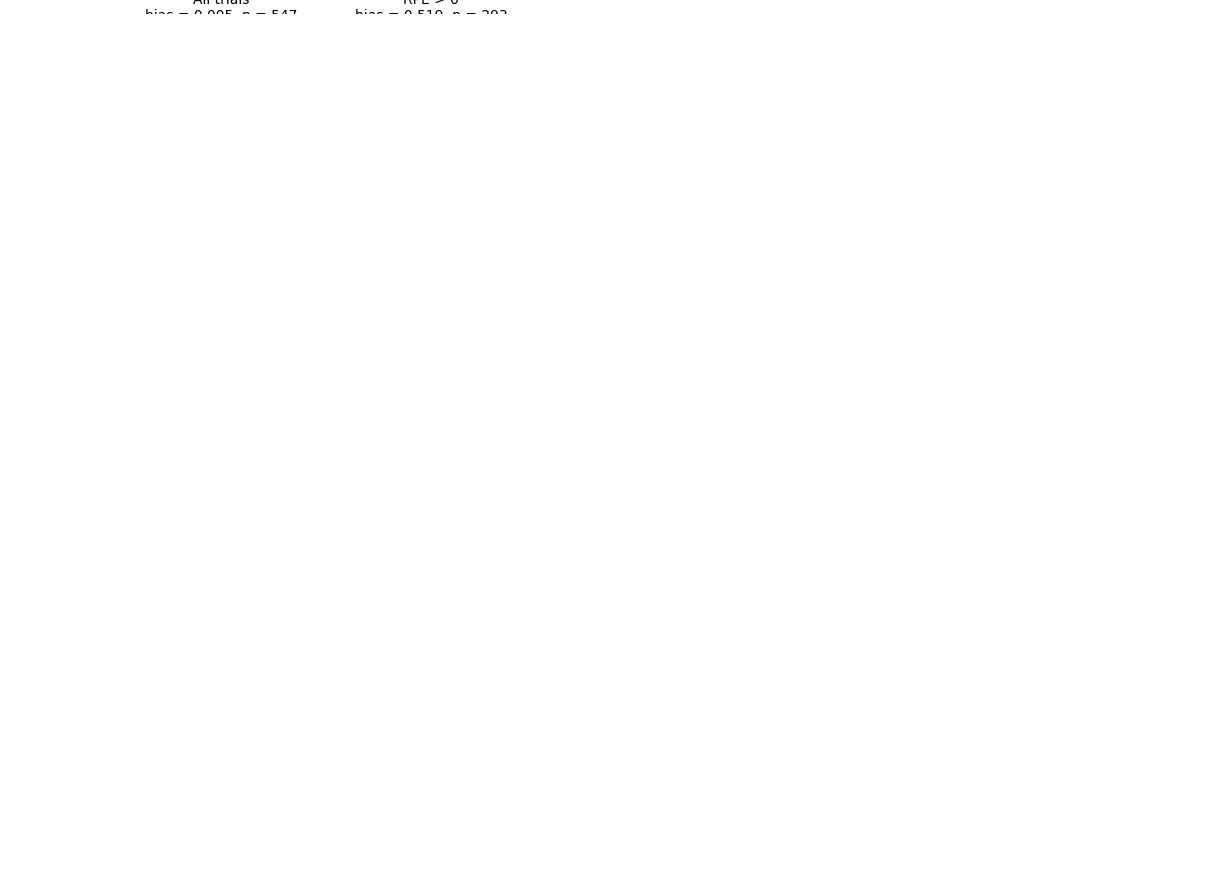

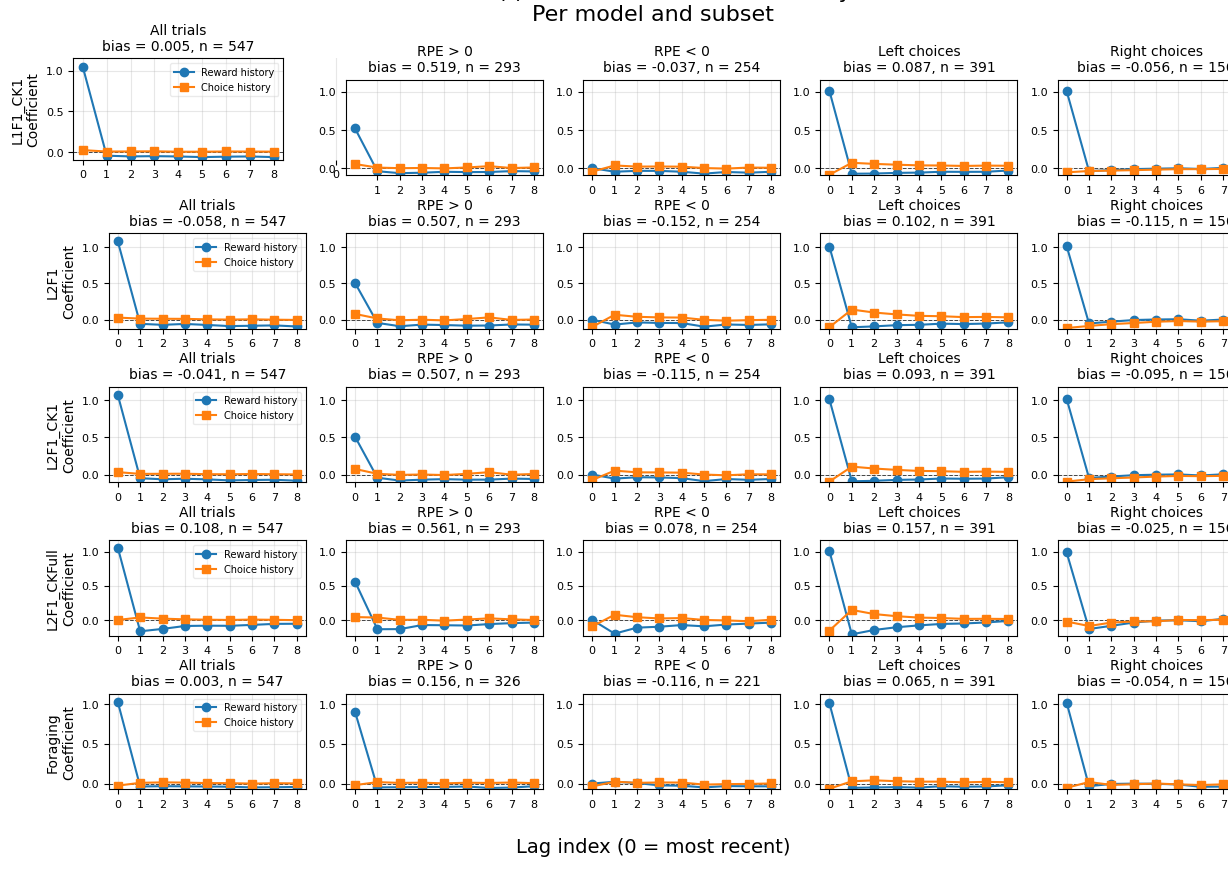

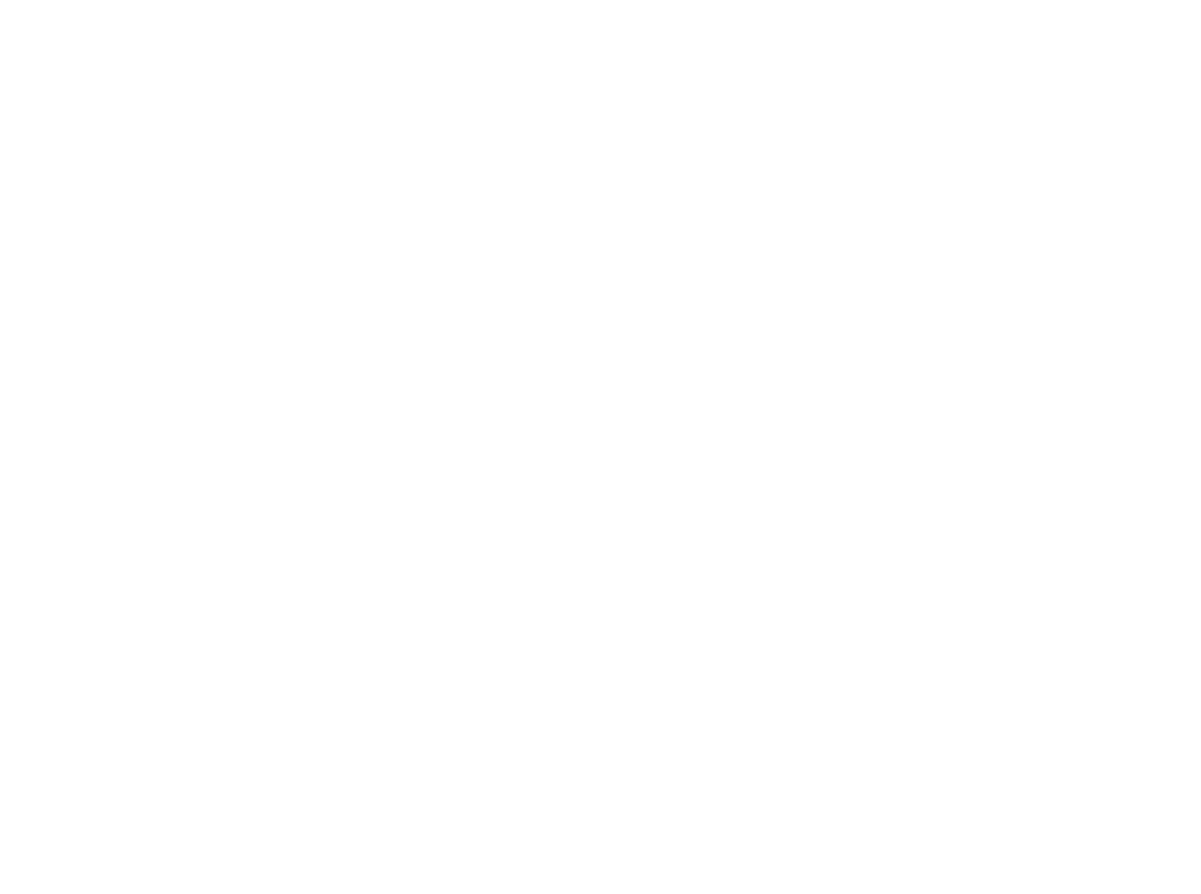

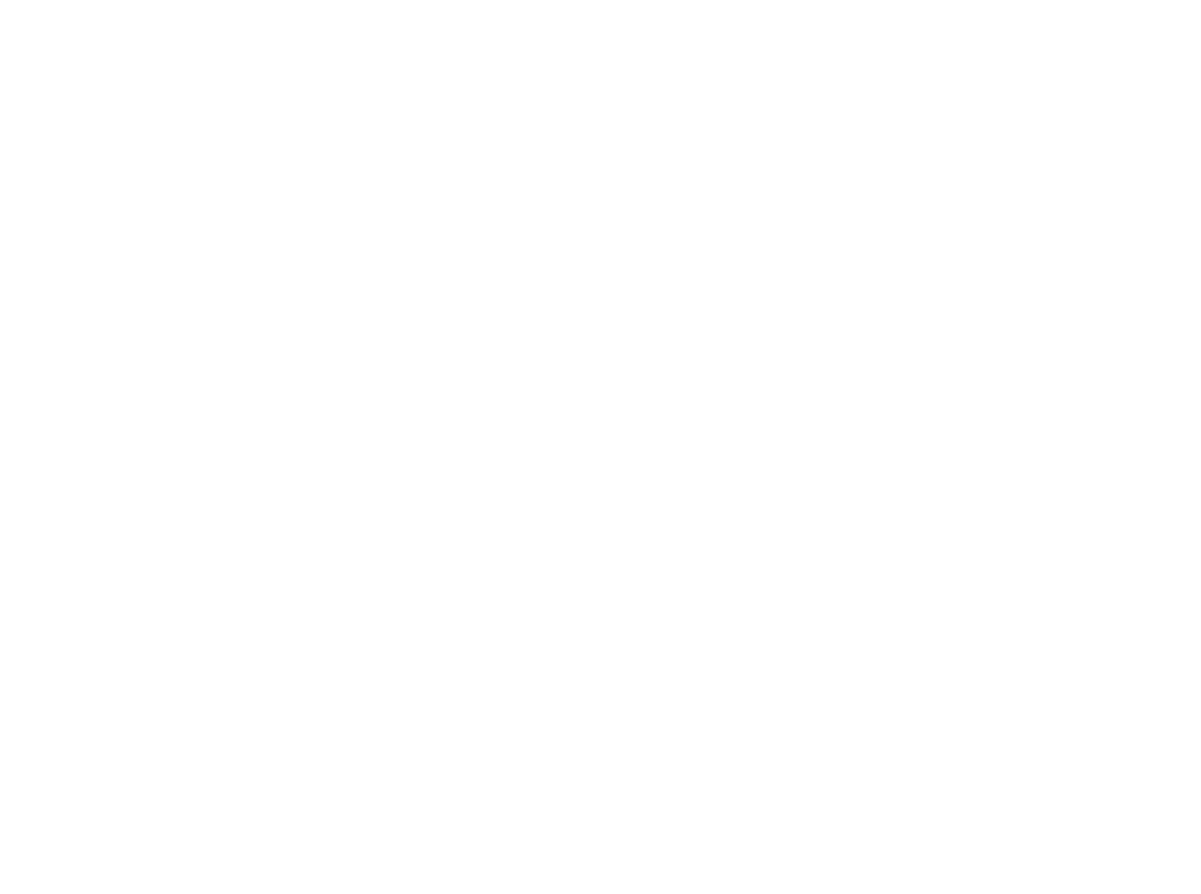

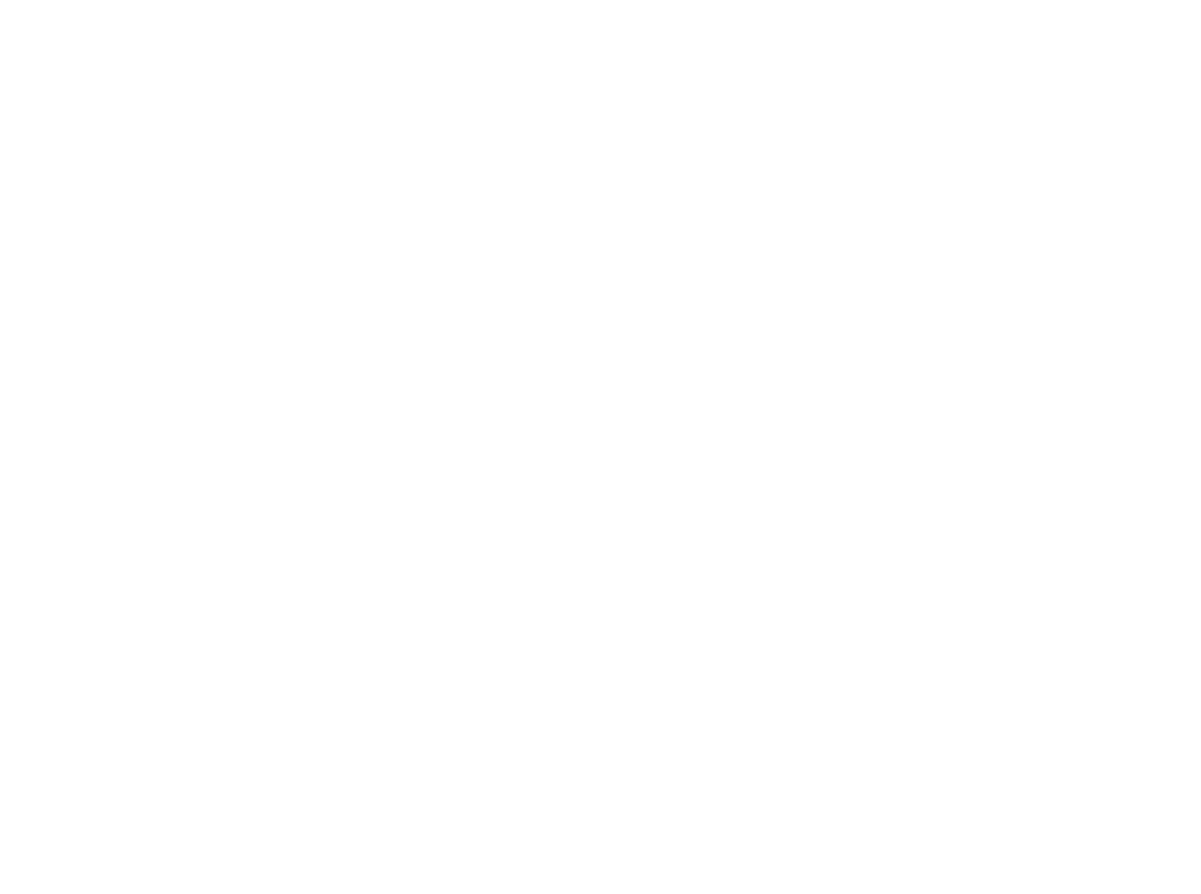

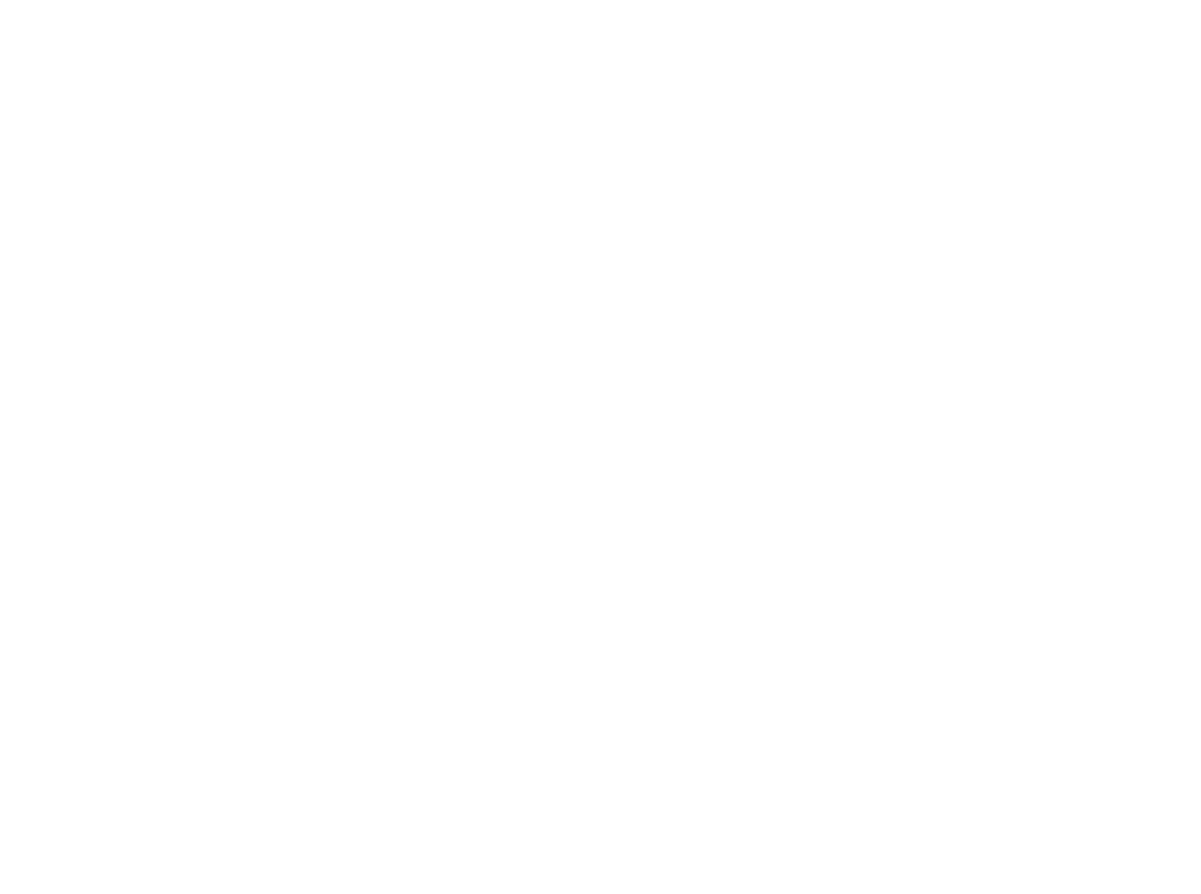

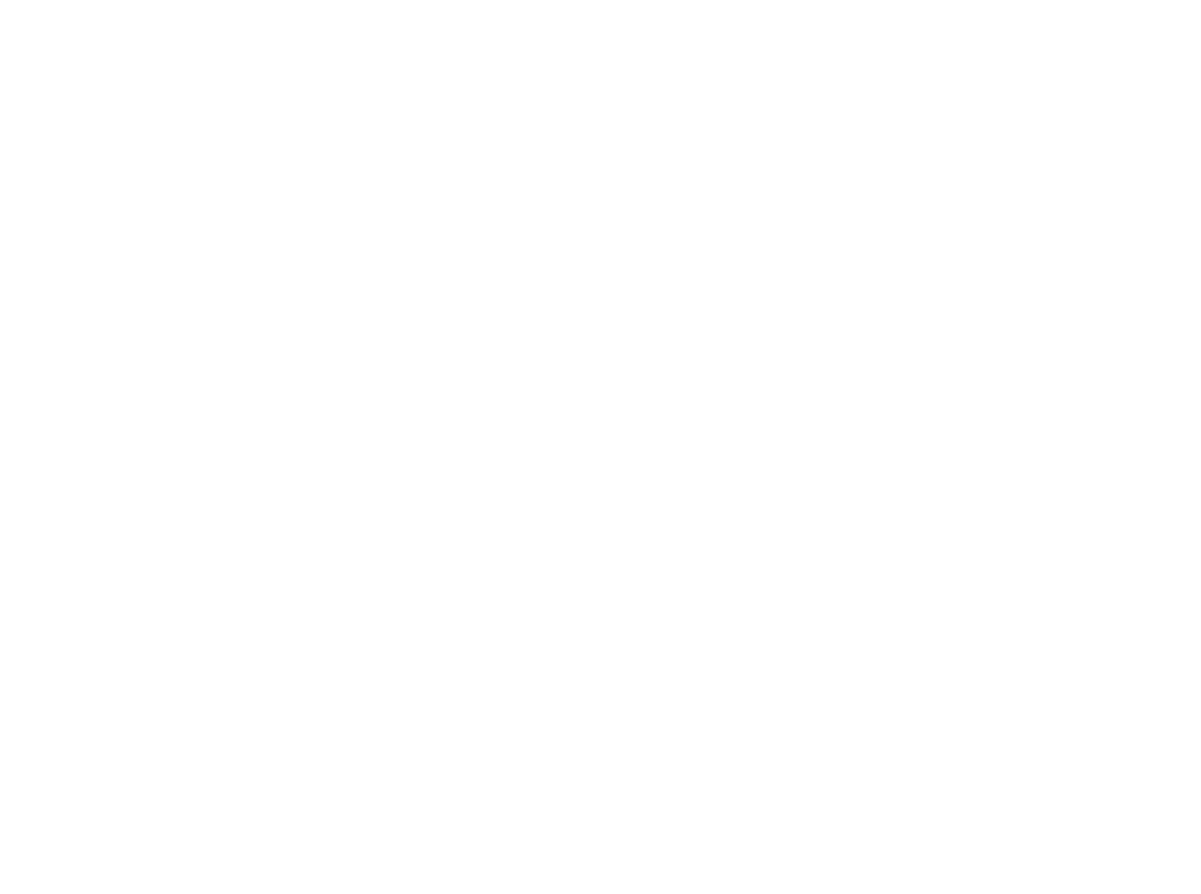

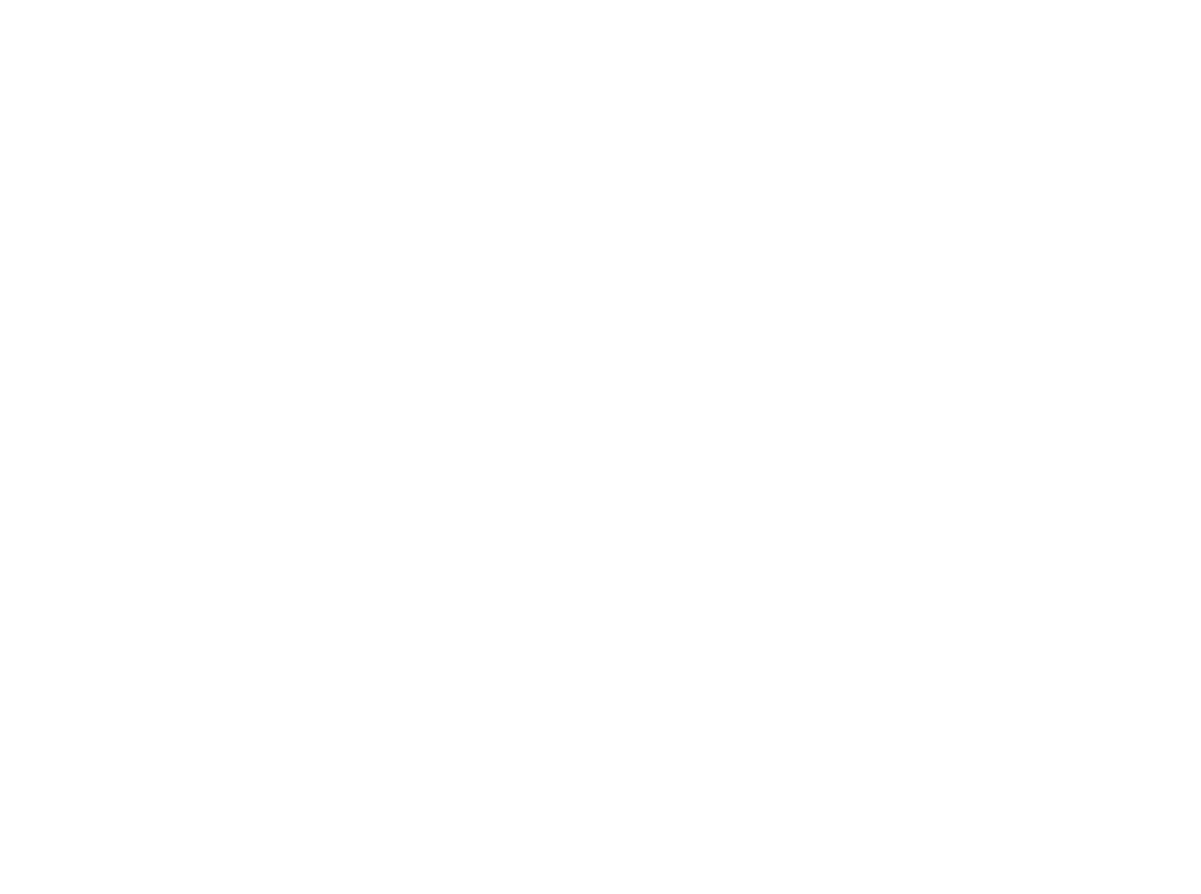

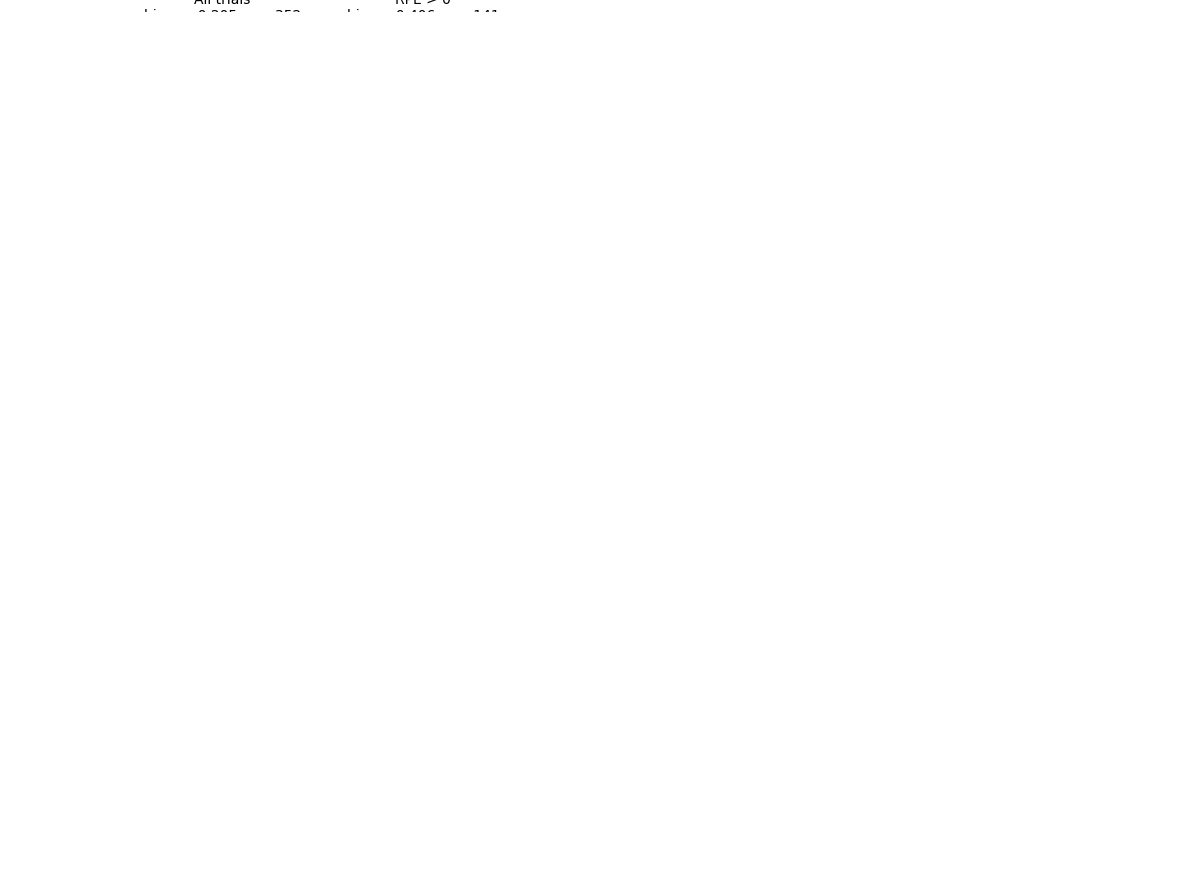

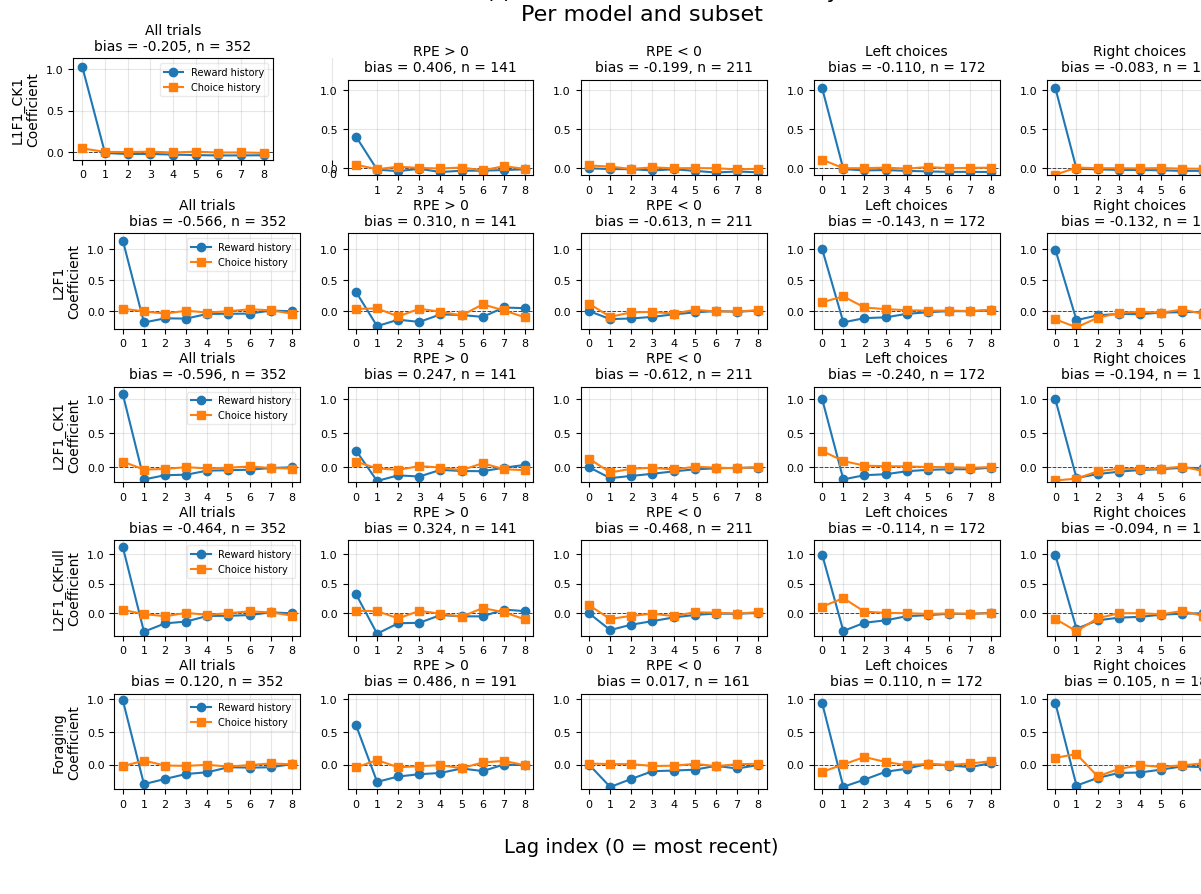

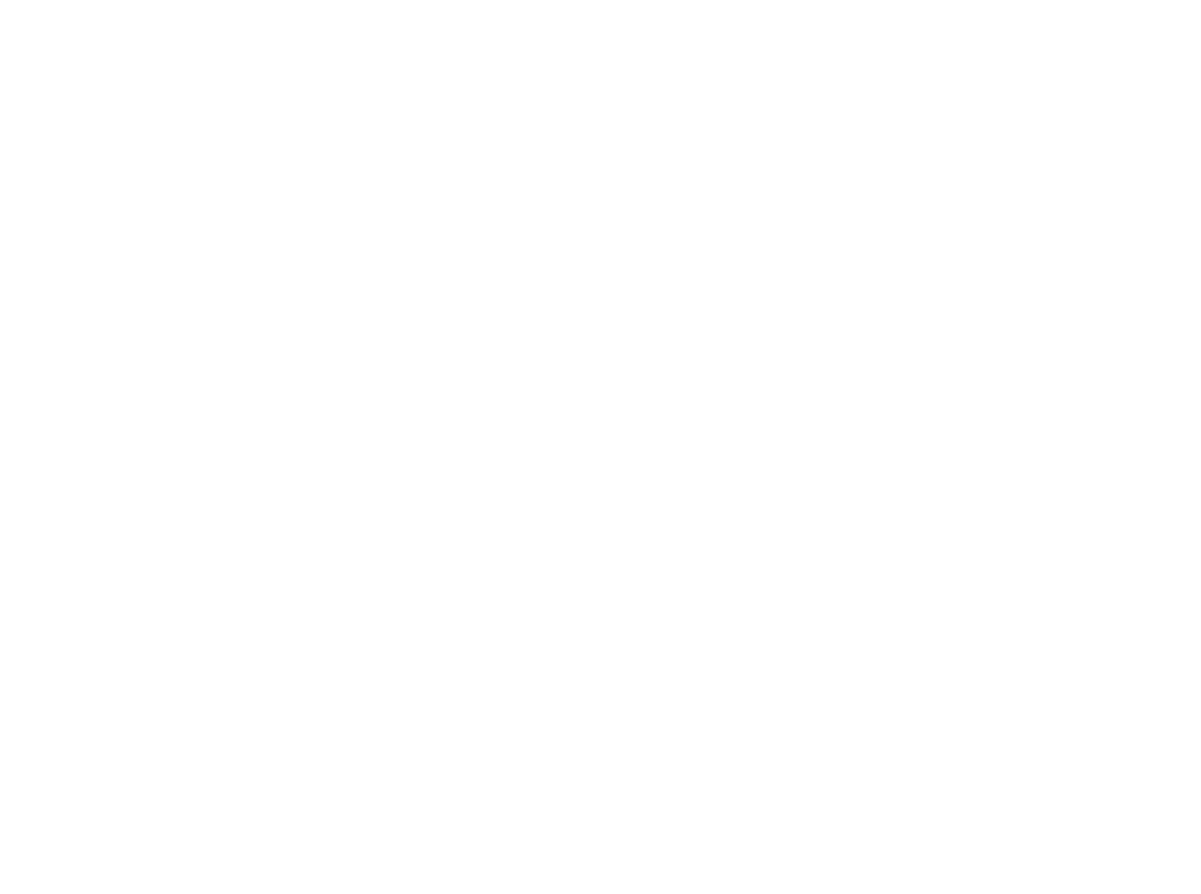

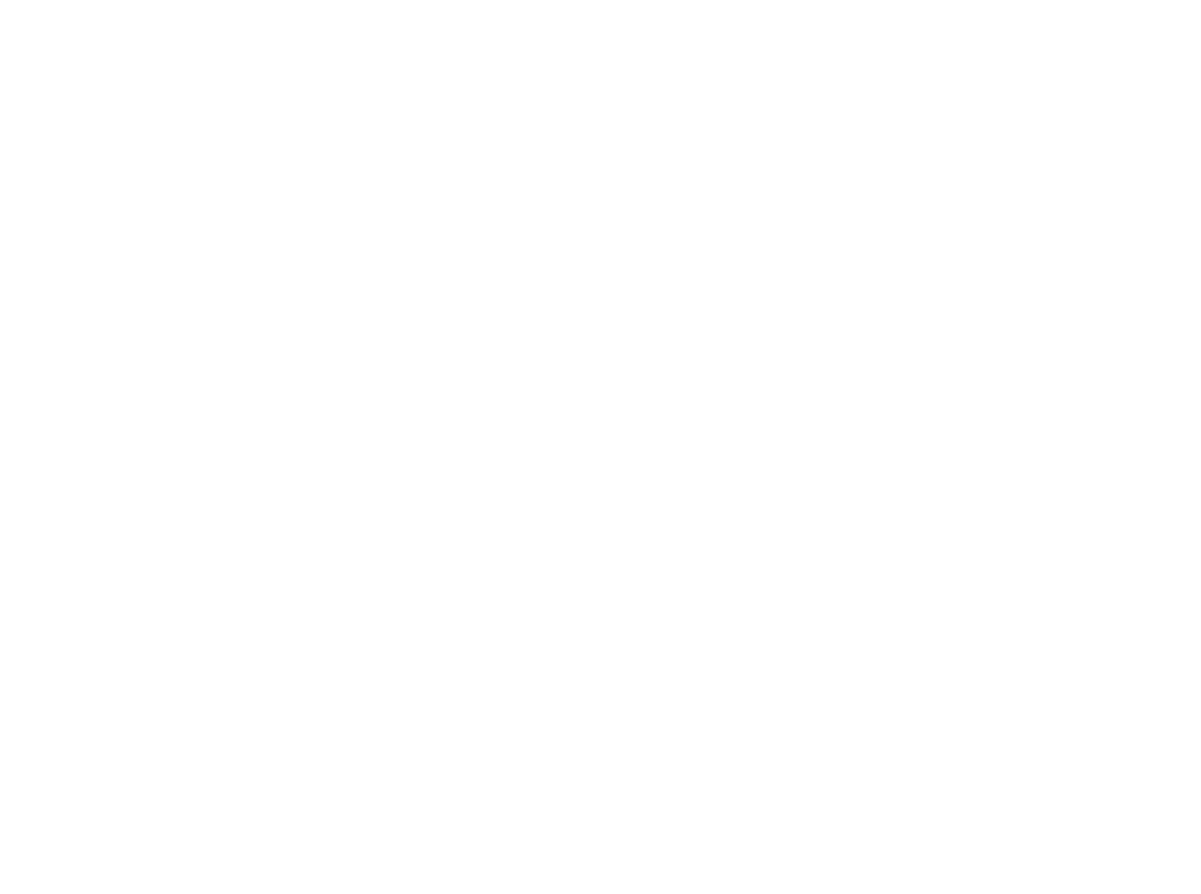

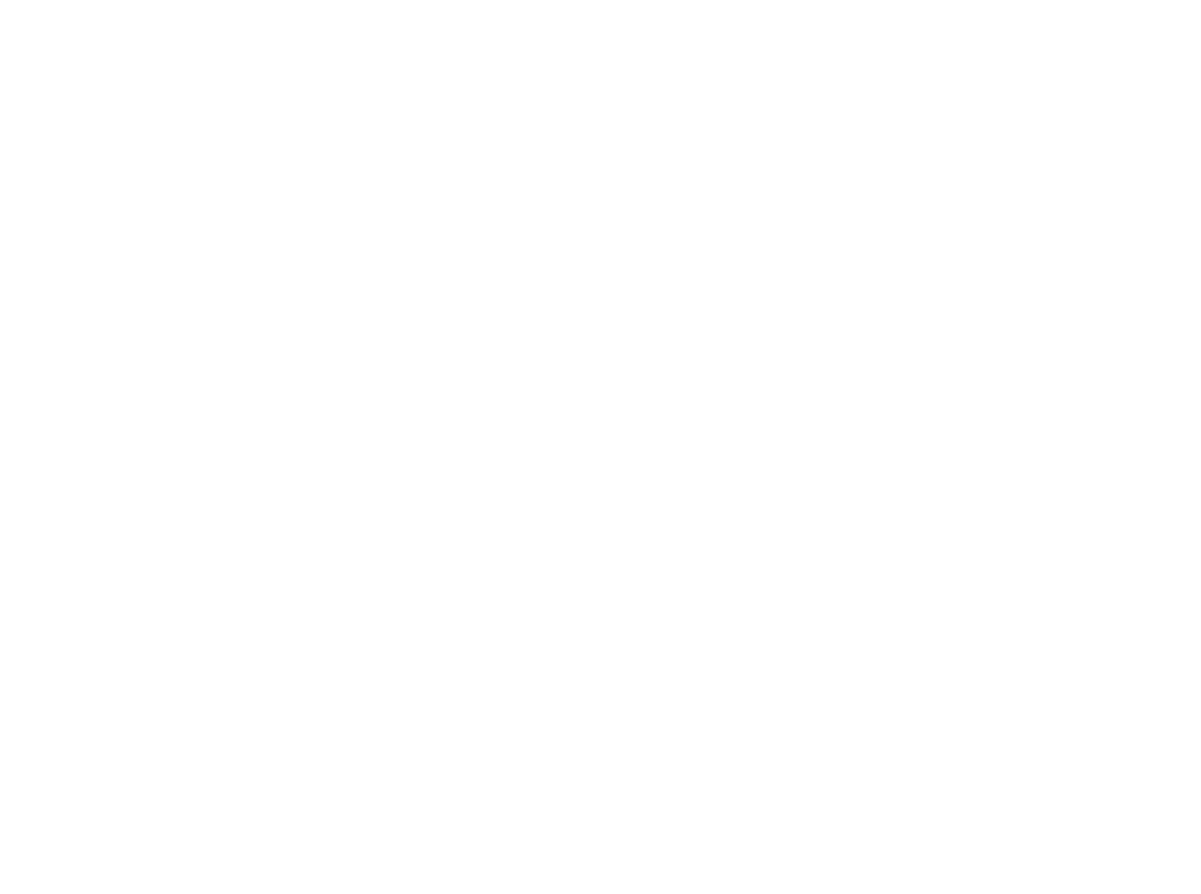

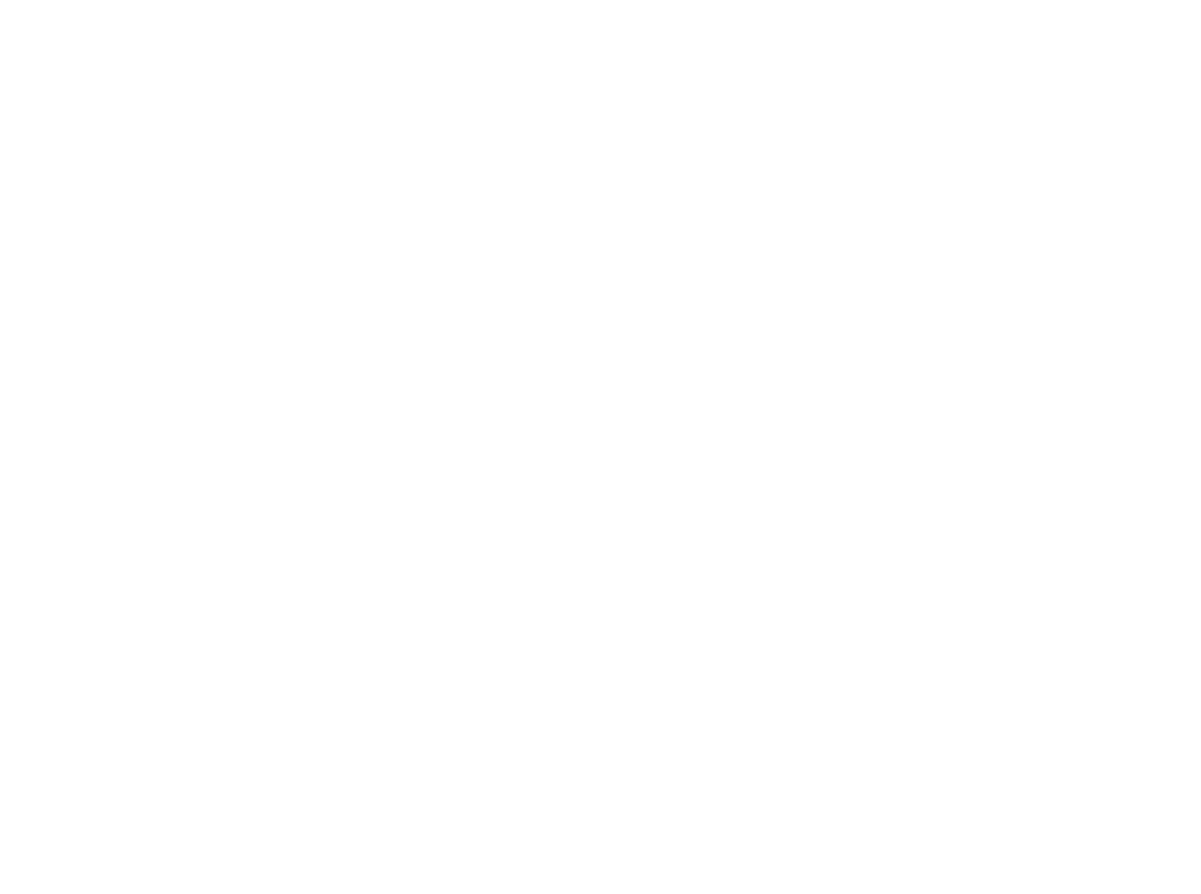

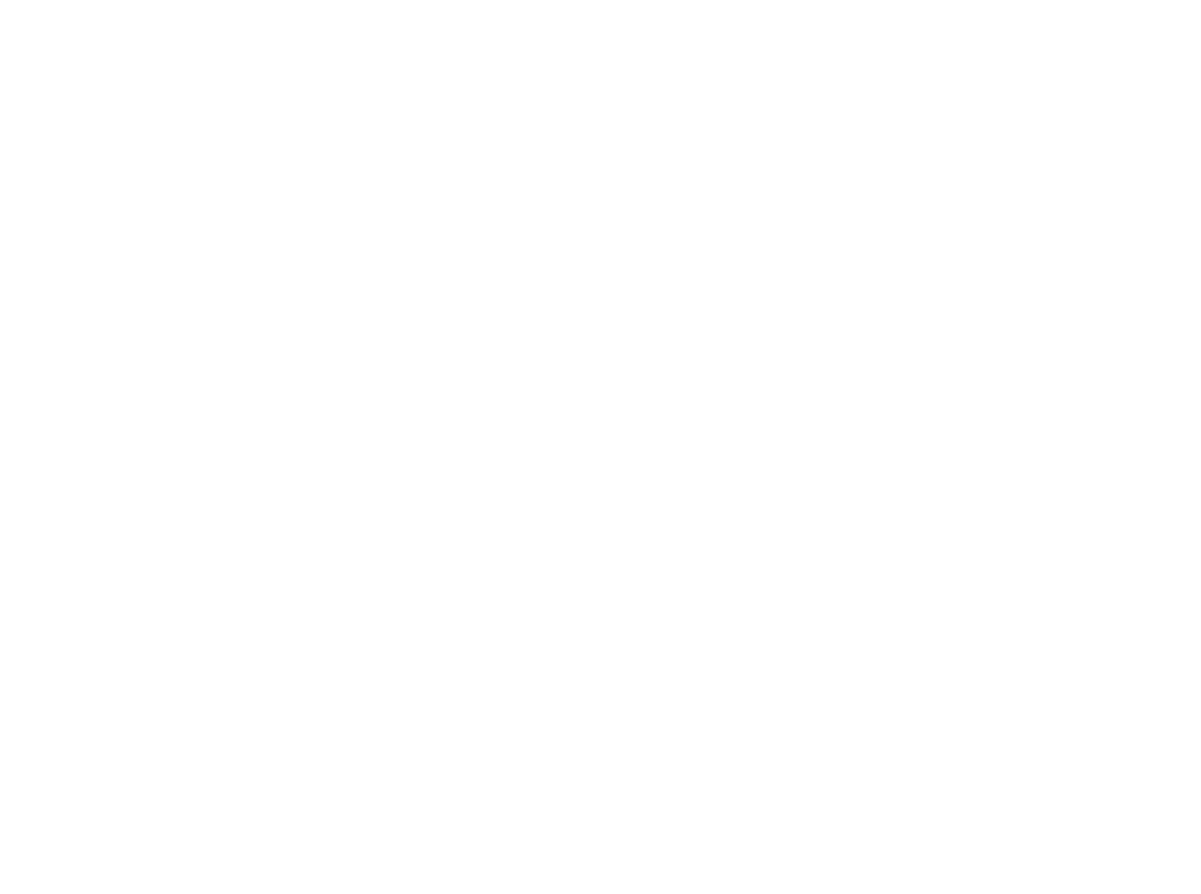

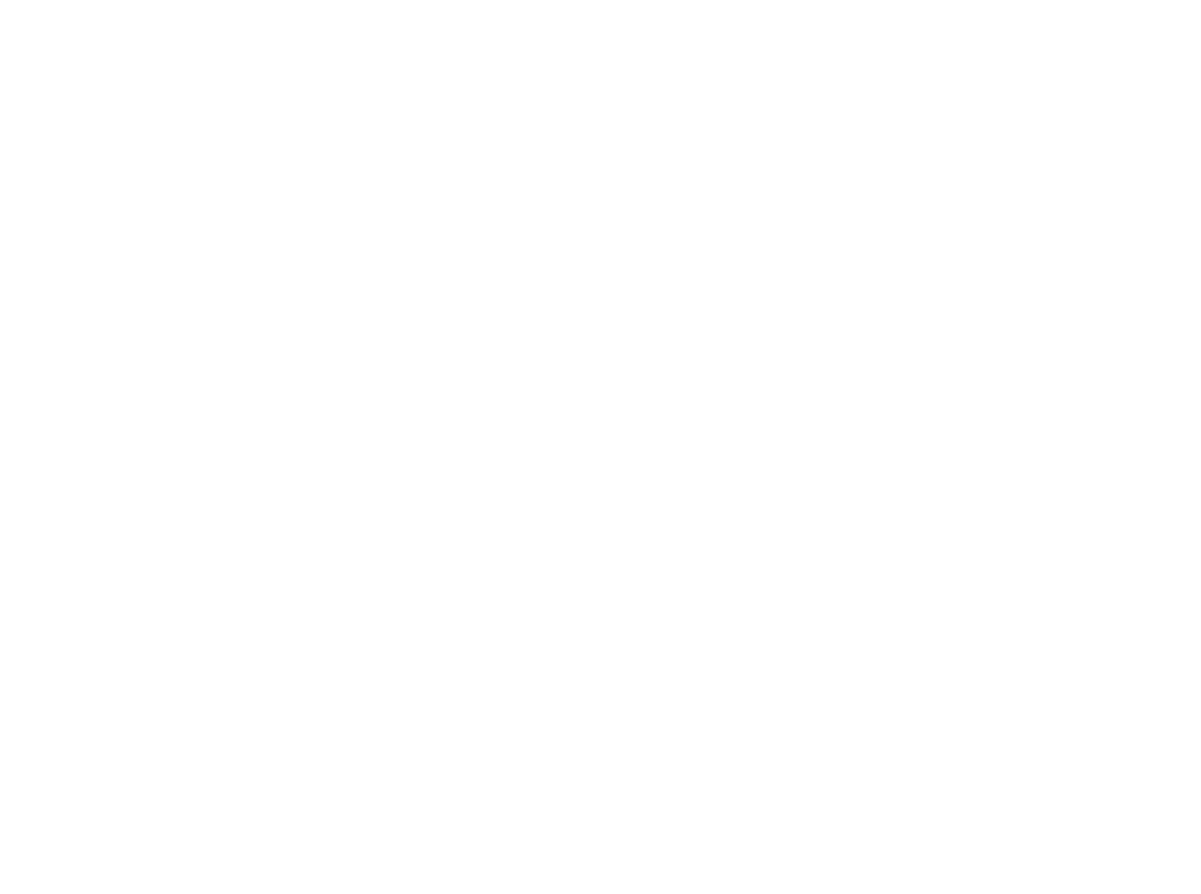

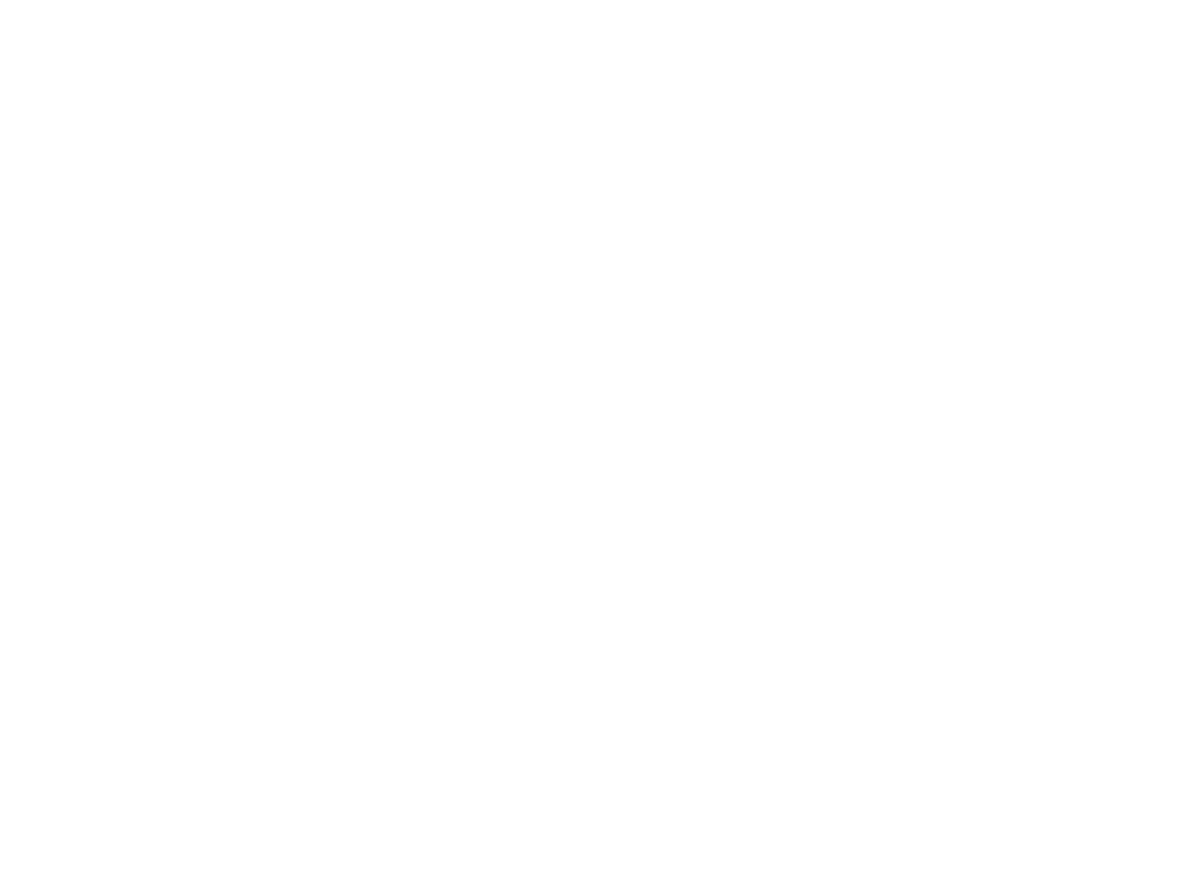

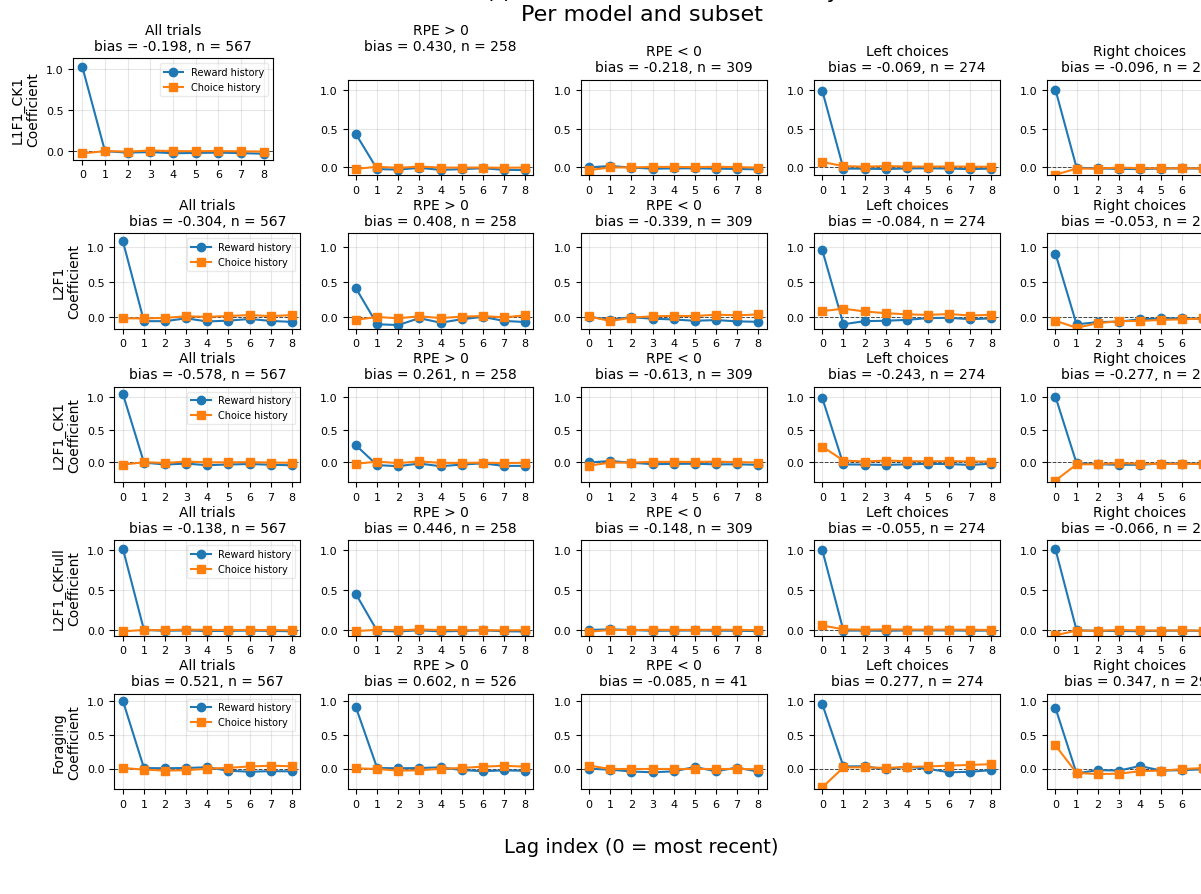

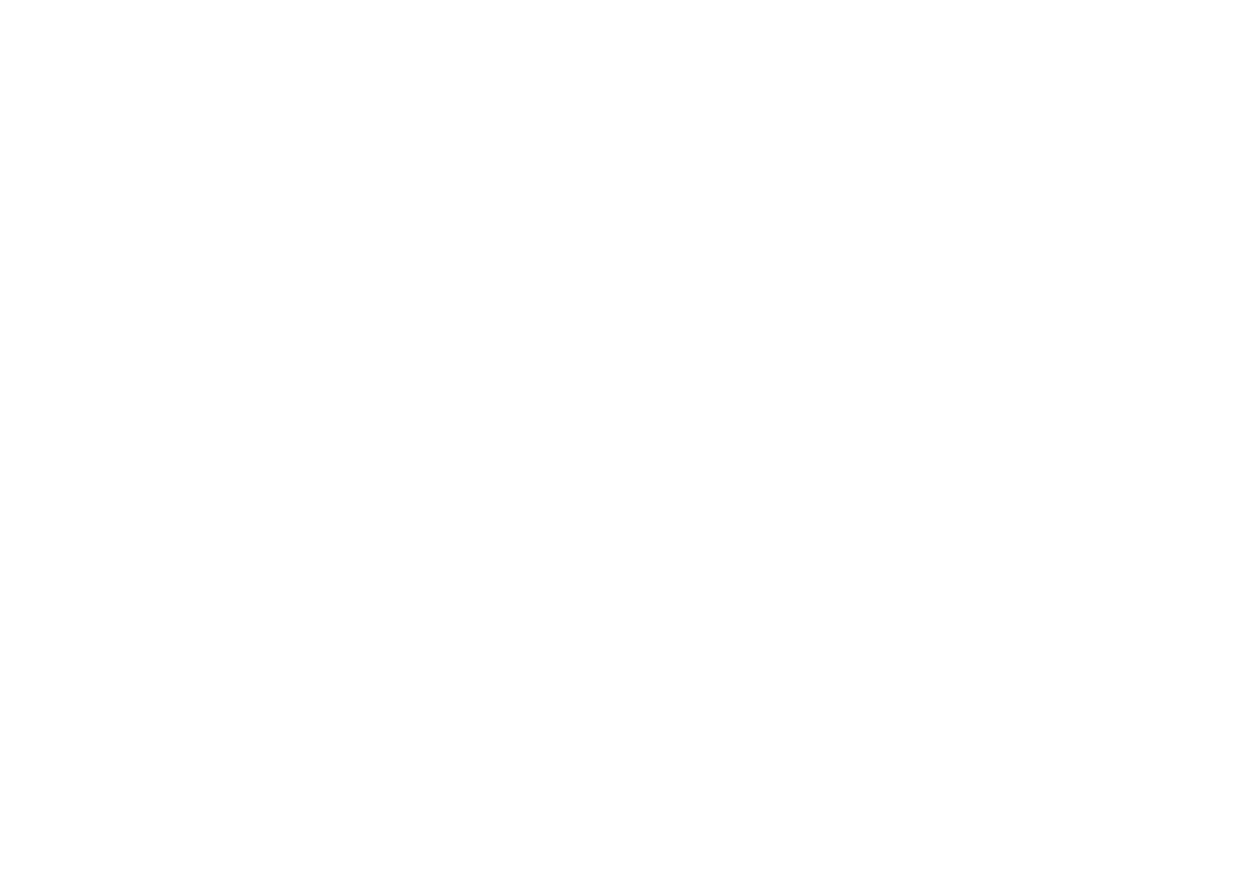

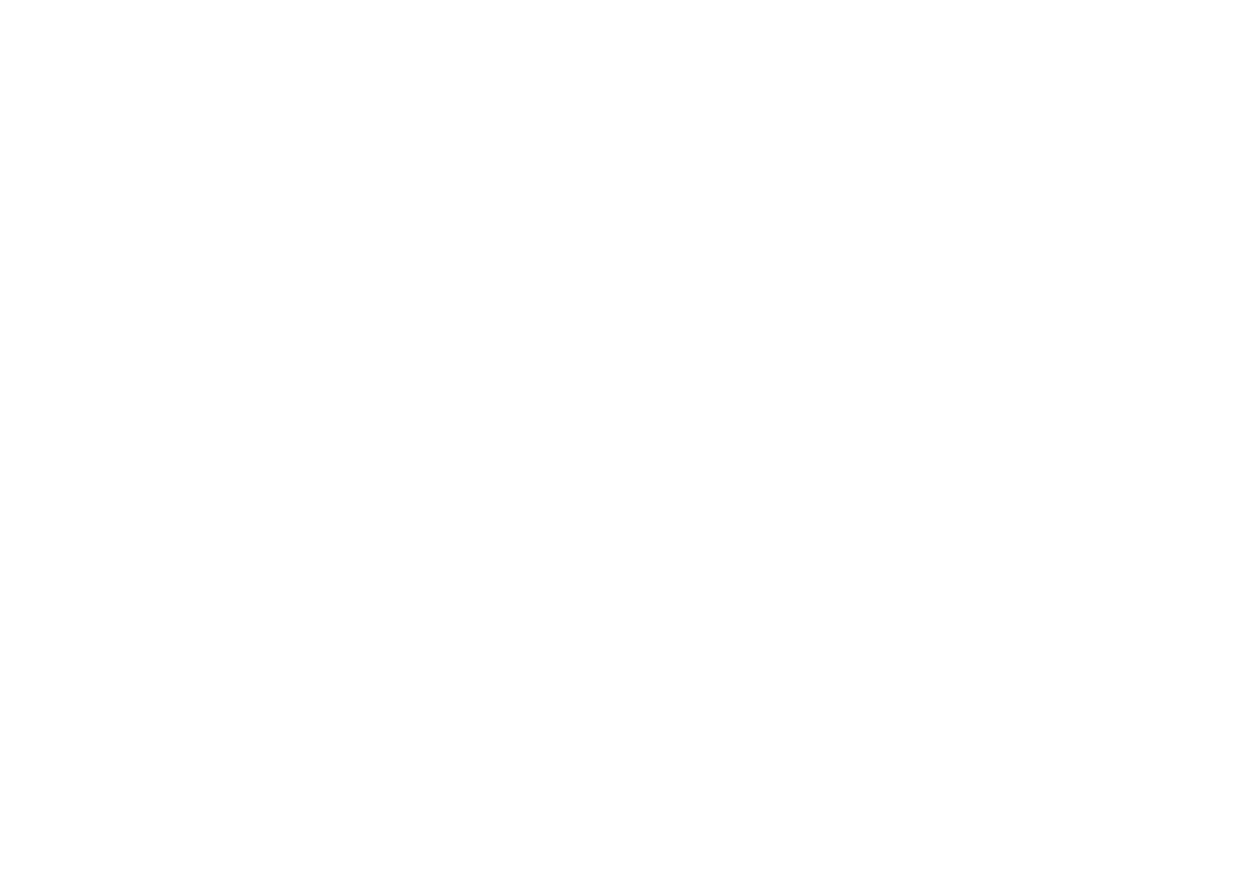

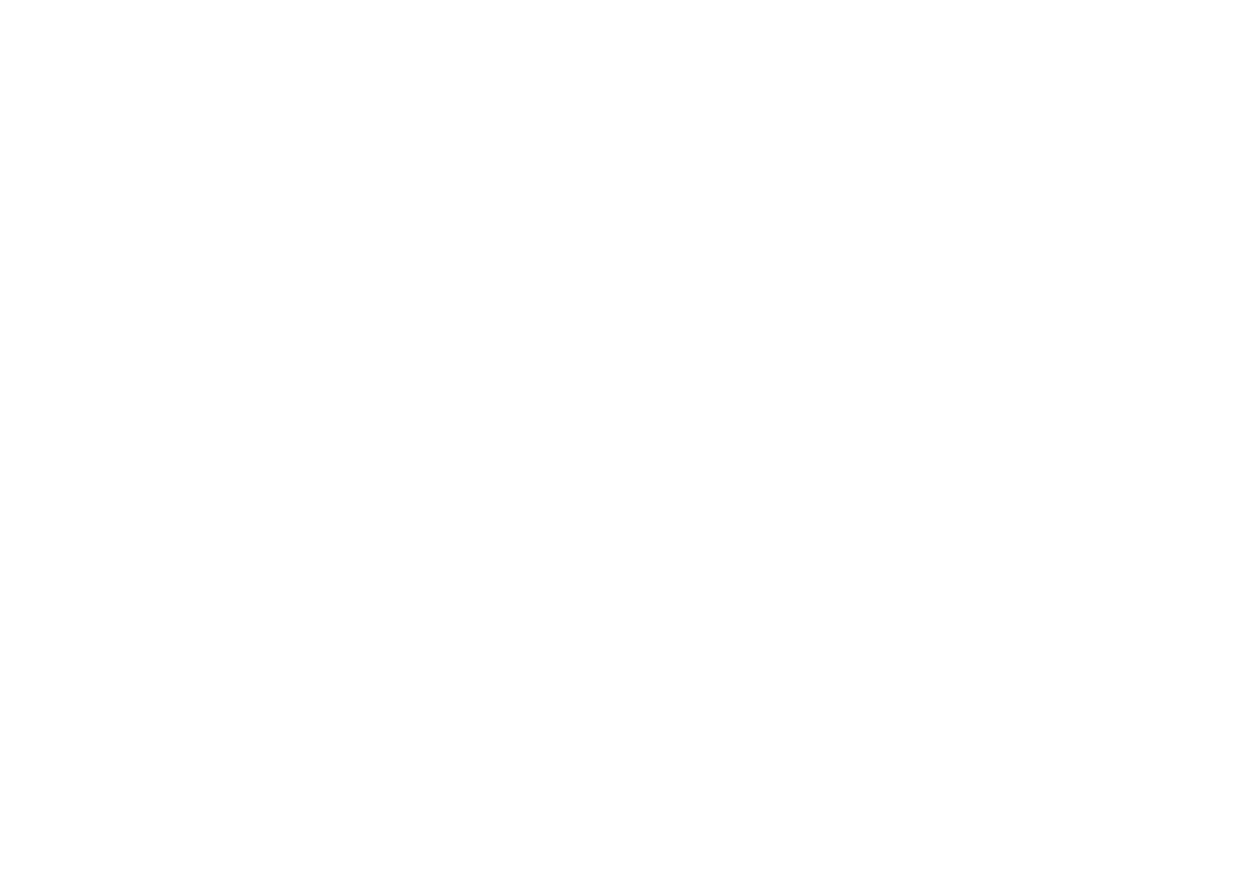

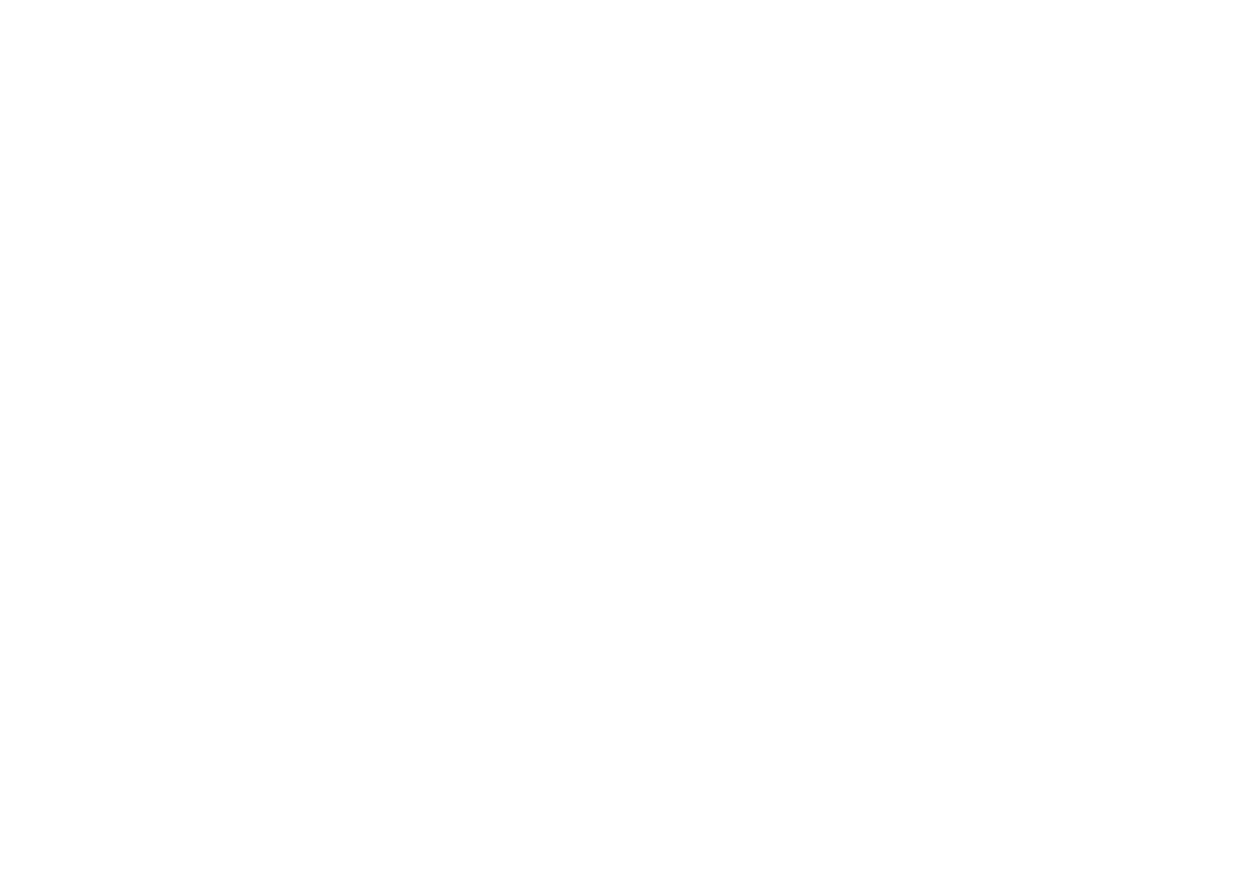

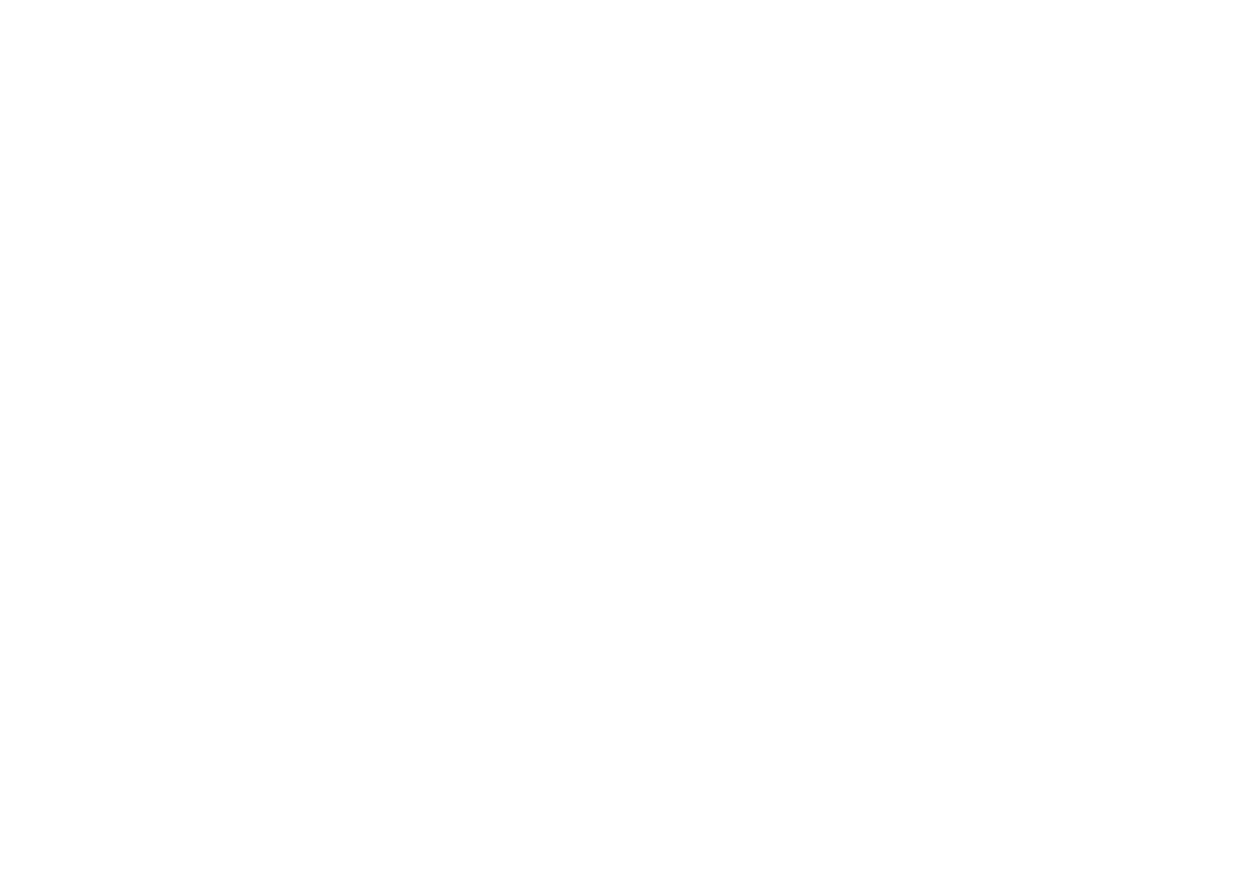

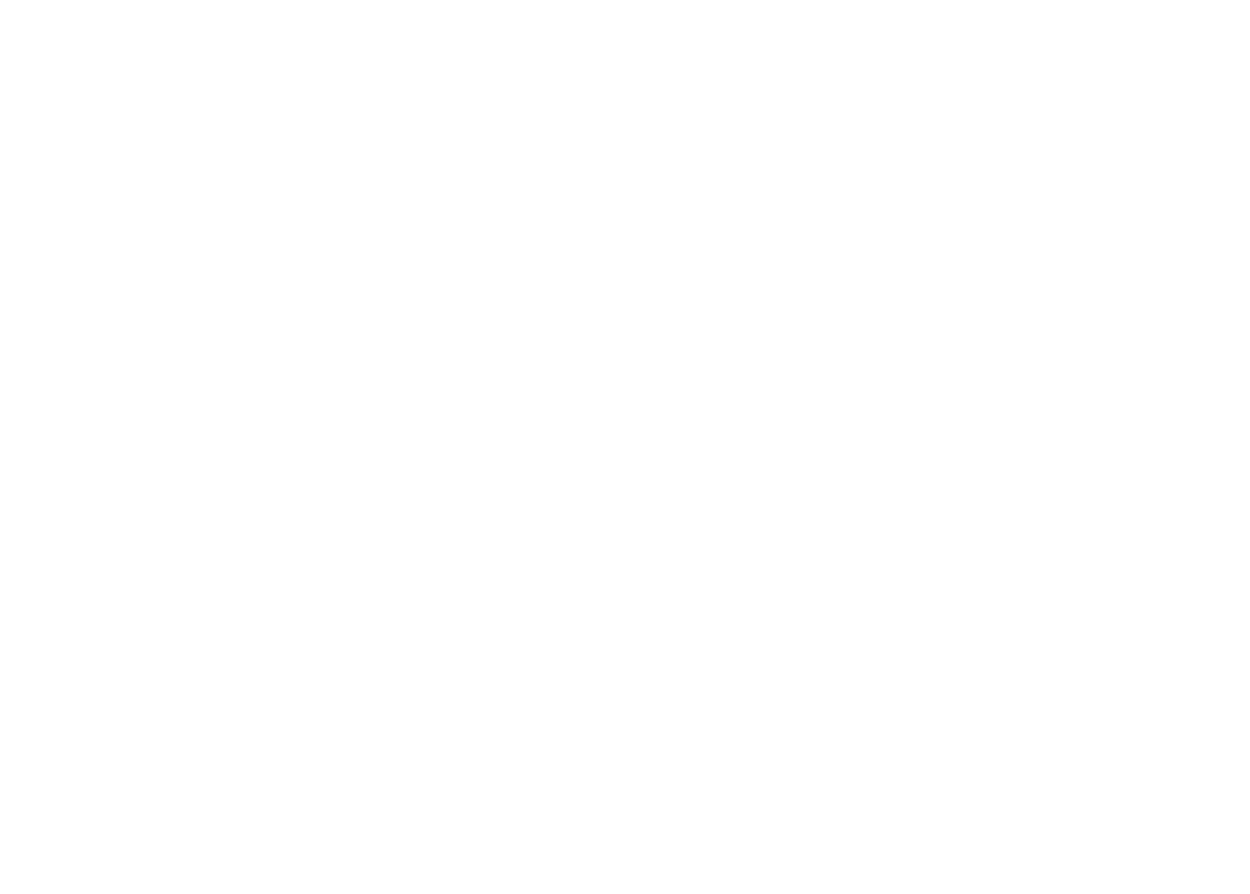

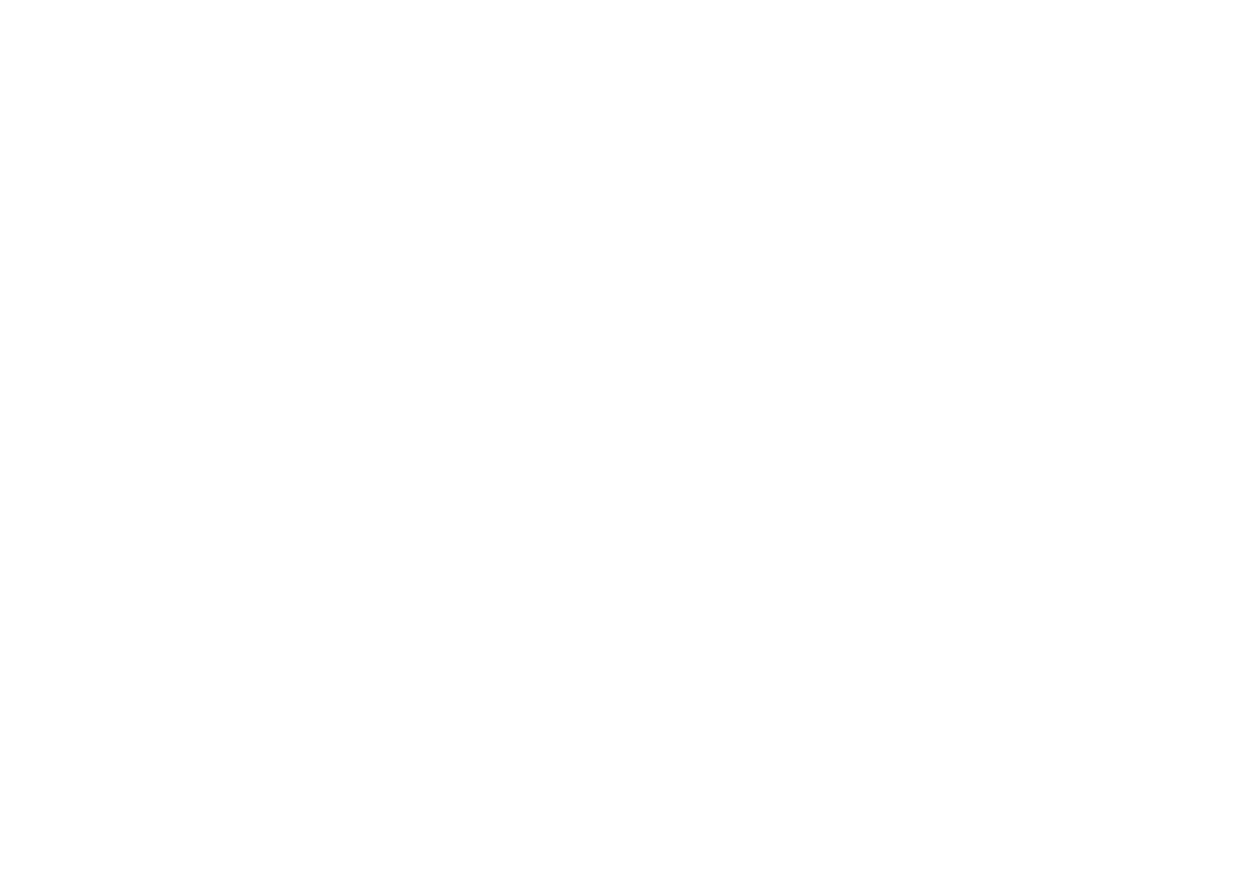

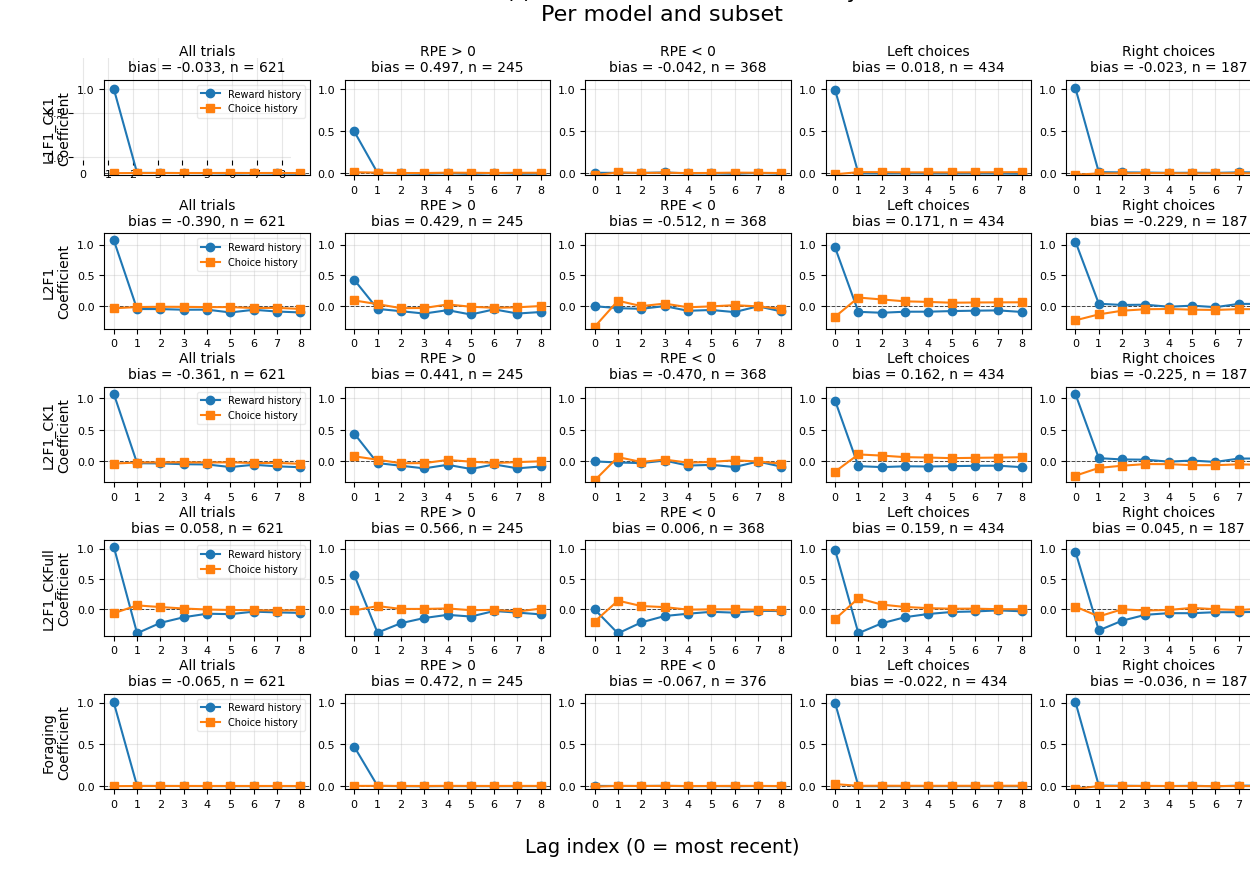

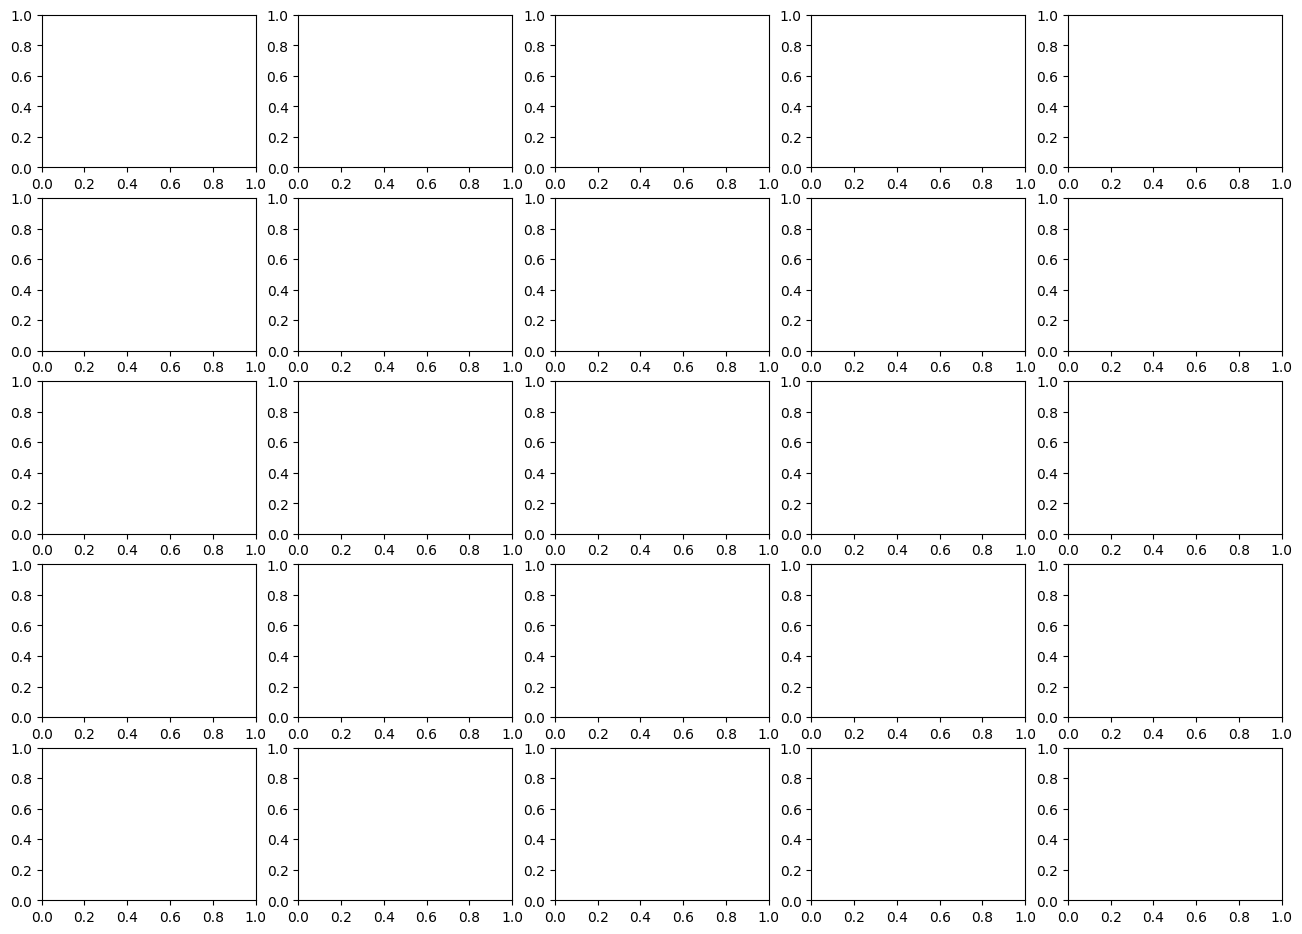

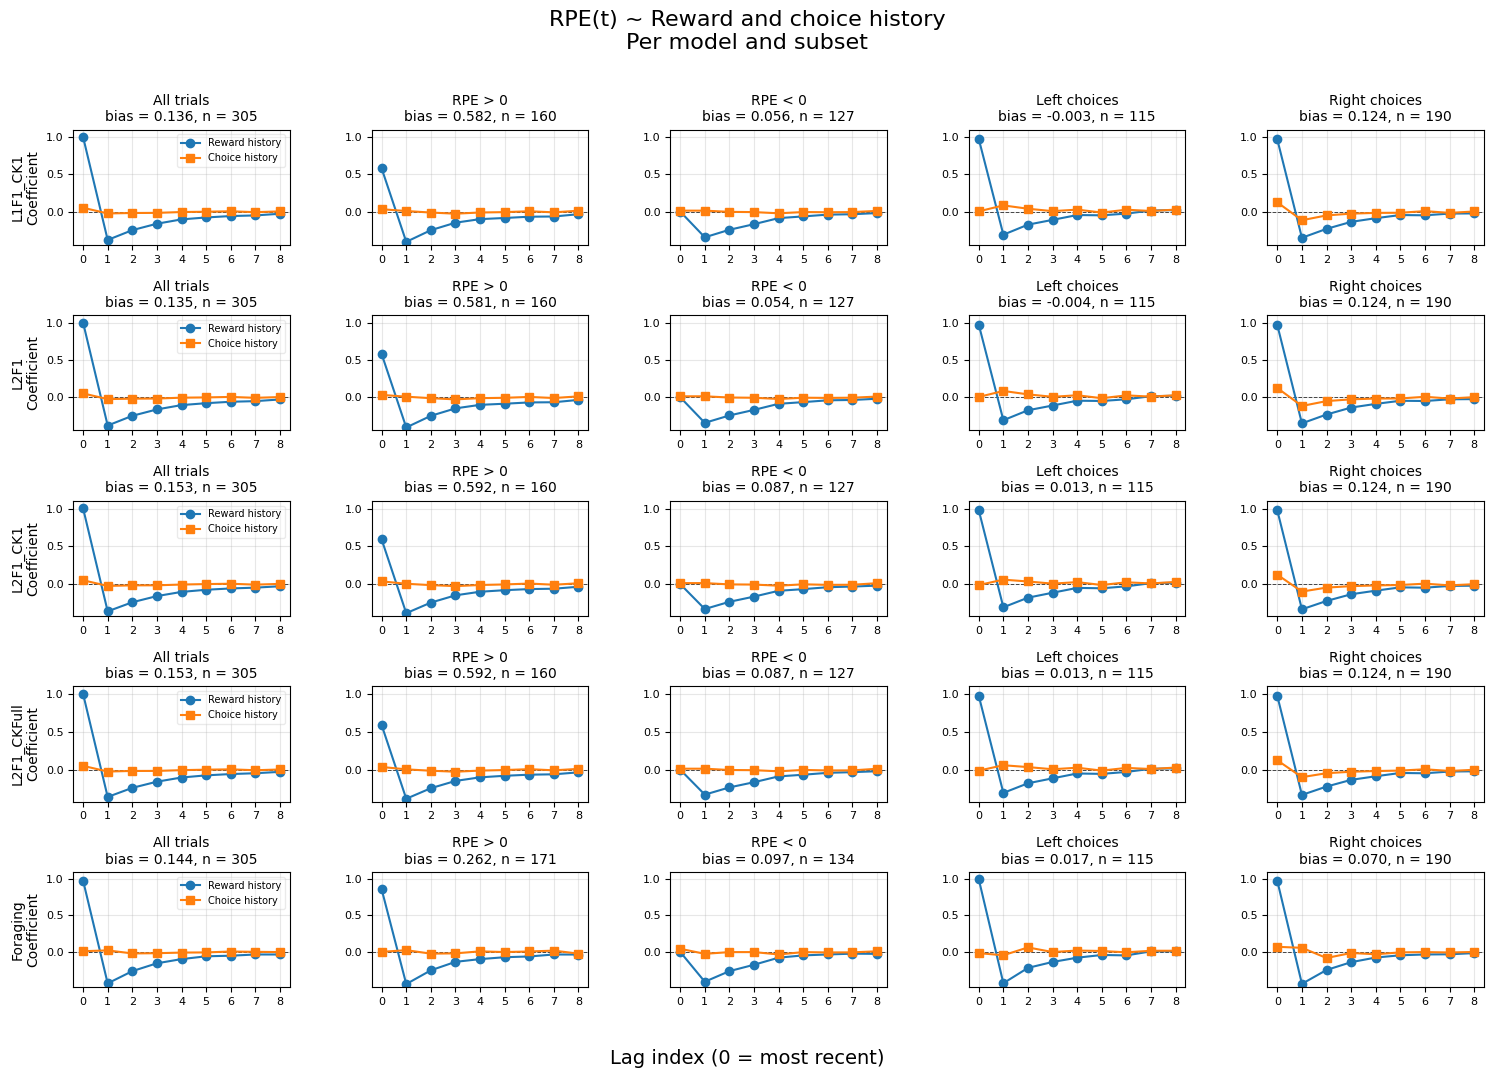

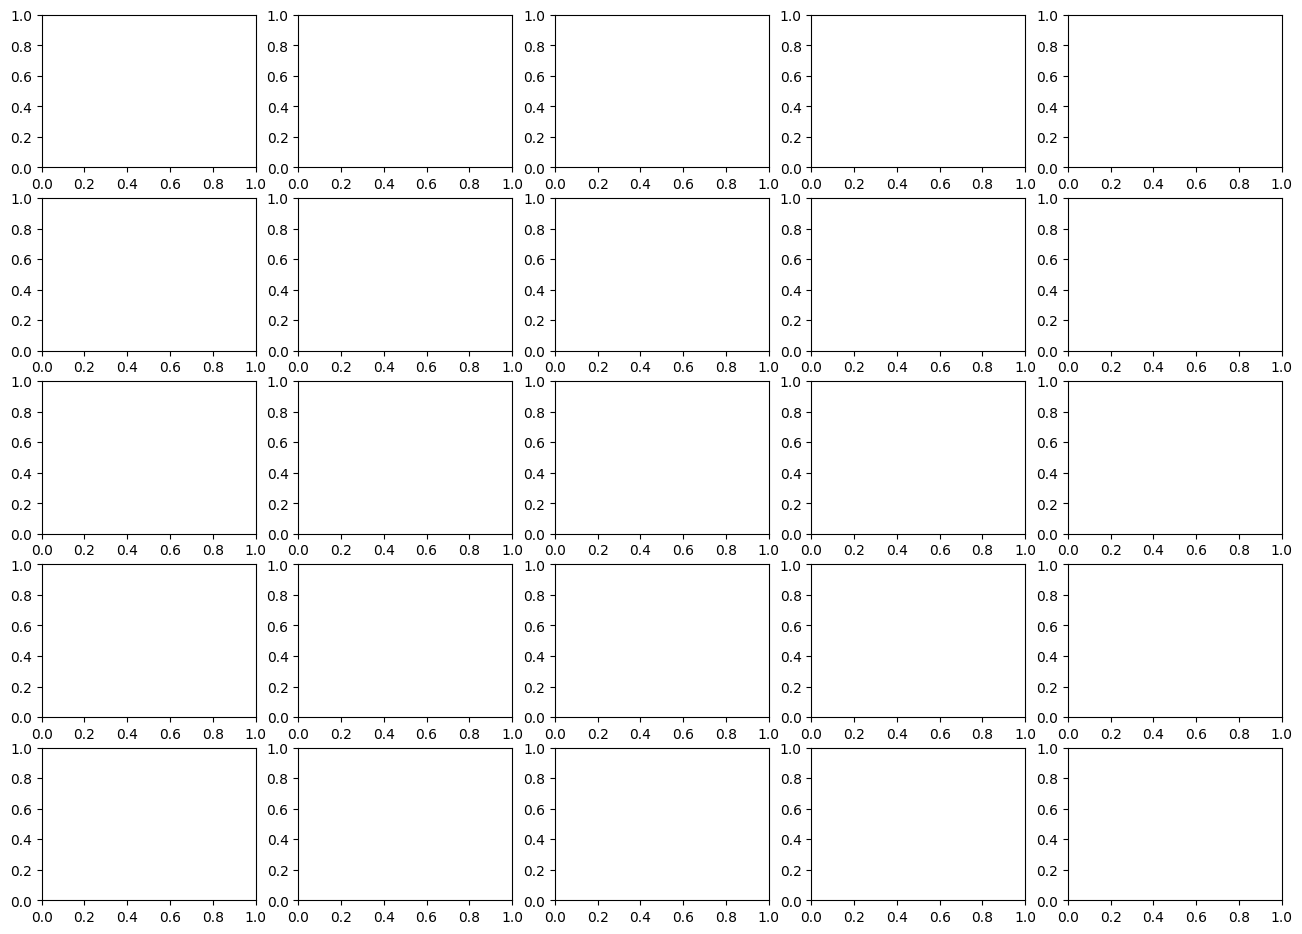

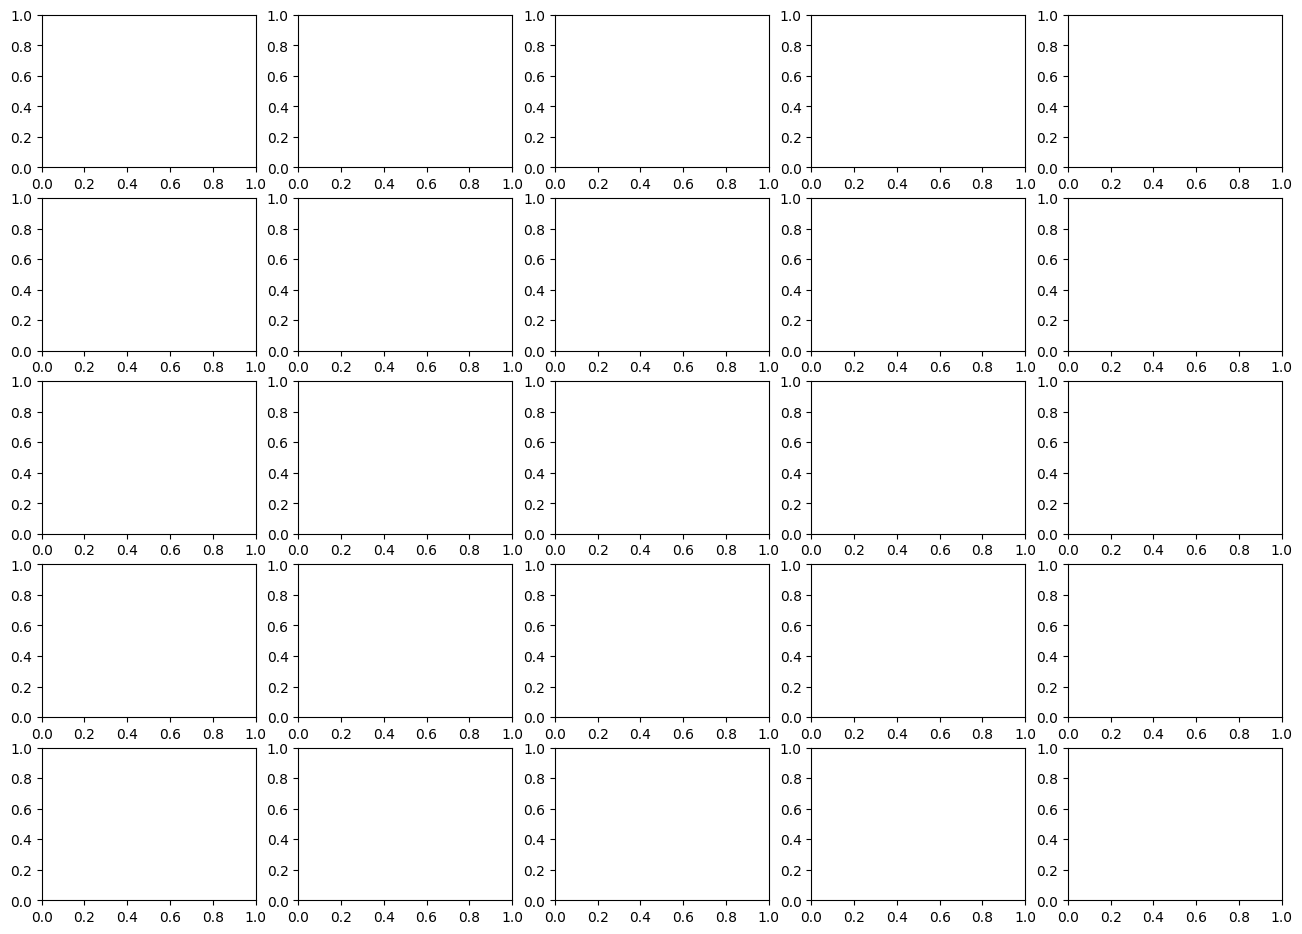

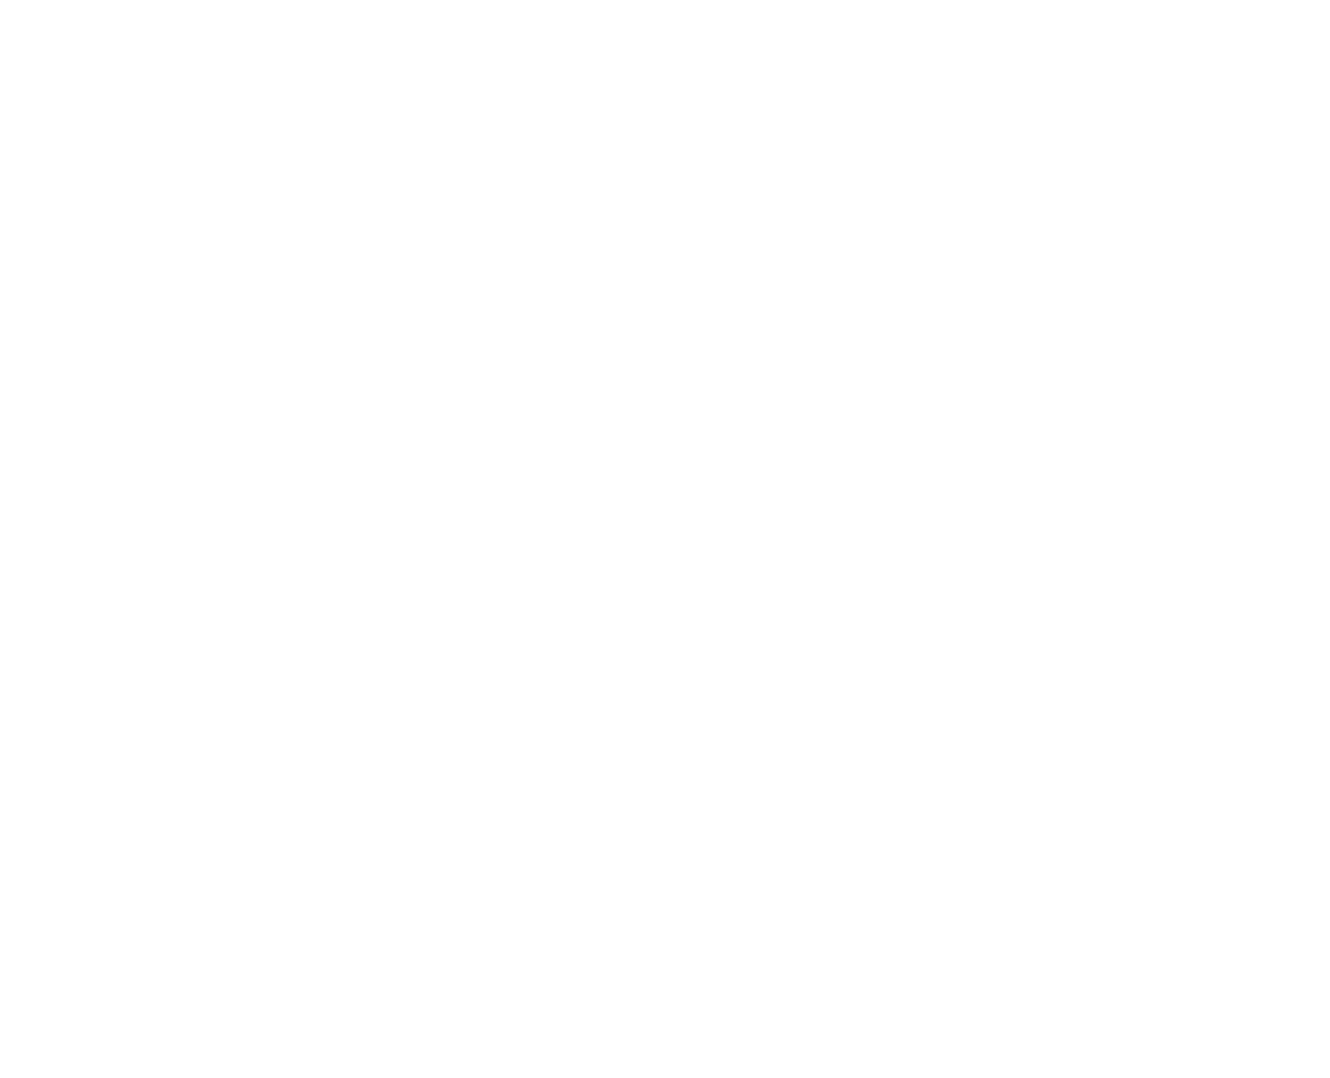

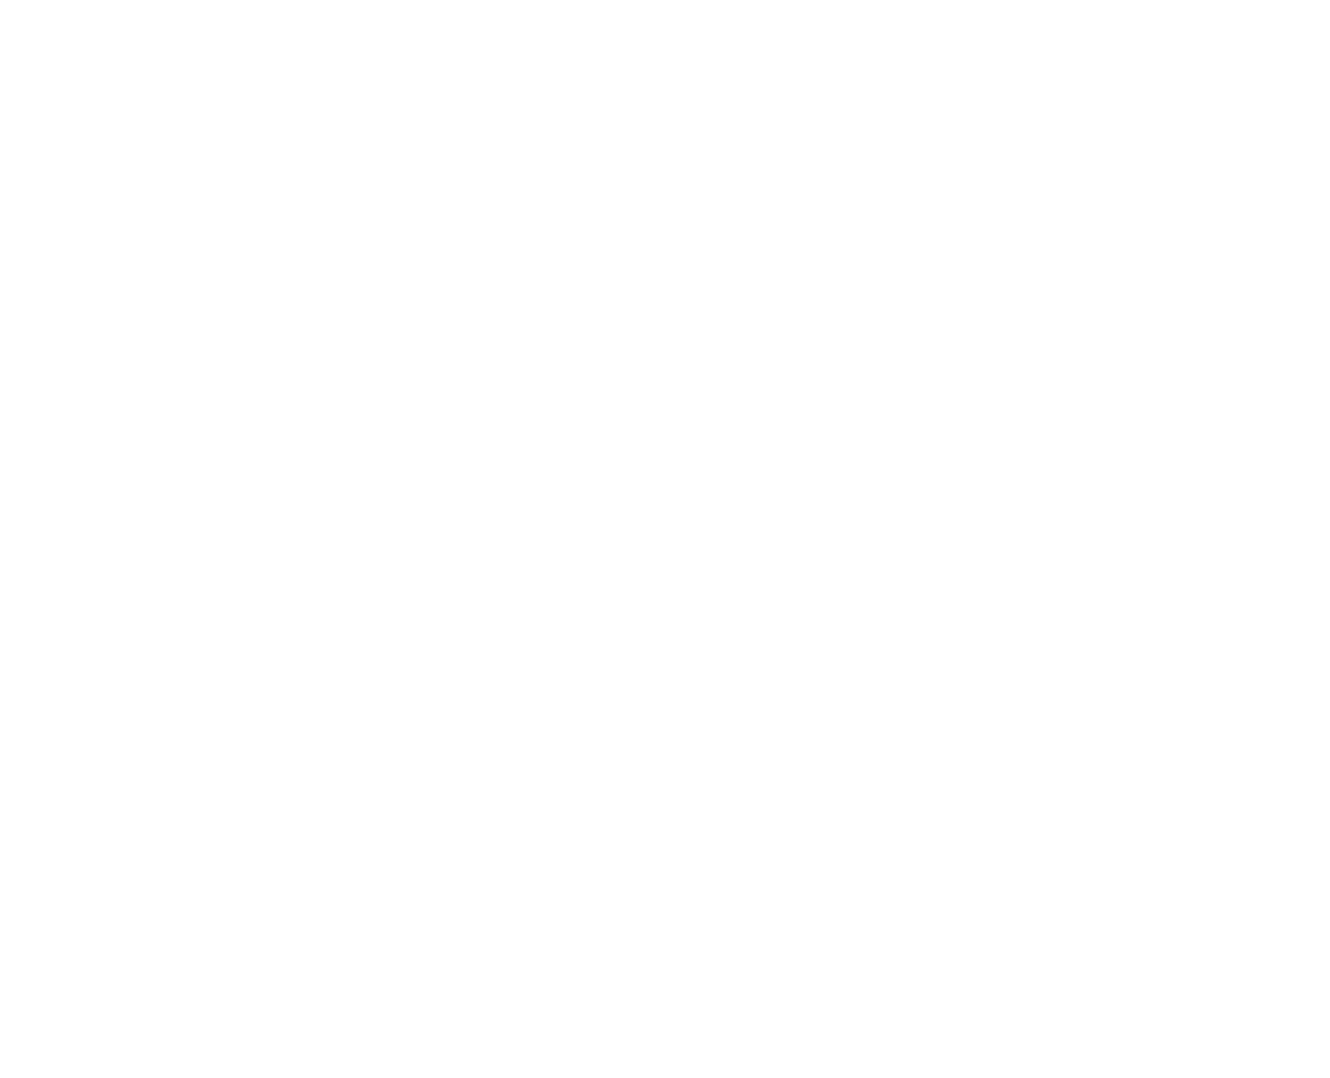

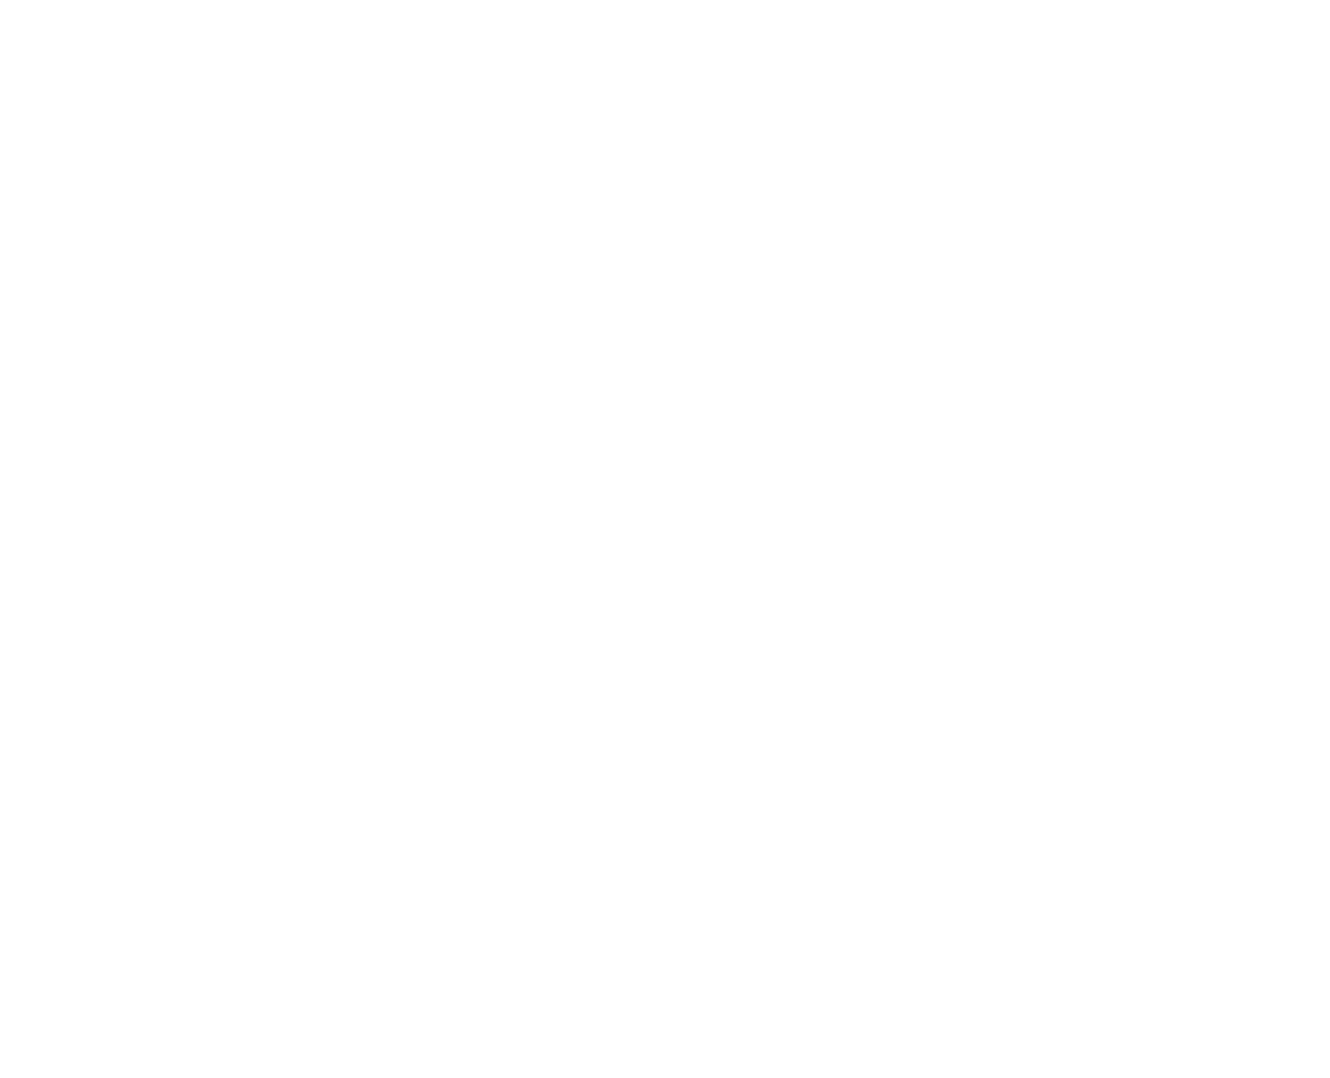

In [3]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd

from behavior_qc_visualization import collect_behavior_model_summary

def _run_one_session(session_name: str) -> pd.DataFrame:
    # If collect_behavior_model_summary can accept a single-session list, reuse it.
    # This keeps behavior identical to your existing function.
    df = collect_behavior_model_summary(sessions=[session_name])
    # Optional: add session column if it's not already present
    if "session_name" not in df.columns:
        df = df.assign(session_name=session_name)
    return df

def collect_behavior_model_summary_parallel(
    sessions,
    *,
    max_workers: int = 8,
) -> pd.DataFrame:
    dfs = []
    errors = []

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        fut_to_sess = {ex.submit(_run_one_session, s): s for s in sessions}
        for fut in as_completed(fut_to_sess):
            s = fut_to_sess[fut]
            try:
                dfs.append(fut.result())
            except Exception as e:
                errors.append((s, repr(e)))

    if errors:
        # Don't crash everything; return what you got + a helpful report
        print("Some sessions failed:")
        for s, err in errors[:20]:
            print(f"  {s}: {err}")
        if len(errors) > 20:
            print(f"  ... plus {len(errors)-20} more")

    if not dfs:
        return pd.DataFrame()

    out = pd.concat(dfs, ignore_index=True, sort=False)

    # Optional: stable ordering if you want
    if "session_name" in out.columns:
        out = out.sort_values(["session_name"]).reset_index(drop=True)

    return out

# Usage
summary = collect_behavior_model_summary_parallel(sessions, max_workers=8)


In [5]:
summary.columns

Index(['session', 'QLearning_L1F1_CK1_softmax_learn_rate_rew',
       'QLearning_L1F1_CK1_softmax_learn_rate_unrew',
       'QLearning_L1F1_CK1_softmax_forget_rate_unchosen',
       'QLearning_L1F1_CK1_softmax_choice_kernel_relative_weight',
       'QLearning_L1F1_CK1_softmax_choice_kernel_step_size',
       'QLearning_L1F1_CK1_softmax_biasL',
       'QLearning_L1F1_CK1_softmax_softmax_inverse_temperature',
       'QLearning_L1F1_CK1_softmax_learn_rate',
       'QLearning_L1F1_CK1_softmax_log_likelihood',
       'QLearning_L1F1_CK1_softmax_AIC', 'QLearning_L1F1_CK1_softmax_BIC',
       'QLearning_L1F1_CK1_softmax_LPT', 'QLearning_L1F1_CK1_softmax_LPT_AIC',
       'QLearning_L1F1_CK1_softmax_LPT_BIC',
       'QLearning_L1F1_CK1_softmax_prediction_accuracy',
       'QLearning_L1F1_CK1_softmax_reward_coefs',
       'QLearning_L2F1_softmax_learn_rate_rew',
       'QLearning_L2F1_softmax_learn_rate_unrew',
       'QLearning_L2F1_softmax_forget_rate_unchosen',
       'QLearning_L2F1_softmax_

In [34]:
import numpy as np
import pandas as pd
import ast

def sum_first_n(x, n):
    # Parse stringified lists if needed
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except Exception:
            return np.nan

    # Convert to numpy array
    arr = np.asarray(x)

    # Skip scalars / invalid entries
    if arr.ndim == 0:
        return np.nan

    # Require at least n elements
    if arr.size < n:
        return np.nan

    return float(arr[:n].sum())


# --------------------------------------------------
# Models to process
# --------------------------------------------------
models = [
    "QLearning_L1F1_CK1_softmax",
    "QLearning_L2F1_softmax",
    "QLearning_L2F1_CK1_softmax",
    "QLearning_L2F1_CKfull_softmax",
    "ForagingCompareThreshold",
    'QLearning_L1F0_CKfull_softmax',
    'QLearning_L1F1_CKfull_softmax'
]

# Number of coefficients to sum
n = 6


# --------------------------------------------------
# Apply for all models
# --------------------------------------------------
for model in models:
    src_col = f"{model}_reward_coefs"
    dst_col = f"{model}_reward_coefs_sum{n}"

    if src_col not in summary.columns:
        print(f"⚠️  Skipping {model}: column '{src_col}' not found")
        continue

    summary[dst_col] = summary[src_col].apply(sum_first_n, n=n)


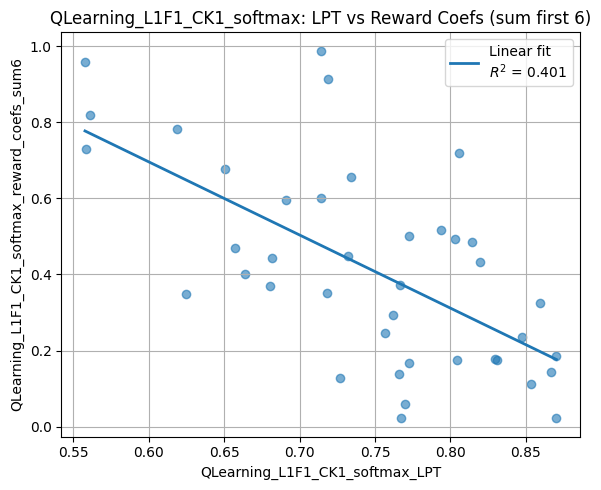

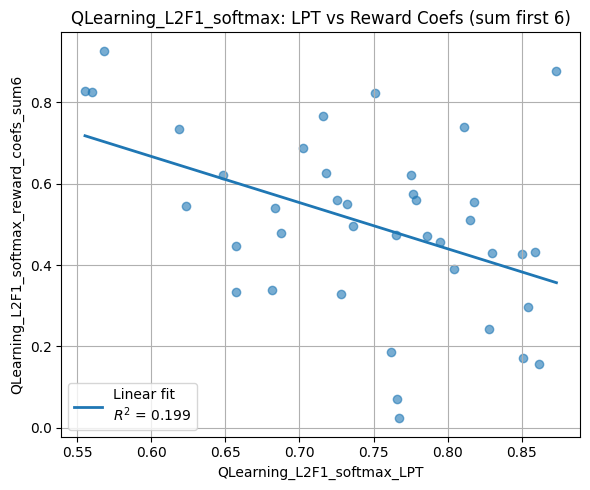

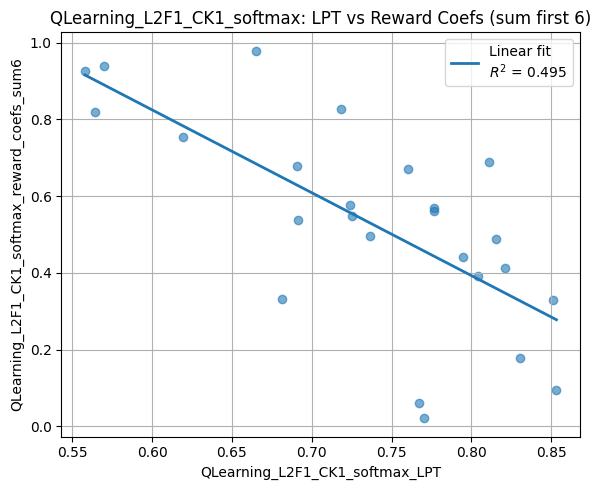

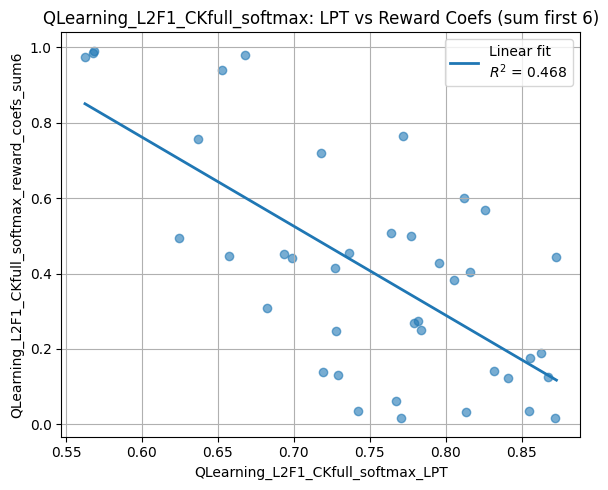

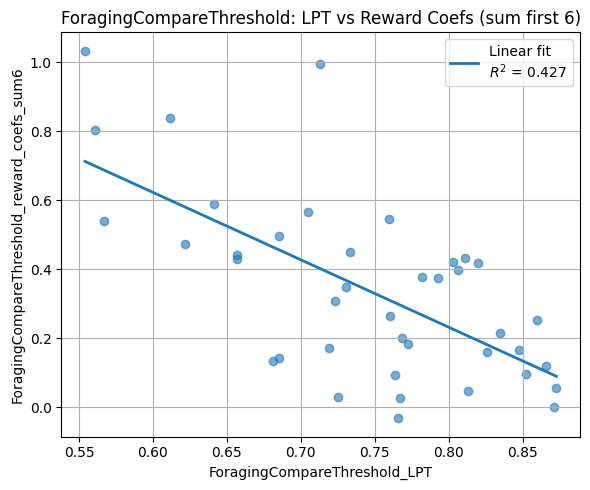

In [37]:
import numpy as np
import matplotlib.pyplot as plt

models = [
    "QLearning_L1F1_CK1_softmax",
    "QLearning_L2F1_softmax",
    "QLearning_L2F1_CK1_softmax",
    "QLearning_L2F1_CKfull_softmax",
    "ForagingCompareThreshold",
    'QLearning_L1F0_CKfull_softmax',
    'QLearning_L1F1_CKfull_softmax'
]

for model in models:
    x_col = f"{model}_LPT"
    y_col = f"{model}_reward_coefs_sum6"

    if x_col not in summary.columns or y_col not in summary.columns:
        print(f"Skipping {model}: missing columns")
        continue

    # Drop NaNs pairwise
    df = summary[[x_col, y_col]].dropna()
    x = df[x_col].values
    y = df[y_col].values

    if len(x) < 3:
        print(f"Skipping {model}: not enough data points")
        continue

    # Linear fit
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept

    # Goodness of fit (R^2)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # Plot
    plt.figure(figsize=(6, 5))
    plt.scatter(x, y, alpha=0.6)
    plt.plot(
        np.sort(x),
        slope * np.sort(x) + intercept,
        linewidth=2,
        label=f"Linear fit\n$R^2$ = {r2:.3f}",
    )
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{model}: LPT vs Reward Coefs (sum first 6)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"{model}: slope={slope:.4f}, intercept={intercept:.4f}, R^2={r2:.4f}")
